# Practica 06:  Manejo de Mapas de Calor  Georeferenciables en el  Análisis EDA

**Carrera:** Ingeniería en Desarrollo y Gestión de Software  
**Asignatura:** Extracción de Conocimiento en Base de Datos  
**Docente:** M.T.I. Marco A. Ramírez Hernández  
**Periodo:** Mayo - Agosto 2026



**Nombre del Estudiante:** José Agustín Jiménez Castillo

**Matricula:** 230365

**Grado y Grupo:** 9°B IDGS

## 1.- Preparacion del Dataset

Vamos a importar las bibliotecas necesarias y cargar el conjunto de datos.

In [7]:
!pip install wordcloud


In [12]:
!pip install folium


   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [8]:
from plotly.offline import init_notebook_mode, iplot
from wordcloud import WordCloud
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
from plotly import tools
from datetime import date
import pandas as pd
import numpy as np 
import seaborn as sns
import random 
import warnings
import operator
warnings.filterwarnings("ignore")
init_notebook_mode(connected=True)

donors_df = pd.read_csv("./Donors.csv")
donations_df = pd.read_csv("./Donations.csv")
teachers_df = pd.read_csv("./Teachers.csv")



## 2. Explorando a los Donantes
El conjunto de datos de donantes consiste en información sobre cada donante que ha donado al menos una vez en DonorsChoose, como su ciudad, estado, código postal y estado como maestro.

## 2.1 Vista Rápida de los Donantes
Echemos un vistazo a las primeras filas del conjunto de datos de donantes

In [10]:
###### total rows
# donors_df.shape

###### total cities 
# len(donors_df['Donor City'].value_counts())

# more than one donation
# t = donations_df['Donor ID'].value_counts().to_frame()
# len(t[t['Donor ID']>1])

donors_df.head(3)

,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,00000ce845c00cbf0686c992fc369df4,Evanston,Illinois,No,602
1,00002783bc5d108510f3f9666c8b1edd,Appomattox,other,No,245
2,00002d44003ed46b066607c5455a999a,Winton,California,Yes,953


Hasta abril de 2018, hay un total de 2,122,640 donantes registrados en DonorsChoose. Estos donantes pertenecen a 15,204 ciudades diferentes de Estados Unidos y algunos otros países. De ese enorme número de donantes, solo 552,941 (aproximadamente el 26%) han donado más de una vez. Uno de los principales objetivos del desafío Data Science for Goods es encontrar información y recomendaciones relevantes para que los donantes se sientan inspirados a donar nuevamente. Hay alrededor de 1,471,613 donantes que solo han hecho una donación, por lo que DonorsChoose tiene la oportunidad de motivar a estas personas a hacer un pago más.

# 2.2 Donantes de cada Estado
## 2.2.1 Número de donantes por estado

In [13]:
import folium
from folium import plugins
from io import StringIO
import folium 


statesll=StringIO("""State,Latitude,Longitude
Alabama,32.806671,-86.791130
Alaska,61.370716,-152.404419
Arizona,33.729759,-111.431221
Arkansas,34.969704,-92.373123
California,36.116203,-119.681564
Colorado,39.059811,-105.311104
Connecticut,41.597782,-72.755371
Delaware,39.318523,-75.507141
District of Columbia,38.897438,-77.026817
Florida,27.766279,-81.686783
Georgia,33.040619,-83.643074
Hawaii,21.094318,-157.498337
Idaho,44.240459,-114.478828
Illinois,40.349457,-88.986137
Indiana,39.849426,-86.258278
Iowa,42.011539,-93.210526
Kansas,38.526600,-96.726486
Kentucky,37.668140,-84.670067
Louisiana,31.169546,-91.867805
Maine,44.693947,-69.381927
Maryland,39.063946,-76.802101
Massachusetts,42.230171,-71.530106
Michigan,43.326618,-84.536095
Minnesota,45.694454,-93.900192
Mississippi,32.741646,-89.678696
Missouri,38.456085,-92.288368
Montana,46.921925,-110.454353
Nebraska,41.125370,-98.268082
Nevada,38.313515,-117.055374
New Hampshire,43.452492,-71.563896
New Jersey,40.298904,-74.521011
New Mexico,34.840515,-106.248482
New York,42.165726,-74.948051
North Carolina,35.630066,-79.806419
North Dakota,47.528912,-99.784012
Ohio,40.388783,-82.764915
Oklahoma,35.565342,-96.928917
Oregon,44.572021,-122.070938
Pennsylvania,40.590752,-77.209755
Rhode Island,41.680893,-71.511780
South Carolina,33.856892,-80.945007
South Dakota,44.299782,-99.438828
Tennessee,35.747845,-86.692345
Texas,31.054487,-97.563461
Utah,40.150032,-111.862434
Vermont,44.045876,-72.710686
Virginia,37.769337,-78.169968
Washington,47.400902,-121.490494
West Virginia,38.491226,-80.954453
Wisconsin,44.268543,-89.616508
Wyoming,42.755966,-107.302490""")

tempdf = states_df = donors_df['Donor State'].value_counts()
t1 = pd.DataFrame()
t1['Donor State'] = tempdf.index
t1['Donor Count'] = tempdf.values

# tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'sum'}).reset_index()
# t1 = tempdf.sort_values('Donation Amount', ascending=False)

sdf = pd.read_csv(statesll).rename(columns={'State':'Donor State'})
sdf = sdf.merge(t1, on='Donor State', how='inner')
sdf 

map4 = folium.Map(location=[39.50, -98.35], tiles='CartoDB dark_matter', zoom_start=3.5)
for j, rown in sdf.iterrows():
    rown = list(rown)
    folium.CircleMarker([float(rown[1]), float(rown[2])], popup="<b>State:</b>" + rown[0].title() +"<br> <b>Donors:</b> "+str(int(rown[3])), radius=float(rown[3])*0.0001, color='#be0eef', fill=True).add_to(map4)
map4

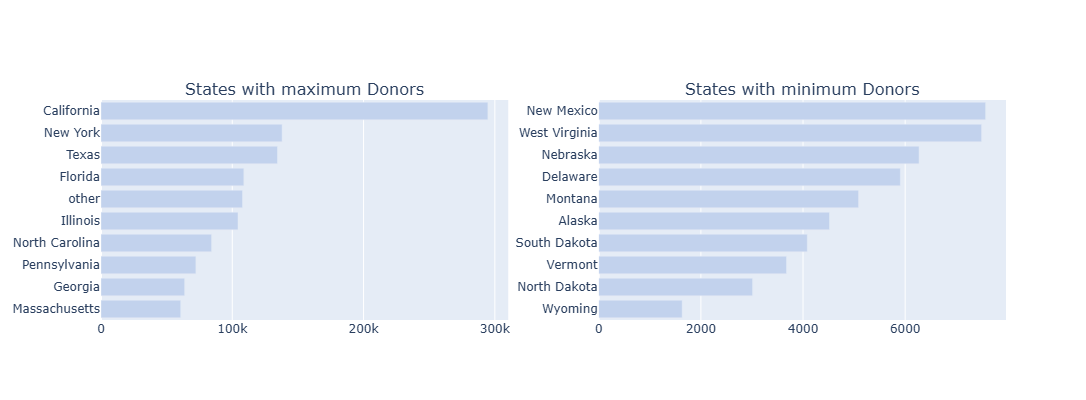

In [14]:
def bar_hor(df, col, title, color, w=None, h=None, lm=0, limit=100, return_trace=False, rev=False):
    cnt_srs = df[col].value_counts()
    yy = cnt_srs.head(limit).index[::-1] 
    xx = cnt_srs.head(limit).values[::-1] 
    if rev:
        yy = cnt_srs.tail(limit).index[::-1] 
        xx = cnt_srs.tail(limit).values[::-1] 
        
    
    trace = go.Bar(y=yy, x=xx, orientation = 'h', marker=dict(color=color))
    if return_trace:
        return trace 
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

def bar_hor_noagg(x, y, title, color, w=None, h=None, lm=0, limit=100, rt=False):
    trace = go.Bar(y=x, x=y, orientation = 'h', marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)


def bar_ver_noagg(x, y, title, color, w=None, h=None, lm=0, rt = False):
    trace = go.Bar(y=y, x=x, marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

    
trace1 = bar_hor(donors_df, 'Donor City', "Top Cities with maximum Donors", '#c2d2ed', 500, 400, 200, limit = 10, return_trace=True)
trace2 = bar_hor(donors_df, 'Donor State', "Top States with maximum Donors", '#c2d2ed', 500, 400, 200, limit = 10, return_trace=True)
trace4 = bar_hor(donors_df, 'Donor State', "Top States with maximum Donors", '#c2d2ed', 600, 400, 200, limit = 10, return_trace=True, rev=True)


fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['States with maximum Donors','States with minimum Donors'])
# fig = tools.make_subplots(rows=2, cols=2, specs=[[{}, {}], [{'colspan': 2}, None]], print_grid=False, subplot_titles = ['States with maximum Donors','States with minimum Donors', 'Cities with maximum Donors'])
fig.append_trace(trace2, 1, 1);
fig.append_trace(trace4, 1, 2);
# fig.append_trace(trace1, 2, 1);

fig['layout'].update(height=400, showlegend=False);
iplot(fig); 

> - California, al ser el estado más poblado, también tiene una gran base de donantes registrados, con casi 300.000 donantes. **San Francisco y Los Ángeles** son las principales ciudades de California donde se concentra la mayoría de donantes. El mayor número de escuelas y proyectos también procede del estado de California.
> - Nueva York, Texas y Florida, con aproximadamente 137.000, 134.000 y 108.000 donantes, son otros tres estados principales con gran número de donantes. Las ciudades principales incluyen New York City, Miami, Tampa, Houston y Dallas.
> - North Dakota, South Dakota, Vermont y Wyoming son los estados con muy pocos donantes (menos de 4.000). Existe una entrada llamada "others" en los datos de estados, que probablemente indica donantes maestros o donantes de otros países.
> - Entre las ciudades de EE. UU., las tres principales son: **Chicago (≈35K donantes), New York (≈27K)** y **Brooklyn (≈22K)**. Las ciudades californianas SF y LA aparecen a continuación con ≈18K y ≈16K donantes.

## <a>Conjunto de datos ajustado por población</a>

Los estados que aparecen en los gráficos anteriores son en muchos casos los más poblados. Será interesante calcular el número de donantes por 100.000 habitantes para cada estado. He añadido un conjunto de datos ajustado por población con la población de cada estado en 2013.

Conjunto de población: http://www.enchantedlearning.com/usa/states/population.shtml

## <a id="2.3">2.3 Estados con mayor ratio Donantes/Población</a>

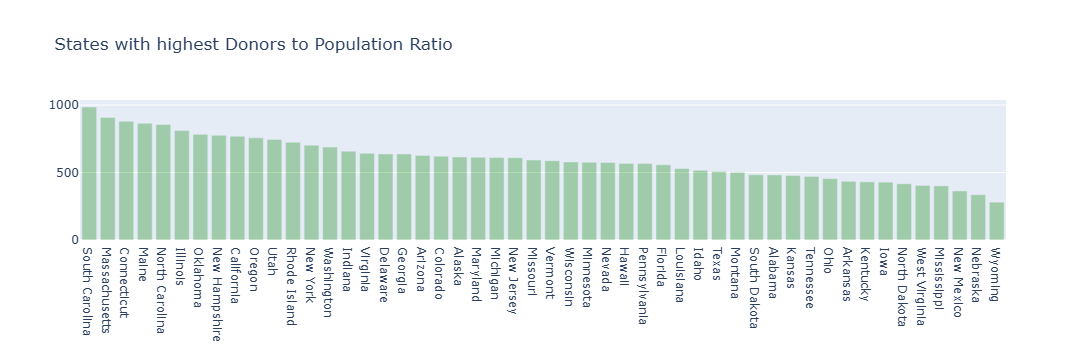

In [15]:
census_2013 = {'Mississippi': 2991207, 'Iowa': 3090416, 'Oklahoma': 3850568, 'Delaware': 925749, 'Minnesota': 5420380, 'Alaska': 735132, 'Illinois': 12882135, 'Arkansas': 2959373, 'New Mexico': 2085287, 'Indiana': 6570902, 'Maryland': 5928814, 'Louisiana': 4625470, 'Texas': 26448193, 'Wyoming': 582658, 'Arizona': 6626624, 'Wisconsin': 5742713, 'Michigan': 9895622, 'Kansas': 2893957, 'Utah': 2900872, 'Virginia': 8260405, 'Oregon': 3930065, 'Connecticut': 3596080, 'New York': 19651127, 'California': 38332521, 'Massachusetts': 6692824, 'West Virginia': 1854304, 'South Carolina': 4774839, 'New Hampshire': 1323459, 'Vermont': 626630, 'Georgia': 9992167, 'North Dakota': 723393, 'Pennsylvania': 12773801, 'Florida': 19552860, 'Hawaii': 1404054, 'Kentucky': 4395295, 'Rhode Island': 1051511, 'Nebraska': 1868516, 'Missouri': 6044171, 'Ohio': 11570808, 'Alabama': 4833722, 'South Dakota': 844877, 'Colorado': 5268367, 'Idaho': 1612136, 'New Jersey': 8899339, 'Washington': 6971406, 'North Carolina': 9848060, 'Tennessee': 6495978, 'Montana': 1015165, 'District of Columbia': 646449, 'Nevada': 2790136, 'Maine': 1328302}

donors_from_states = dict(donors_df['Donor State'].value_counts())

don_pop = {}
for state, don in donors_from_states.items():
    if state not in census_2013:
        continue
    don_pop[state]  = float(don)*100000/ census_2013[state]

import operator
don_pop = sorted(don_pop.items(), key=operator.itemgetter(1), reverse = True)
xx = [x[0] for x in (don_pop)][1:]
yy = [x[1] for x in (don_pop)][1:]

trace2 = go.Bar(
    x=xx,
    y=yy,
    name='Donors to Population',
    marker=dict(color='green'),
    opacity=0.3
)

data = [trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title = 'States with highest Donors to Population Ratio',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

> - Se genera un gráfico interesante al mostrar que los estados: **Carolina del Sur** (con población = 4,774,839), **Massachusetts** (con población = 6,692,824) y **Connecticut** (con población = 3,596,080) tienen la mayor proporción de donantes respecto a la población, y el mayor número de donantes por cada 100,000 personas. Carolina del Sur = 985 donantes por 100K personas, Massachusetts = 907 donantes por 100K personas, y Connecticut = 878 donantes por 100K personas.
> - Wyoming, Nebraska y Nuevo México tienen el menor número de donantes por cada 100K personas, con 285, 335 y 363 donantes, respectivamente.
> - Texas, uno de los estados con el mayor número de donantes, tiene una proporción menor de donantes respecto a la población, igual a 508 donantes por 100K personas.

## <a id="2.4">2.4 Vamos a visualizar dónde se encuentran los donantes </a>
## <a id="2.4.1"> 2.4.1 Dónde se encuentran los donantes en California </a>

In [17]:
calcit = StringIO(u"""Name,Latitude,Longitude,Total Donors,Color,Size
Los Angeles,34.052233,-118.243686,"17,922.000000",#0061ff,10
San Francisco,37.774931,-122.419417,"16,553.000000",#0061ff,10
San Diego,32.715328,-117.157256,"9,072.000000",#0061ff,10
San Jose,37.339386,-121.894956,"7,674.000000",#0061ff,10
Oakland,37.804364,-122.271114,"6,783.000000",#0061ff,10
Sacramento,38.581572,-121.494400,"4,701.000000",#0061ff,10
Bakersfield,35.373292,-119.018711,"3,758.000000",#0061ff,10
Long Beach,33.768322,-118.195617,"3,120.000000",#0061ff,10
Berkeley,37.871592,-122.272747,"2,898.000000",#0061ff,10
Irvine,33.683947,-117.794694,"2,765.000000",#0061ff,10
Fremont,37.548269,-121.988572,"2,716.000000",#0061ff,10
Walnut Creek,37.910078,-122.065183,"2,255.000000",#0061ff,10
Huntington Beach,33.660297,-117.999225,"2,185.000000",#0061ff,10
Murrieta,33.553914,-117.213922,"1,982.000000",#0061ff,10
Pleasanton,37.662431,-121.874678,"1,970.000000",#0061ff,10
Torrance,33.83585,-118.340628,"1,957.000000",#0061ff,10
San Mateo,37.562992,-122.325525,"1,956.000000",#0061ff,10
Santa Monica,34.019453,-118.491192,"1,780.000000",#0061ff,10
Livermore,37.681875,-121.768008,"1,776.000000",#0061ff,10
Santa Rosa,38.440467,-122.714431,"1,752.000000",#0061ff,10
Concord,37.977978,-122.031072,"1,623.000000",#0061ff,10
Alameda,37.765206,-122.241636,"1,548.000000",#0061ff,10
Fresno,36.746842,-119.772586,"1,543.000000",#0061ff,10
San Ramon,37.779928,-121.978014,"1,533.000000",#0061ff,10
Anaheim,33.835292,-117.914503,"1,475.000000",#0061ff,10
Pasadena,34.147786,-118.144517,"1,429.000000",#0061ff,10
Glendale,34.142508,-118.255075,"1,427.000000",#0061ff,10
Riverside,33.95335,-117.396156,"1,425.000000",#0061ff,10
Sunnyvale,37.368831,-122.036350,"1,406.000000",#0061ff,10
Chula Vista,32.640053,-117.084197,"1,398.000000",#0061ff,10
Mountain View,37.386053,-122.083850,"1,398.000000",#0061ff,10
Elk Grove,38.4088,-121.371617,"1,397.000000",#0061ff,10
Santa Clarita,34.391664,-118.542586,"1,382.000000",#0061ff,10
Burbank,34.180839,-118.308967,"1,357.000000",#0061ff,10
Redwood City,37.485214,-122.236356,"1,323.000000",#0061ff,10
Chico,39.728494,-121.837478,"1,322.000000",#0061ff,10
Whittier,33.979178,-118.032844,"1,280.000000",#0061ff,10
Corona,33.875294,-117.566439,"1,239.000000",#0061ff,10
Santa Clara,37.354108,-121.955236,"1,233.000000",#0061ff,10
Orange,33.787794,-117.853111,"1,229.000000",#0061ff,10
Palo Alto,37.441883,-122.143019,"1,219.000000",#0061ff,10
Hayward,37.668819,-122.080797,"1,162.000000",#0061ff,10
Oceanside,33.195869,-117.379483,"1,157.000000",#0061ff,10
Fullerton,33.870292,-117.925339,"1,151.000000",#0061ff,10
San Rafael,37.973536,-122.531086,"1,136.000000",#0061ff,10
Folsom,38.677958,-121.176058,"1,125.000000",#0061ff,10
Simi Valley,34.269447,-118.781483,"1,069.000000",#0061ff,10
Escondido,33.119208,-117.086422,"1,062.000000",#0061ff,10
Santa Ana,33.745572,-117.867833,"1,054.000000",#0061ff,10
Redondo Beach,33.849183,-118.388408,"1,048.000000",#34ef6c,8
Stockton,37.957703,-121.290781,"1,041.000000",#34ef6c,8
Santa Cruz,36.974117,-122.030797,"1,029.000000",#34ef6c,8
Culver City,34.021122,-118.396467,"1,019.000000",#34ef6c,8
Salinas,36.677736,-121.655500,"1,017.000000",#34ef6c,8
Martinez,38.019367,-122.134133,975.000000,#34ef6c,8
Santa Barbara,34.420831,-119.698189,936.000000,#34ef6c,8
San Leandro,37.724931,-122.156078,929.000000,#34ef6c,8
Ventura,34.274639,-119.229006,922.000000,#34ef6c,8
Roseville,38.752122,-121.288006,888.000000,#34ef6c,8
Yorba Linda,33.888625,-117.813111,888.000000,#34ef6c,8
Costa Mesa,33.641133,-117.918669,887.000000,#34ef6c,8
San Marcos,33.143372,-117.166144,866.000000,#34ef6c,8
Brentwood,34.057361,-118.480511,853.000000,#34ef6c,8
South San Francisco,37.654656,-122.407750,841.000000,#34ef6c,8
Modesto,37.639097,-120.996878,837.000000,#34ef6c,8
Temecula,33.493639,-117.148364,837.000000,#34ef6c,8
Novato,38.107419,-122.569703,831.000000,#34ef6c,8
Carlsbad,33.158092,-117.350594,822.000000,#34ef6c,8
Mission Viejo,33.600022,-117.671994,817.000000,#34ef6c,8
Brea,33.916681,-117.900061,802.000000,#34ef6c,8
Garden Grove,33.773906,-117.941447,792.000000,#34ef6c,8
Dublin,37.702153,-121.935792,784.000000,#34ef6c,8
El Cajon,32.794772,-116.962528,783.000000,#34ef6c,8
Menlo Park,37.453828,-122.182186,768.000000,#34ef6c,8
Fairfield,38.249358,-122.039967,751.000000,#34ef6c,8
Pleasant Hill,37.947978,-122.060797,725.000000,#34ef6c,8
Napa,38.297539,-122.286864,711.000000,#34ef6c,8
Richmond,37.935758,-122.347750,707.000000,#34ef6c,8
Los Altos,33.796331,-118.118119,703.000000,#34ef6c,8
Daly City,37.687925,-122.470208,702.000000,#34ef6c,8
West Covina,34.068622,-117.938953,688.000000,#34ef6c,8
Lafayette,37.885758,-122.118019,660.000000,#34ef6c,8
La Mesa,32.767828,-117.023083,649.000000,#34ef6c,8
Milpitas,37.428272,-121.906625,649.000000,#34ef6c,8
Carson,33.831406,-118.282017,647.000000,#34ef6c,8
Camarillo,34.216394,-119.037603,643.000000,#34ef6c,8
Petaluma,38.232417,-122.636653,629.000000,#34ef6c,8
Newport Beach,33.618911,-117.928947,626.000000,#34ef6c,8
Pacifica,37.613825,-122.486919,619.000000,#34ef6c,8
Gilroy,37.005783,-121.568275,618.000000,#34ef6c,8
Encinitas,33.036986,-117.291983,607.000000,#34ef6c,8
El Segundo,33.919181,-118.416464,595.000000,#34ef6c,8
Downey,33.940014,-118.132569,592.000000,#34ef6c,8
Rancho Palos Verdes,33.744461,-118.387017,592.000000,#34ef6c,8
San Clemente,33.426972,-117.611992,589.000000,#34ef6c,8
Vacaville,38.356578,-121.987744,584.000000,#34ef6c,8
Chino Hills,33.989819,-117.732586,583.000000,#34ef6c,8
Campbell,37.287164,-121.949958,580.000000,#34ef6c,8
Mill Valley,37.906036,-122.544975,578.000000,#34ef6c,8
El Cerrito,37.916133,-122.310764,576.000000,#f2ae93,6
Emeryville,37.831317,-122.285247,572.000000,#f2ae93,6
Thousand Oaks,34.107231,-118.057847,572.000000,#f2ae93,6
Burlingame,37.584103,-122.366083,570.000000,#f2ae93,6
Antioch,38.004922,-121.805789,568.000000,#f2ae93,6
Beverly Hills,34.073619,-118.400356,568.000000,#f2ae93,6
Lakewood,33.853628,-118.133956,560.000000,#f2ae93,6
Manhattan Beach,33.884736,-118.410908,557.000000,#f2ae93,6
Lancaster,34.686786,-118.154164,551.000000,#f2ae93,6
Oxnard,34.197506,-119.177053,539.000000,#f2ae93,6
San Carlos,37.507158,-122.260522,527.000000,#f2ae93,6
Rocklin,38.790733,-121.235783,526.000000,#f2ae93,6
Placentia,33.872236,-117.870336,520.000000,#f2ae93,6
Cupertino,37.322997,-122.032183,516.000000,#f2ae93,6
Tustin,33.74585,-117.826167,508.000000,#f2ae93,6
Hermosa Beach,33.862236,-118.399519,507.000000,#f2ae93,6
Rancho Cordova,38.589072,-121.302728,501.000000,#f2ae93,6
Fountain Valley,33.709186,-117.953669,498.000000,#f2ae93,6
Cypress,37.320531,-121.962242,497.000000,#f2ae93,6
Union City,37.593392,-122.043831,494.000000,#f2ae93,6
Morgan Hill,37.1305,-121.654389,488.000000,#f2ae93,6
Vallejo,38.104086,-122.256636,485.000000,#f2ae93,6
Alhambra,34.095286,-118.127014,474.000000,#f2ae93,6
Lake Forest,33.646967,-117.689217,465.000000,#f2ae93,6
Rancho Cucamonga,34.1064,-117.593108,463.000000,#f2ae93,6
Vista,33.200036,-117.242536,463.000000,#f2ae93,6
Fontana,34.092233,-117.435047,459.000000,#f2ae93,6
Moreno Valley,33.942467,-117.229672,455.000000,#f2ae93,6
Hawthorne,33.916403,-118.352575,450.000000,#f2ae93,6
Covina,34.090008,-117.890339,443.000000,#f2ae93,6
San Luis Obispo,35.282753,-120.659617,434.000000,#f2ae93,6
Newark,37.529658,-122.040239,433.000000,#f2ae93,6
Inglewood,33.961681,-118.353131,432.000000,#f2ae93,6
Oakley,37.997422,-121.712453,430.000000,#f2ae93,6
Tracy,37.73965,-121.425222,428.000000,#f2ae93,6
Redding,40.586539,-122.391675,424.000000,#f2ae93,6
Glendora,34.136119,-117.865339,423.000000,#f2ae93,6
San Bruno,37.630489,-122.411083,423.000000,#f2ae93,6
Davis,38.544906,-121.740517,417.000000,#f2ae93,6
Westminster,33.751342,-117.993992,413.000000,#f2ae93,6
Pittsburg,38.027975,-121.884681,412.000000,#f2ae93,6
Palmdale,34.579433,-118.116461,408.000000,#f2ae93,6
Visalia,36.330228,-119.292058,406.000000,#f2ae93,6
Poway,32.962822,-117.035864,403.000000,#f2ae93,6
Santa Maria,34.953033,-120.435719,403.000000,#f2ae93,6
Upland,34.097511,-117.648389,396.000000,#f2ae93,6
Laguna Niguel,33.522525,-117.707553,393.000000,#f2ae93,6
La Mirada,33.917236,-118.012008,392.000000,#f2ae93,6
South Pasadena,34.116119,-118.150350,391.000000,#f2ae93,6
Cerritos,33.858347,-118.064786,383.000000,#f2ae93,6
Lodi,38.134147,-121.272219,380.000000,#f2ae93,6
Ontario,34.063344,-117.650889,380.000000,#bab7b6,4
Lincoln,38.891564,-121.293008,376.000000,#bab7b6,4
Buena Park,33.867514,-117.998117,375.000000,#bab7b6,4
Rancho Santa Margarita,33.640856,-117.603103,373.000000,#bab7b6,4
Santee,32.838383,-116.973917,373.000000,#bab7b6,4
Sonoma,38.291858,-122.458036,372.000000,#bab7b6,4
Monrovia,34.144428,-118.001947,371.000000,#bab7b6,4
Albany,37.886869,-122.297747,368.000000,#bab7b6,4
La Habra,33.931958,-117.946172,366.000000,#bab7b6,4
San Pablo,37.962147,-122.345525,366.000000,#bab7b6,4
Belmont,37.520214,-122.275800,364.000000,#bab7b6,4
Pomona,34.055228,-117.752306,364.000000,#bab7b6,4
Gardena,33.88835,-118.308961,363.000000,#bab7b6,4
Arcadia,34.139728,-118.035344,361.000000,#bab7b6,4
Clovis,36.825228,-119.702919,360.000000,#bab7b6,4
Orinda,37.877147,-122.179689,358.000000,#bab7b6,4
Manteca,37.797428,-121.216053,357.000000,#bab7b6,4
Citrus Heights,38.707125,-121.281061,355.000000,#bab7b6,4
Redlands,34.055569,-117.182539,353.000000,#bab7b6,4
Aliso Viejo,33.575,-117.725556,345.000000,#bab7b6,4
Eureka,40.802072,-124.163672,338.000000,#bab7b6,4
West Hollywood,34.090008,-118.361744,337.000000,#bab7b6,4
Auburn,38.896564,-121.076889,335.000000,#bab7b6,4
Saratoga,37.263833,-122.023014,331.000000,#bab7b6,4
Turlock,37.494658,-120.846594,327.000000,#bab7b6,4
Chino,34.012236,-117.688944,325.000000,#bab7b6,4
Diamond Bar,34.028622,-117.810336,324.000000,#bab7b6,4
South Gate,33.954736,-118.212017,319.000000,#bab7b6,4
San Bernardino,34.108344,-117.289764,318.000000,#bab7b6,4
Claremont,34.096675,-117.719778,316.000000,#bab7b6,4
Calabasas,34.138333,-118.660833,298.000000,#bab7b6,4
Los Alamitos,33.803072,-118.072564,297.000000,#bab7b6,4
Agoura Hills,34.153339,-118.761675,295.000000,#bab7b6,4
San Gabriel,34.096111,-118.105833,295.000000,#bab7b6,4
Paso Robles,35.632278,-120.664186,292.000000,#bab7b6,4
Norwalk,33.902236,-118.081733,286.000000,#bab7b6,4
Indio,33.720578,-116.215561,284.000000,#bab7b6,4
Moorpark,34.144897,-118.268742,284.000000,#bab7b6,4
Monterey,36.600239,-121.894675,275.000000,#bab7b6,4
Arroyo Grande,35.118586,-120.590725,274.000000,#bab7b6,4
San Dimas,34.106675,-117.806725,274.000000,#bab7b6,4
La Puente,34.020011,-117.949508,273.000000,#bab7b6,4
West Sacramento,38.580461,-121.530233,273.000000,#bab7b6,4
Rohnert Park,38.339636,-122.701097,269.000000,#bab7b6,4
Monterey Park,34.062511,-118.122847,266.000000,#bab7b6,4
Laguna Hills,33.599722,-117.699444,260.000000,#bab7b6,4
Watsonville,36.910231,-121.756894,259.000000,#bab7b6,4
Clayton,37.941033,-121.935792,256.000000,#bab7b6,4
Hemet,33.747519,-116.971967,256.000000,#bab7b6,4
La Verne,34.100842,-117.767836,255.000000,#bab7b6,4
Ukiah,39.150172,-123.207783,255.000000,#f477d7,2
Palm Desert,33.722244,-116.374456,251.000000,#f477d7,2
Atascadero,35.489417,-120.670725,241.000000,#f477d7,2
Menifee,33.678333,-117.166944,241.000000,#f477d7,2
Lompoc,34.63915,-120.457942,240.000000,#f477d7,2
Merced,37.302164,-120.482967,240.000000,#f477d7,2
Sebastopol,38.402136,-122.823881,237.000000,#f477d7,2
Lake Elsinore,33.668078,-117.327261,236.000000,#f477d7,2
Millbrae,37.598547,-122.387194,234.000000,#f477d7,2
Yuba City,39.140447,-121.616911,231.000000,#f477d7,2
Woodland,38.678517,-121.773297,228.000000,#f477d7,2
Bellflower,33.881683,-118.117011,227.000000,#f477d7,2
Grass Valley,39.219061,-121.061061,227.000000,#f477d7,2
Seal Beach,33.741406,-118.104786,227.000000,#f477d7,2
Walnut,34.020289,-117.865339,227.000000,#f477d7,2
Montebello,34.016506,-118.113753,225.000000,#f477d7,2
Yucaipa,34.033625,-117.043086,225.000000,#f477d7,2
Hanford,36.32745,-119.645683,224.000000,#f477d7,2
Goleta,34.435828,-119.827639,221.000000,#f477d7,2
Hesperia,34.426389,-117.300878,221.000000,#f477d7,2
Laguna Beach,33.542247,-117.783111,221.000000,#f477d7,2
Ridgecrest,35.622456,-117.670897,218.000000,#f477d7,2
Galt,38.254636,-121.299947,217.000000,#f477d7,2
Victorville,34.536108,-117.291158,217.000000,#f477d7,2
San Juan Capistrano,33.501692,-117.662550,209.000000,#f477d7,2
Atwater,37.347717,-120.609083,208.000000,#f477d7,2
Palm Springs,33.830297,-116.545292,208.000000,#f477d7,2
Azusa,34.133619,-117.907564,203.000000,#f477d7,2
Hercules,38.017144,-122.288581,202.000000,#f477d7,2
Sonora,37.984092,-120.382139,199.000000,#f477d7,2
Beaumont,33.929461,-116.977247,198.000000,#f477d7,2
Half Moon Bay,37.463553,-122.428586,197.000000,#f477d7,2
Hollister,36.852453,-121.401603,196.000000,#f477d7,2
Westlake Village,34.145839,-118.805647,194.000000,#f477d7,2
Pico Rivera,33.983069,-118.096736,190.000000,#f477d7,2
Pinole,38.004367,-122.298858,186.000000,#f477d7,2
Compton,33.89585,-118.220072,185.000000,#f477d7,2
Sausalito,37.859094,-122.485250,183.000000,#f477d7,2
La Quinta,33.646692,-116.310008,181.000000,#f477d7,2
Dana Point,33.466972,-117.698108,175.000000,#f477d7,2
Rialto,34.1064,-117.370325,172.000000,#f477d7,2
Perris,33.782519,-117.228647,171.000000,#f477d7,2
Arcata,40.866517,-124.082839,168.000000,#f477d7,2
Pacific Grove,36.617736,-121.916622,168.000000,#f477d7,2
Lomita,33.792239,-118.315072,167.000000,#f477d7,2
San Fernando,34.281947,-118.438972,165.000000,#f477d7,2
South Lake Tahoe,38.939925,-119.977186,163.000000,#f477d7,2
El Monte,34.068622,-118.027567,158.000000,#f477d7,2
Scotts Valley,37.051061,-122.014683,158.000000,#f477d7,2
Tehachapi,35.132189,-118.448975,157.000000,#f477d7,2
Baldwin Park,34.085286,-117.960897,156.000000,#f477d7,2
Marina,36.684403,-121.802172,155.000000,#f477d7,2
Rosemead,34.080564,-118.072847,155.000000,#f477d7,2
Placerville,38.729625,-120.798547,151.000000,#f477d7,2
Highland,34.128344,-117.208650,148.000000,#f477d7,2
Lawndale,33.887236,-118.352575,143.000000,#f477d7,2
Oroville,39.513775,-121.556358,142.000000,#f477d7,2
Seaside,33.819361,-118.366647,142.000000,#f477d7,2
Wildomar,33.598914,-117.280036,142.000000,#f477d7,2
Duarte,34.13945,-117.977286,141.000000,#f477d7,2
Huntington Park,33.981681,-118.225072,141.000000,#f477d7,2
Larkspur,37.934092,-122.535253,139.000000,#f477d7,2
Del Mar,32.959489,-117.265314,138.000000,#f477d7,2
Winters,38.524906,-121.970803,138.000000,#f477d7,2
Red Bluff,40.178489,-122.235831,137.000000,#f477d7,2
Cathedral City,33.779742,-116.465292,136.000000,#f9e84a,1
Ojai,34.44805,-119.242889,136.000000,#f9e84a,1
Coronado,32.685886,-117.183089,134.000000,#f9e84a,1
Lynwood,33.930292,-118.211461,134.000000,#f9e84a,1
Temple City,34.107231,-118.057847,132.000000,#f9e84a,1
Bell,33.977514,-118.187017,124.000000,#f9e84a,1
Sierra Madre,34.161672,-118.052847,119.000000,#f9e84a,1
Nevada City,39.261561,-121.016058,118.000000,#f9e84a,1
National City,32.678108,-117.099197,117.000000,#f9e84a,1
Ceres,37.594933,-120.957711,116.000000,#f9e84a,1
Solana Beach,32.991156,-117.271147,115.000000,#f9e84a,1
La Palma,33.846403,-118.046731,114.000000,#f9e84a,1
Healdsburg,38.610467,-122.869161,110.000000,#f9e84a,1
Ripon,37.739453,-121.135414,109.000000,#f9e84a,1
Crescent City,41.755947,-124.201747,108.000000,#f9e84a,1
Malibu,34.005008,-118.810172,108.000000,#f9e84a,1
Patterson,37.4716,-121.129656,107.000000,#f9e84a,1
Maywood,33.986681,-118.185350,105.000000,#f9e84a,1
Suisun City,38.238247,-122.040244,105.000000,#f9e84a,1
Dixon,38.445464,-121.823297,104.000000,#f9e84a,1
Fort Bragg,39.445722,-123.805292,103.000000,#f9e84a,1
Oakdale,37.766594,-120.847153,103.000000,#f9e84a,1
American Canyon,38.174917,-122.260803,100.000000,#f9e84a,1
Lemon Grove,32.742553,-117.031417,97.000000,#f9e84a,1
Carpinteria,34.398883,-119.518456,96.000000,#f9e84a,1
Lemoore,36.300783,-119.782911,96.000000,#f9e84a,1
San Jacinto,33.783908,-116.958636,95.000000,#f9e84a,1
San Marino,34.121397,-118.106458,95.000000,#f9e84a,1
Paramount,33.889461,-118.159792,94.000000,#f9e84a,1
Tulare,36.207728,-119.347339,93.000000,#f9e84a,1
Twentynine Palms,34.135558,-116.054169,92.000000,#f9e84a,1
Shafter,35.500514,-119.271775,91.000000,#f9e84a,1
Norco,33.931125,-117.548661,89.000000,#f9e84a,1
Capitola,36.975228,-121.953292,88.000000,#f9e84a,1
Rio Vista,38.15575,-121.691344,88.000000,#f9e84a,1
Colton,34.073903,-117.313656,86.000000,#f9e84a,1
Brisbane,37.680767,-122.399972,85.000000,#f9e84a,1
Taft,35.142467,-119.456508,85.000000,#f9e84a,1
Imperial Beach,32.583944,-117.113086,84.000000,#f9e84a,1
Kingsburg,36.513839,-119.554017,84.000000,#f9e84a,1
Morro Bay,35.365808,-120.849900,83.000000,#f9e84a,1
Santa Fe Springs,33.947236,-118.085344,83.000000,#f9e84a,1
Rancho Mirage,33.739744,-116.412789,78.000000,#f9e84a,1
Stanton,33.802517,-117.993117,78.000000,#f9e84a,1
Madera,36.961336,-120.060717,77.000000,#f9e84a,1
Los Banos,37.058278,-120.849914,76.000000,#f9e84a,1
Riverbank,37.736039,-120.935489,76.000000,#f9e84a,1
Gridley,39.363778,-121.693583,75.000000,#f9e84a,1
Pismo Beach,35.142753,-120.641283,74.000000,#f9e84a,1
Santa Paula,34.354167,-119.059269,74.000000,#f9e84a,1
Cotati,38.327778,-122.709167,73.000000,#f9e84a,1
Port Hueneme,34.180728,-119.208158,73.000000,#f9e84a,1
Selma,36.570783,-119.612075,73.000000,#f9e84a,1
Banning,33.925572,-116.876411,71.000000,#f9e84a,1
King City,36.212744,-121.126028,71.000000,#f9e84a,1
El Centro,32.792,-115.563050,69.000000,#f9e84a,1
Lakeport,39.04295,-122.915828,69.000000,#f9e84a,1
Willits,39.409608,-123.355567,68.000000,#f9e84a,1
Barstow,34.895797,-117.017283,67.000000,#f9e84a,1
Marysville,39.145725,-121.591356,67.000000,#f9e84a,1
Orland,39.747381,-122.196375,66.000000,#f9e84a,1
Grand Terrace,34.033903,-117.313653,63.000000,#f9e84a,1
Montclair,34.077511,-117.689778,63.000000,#f9e84a,1
Villa Park,33.814461,-117.813111,63.000000,#f9e84a,1
Artesia,33.865847,-118.083122,62.000000,#f9e84a,1
Desert Hot Springs,33.961125,-116.501678,61.000000,#f9e84a,1
Fortuna,40.598186,-124.157275,61.000000,#f9e84a,1
Grover Beach,35.121642,-120.621283,61.000000,#f9e84a,1
Loma Linda,34.048347,-117.261153,59.000000,#f9e84a,1
Dinuba,36.543283,-119.387067,58.000000,#f9e84a,1
South El Monte,34.051956,-118.046733,58.000000,#f9e84a,1
Porterville,36.065231,-119.016767,57.000000,#f9e84a,1
Lathrop,37.822706,-121.276611,56.000000,#f9e84a,1
Coalinga,36.139678,-120.360150,55.000000,#f9e84a,1
Fillmore,34.399164,-118.918153,54.000000,#f9e84a,1
Mount Shasta,41.410806,-122.194575,52.000000,#f9e84a,1
Anderson,40.448208,-122.297783,51.000000,#f9e84a,1
Cloverdale,38.805461,-123.017222,50.000000,#f9e84a,1
Exeter,36.296061,-119.142053,50.000000,#f9e84a,1
Wasco,35.594125,-119.340947,50.000000,#f9e84a,1
Reedley,36.596339,-119.450403,47.000000,#f9e84a,1
Sanger,36.708006,-119.555964,47.000000,#f9e84a,1
Adelanto,34.582769,-117.409214,45.000000,#f9e84a,1
Brawley,32.978658,-115.530267,43.000000,#f9e84a,1
Calimesa,34.003903,-117.061975,42.000000,#f9e84a,1
Hughson,37.602725,-120.866481,42.000000,#f9e84a,1
Imperial,32.847553,-115.569439,41.000000,#f9e84a,1
Soledad,32.991156,-117.271147,41.000000,#f9e84a,1
Weed,41.42265,-122.386128,40.000000,#f9e84a,1
Calexico,32.678947,-115.498883,37.000000,#f9e84a,1
Willows,39.524325,-122.193592,36.000000,#f9e84a,1
Big Bear Lake,34.243897,-116.911422,35.000000,#f9e84a,1
Delano,35.768842,-119.247053,34.000000,#f9e84a,1
Newman,37.313828,-121.020761,34.000000,#f9e84a,1
Colfax,39.100731,-120.953275,33.000000,#f9e84a,1
Escalon,37.797428,-120.996603,33.000000,#f9e84a,1
Jackson,38.348803,-120.774103,32.000000,#f9e84a,1
Bishop,37.363539,-118.395111,31.000000,#f9e84a,1
Coachella,33.6803,-116.173894,31.000000,#f9e84a,1
Holtville,32.811161,-115.380264,31.000000,#f9e84a,1
Indian Wells,33.717631,-116.340756,31.000000,#f9e84a,1
San Juan Bautista,36.845511,-121.537997,31.000000,#f9e84a,1
Arvin,35.2018,-118.833106,30.000000,#f9e84a,1
Kerman,36.723558,-120.059878,30.000000,#f9e84a,1
Colusa,39.214333,-122.009417,27.000000,#f9e84a,1
Greenfield,36.3208,-121.243814,27.000000,#f9e84a,1
Waterford,37.641319,-120.760483,26.000000,#f9e84a,1
Ferndale,40.576242,-124.263944,25.000000,#f9e84a,1
Susanville,40.416283,-120.653006,25.000000,#f9e84a,1
Buellton,34.613597,-120.192650,24.000000,#f9e84a,1
Calistoga,38.578797,-122.579706,24.000000,#f9e84a,1
Clearlake,38.958231,-122.626372,24.000000,#f9e84a,1
Shasta Lake,40.680428,-122.370842,24.000000,#f9e84a,1
Yreka,41.735419,-122.634472,23.000000,#f9e84a,1
Biggs,39.412389,-121.712750,22.000000,#f9e84a,1
Chowchilla,37.123,-120.260175,22.000000,#f9e84a,1
Live Oak,36.983561,-121.980517,22.000000,#f9e84a,1
McFarland,35.678011,-119.229275,22.000000,#f9e84a,1
Fowler,36.630506,-119.678469,21.000000,#f9e84a,1
Gonzales,36.506628,-121.444381,21.000000,#f9e84a,1
Solvang,34.595819,-120.137647,21.000000,#f9e84a,1
Angels Camp,38.067783,-120.538531,20.000000,#f9e84a,1
Gustine,37.257717,-120.998814,20.000000,#f9e84a,1
Sutter Creek,38.392967,-120.802436,20.000000,#f9e84a,1
Wheatland,39.009894,-121.423014,20.000000,#f9e84a,1
Hawaiian Gardens,33.831403,-118.072842,19.000000,#f9e84a,1
Lindsay,36.203006,-119.088161,19.000000,#f9e84a,1
Livingston,37.386883,-120.723533,19.000000,#f9e84a,1
California City,35.1258,-117.985903,18.000000,#f9e84a,1
Corning,39.927658,-122.179156,18.000000,#f9e84a,1
Trinidad,41.059292,-124.143125,18.000000,#f9e84a,1
Ione,38.352692,-120.932717,17.000000,#f9e84a,1
Dunsmuir,41.208208,-122.271953,16.000000,#f9e84a,1
Tulelake,41.955989,-121.477492,15.000000,#f9e84a,1
Firebaugh,36.858839,-120.456008,13.000000,#f9e84a,1
Woodlake,36.413561,-119.098717,13.000000,#f9e84a,1
Blue Lake,40.882908,-123.983950,12.000000,#f9e84a,1
Blythe,33.617233,-114.589175,12.000000,#f9e84a,1
Avalon,33.342819,-118.328228,11.000000,#f9e84a,1
Montague,41.728197,-122.527800,11.000000,#f9e84a,1
Williams,39.154614,-122.149419,11.000000,#f9e84a,1
Alturas,41.487114,-120.542456,10.000000,#f9e84a,1
Corcoran,37.977978,-122.031072,9.000000,#f9e84a,1
Isleton,38.161861,-121.611622,9.000000,#f9e84a,1
Piedmont,37.824372,-122.231636,9.000000,#f9e84a,1
Rio Dell,40.4993,-124.106436,9.000000,#f9e84a,1
Huron,36.202731,-120.102917,8.000000,#f9e84a,1
Point Arena,38.908797,-123.693072,8.000000,#f9e84a,1
Dorris,41.967369,-121.918061,7.000000,#f9e84a,1
Dos Palos,36.986058,-120.626572,7.000000,#f9e84a,1
Etna,41.456806,-122.894756,6.000000,#f9e84a,1
Guadalupe,34.971644,-120.571836,6.000000,#f9e84a,1
Needles,34.848061,-114.614133,6.000000,#f9e84a,1
Plymouth,38.481853,-120.844658,5.000000,#f9e84a,1
Avenal,36.004122,-120.129028,4.000000,#f9e84a,1
Fort Jones,41.663864,-124.252892,4.000000,#f9e84a,1
Portola,39.810458,-120.469103,4.000000,#f9e84a,1
Calipatria,33.125597,-115.514153,3.000000,#f9e84a,1
Farmersville,36.297728,-119.206778,3.000000,#f9e84a,1
Loyalton,39.676294,-120.241039,3.000000,#f9e84a,1
Maricopa,35.058858,-119.400950,2.000000,#f9e84a,1
Parlier,36.611617,-119.527072,2.000000,#f9e84a,1
Bell Gardens,33.965292,-118.151458,1.000000,#f9e84a,1
Orange Cove,36.624394,-119.313731,1.000000,#f9e84a,1
San Joaquin,36.606617,-120.189044,1.000000,#f9e84a,1
Westmorland,33.037267,-115.621383,1.000000,#f9e84a,1""")



cities = pd.read_csv(calcit)
cities = cities.dropna()

# map_osm = folium.Map(location=[36.611617,-119.527072], zoom_start=5)

# for i, row in cities.iterrows():
#     folium.CircleMarker([row['Latitude'], row['Longitude']],
#                         radius=row['Size'],
#                         color=row['Color'],
#                         fill_color=row['Color'],
#                        ).add_to(map_osm)



map_osm2 = folium.Map([36.611617,-119.527072], zoom_start=6,tiles='cartodbdark_matter')
ziparr = []
for i, row in cities.iterrows():
    ziparr.append([row['Latitude'],row['Longitude'], float(row['Total Donors'].replace(",",""))])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))
map_osm2


> Ubicaciones clave con mayor densidad de donantes:

    - Los Ángeles: 17.922  
    - San Francisco: 16.553  
    - San Diego: 9.072  
    - San José: 7.674  
    - Oakland: 6.783

## <a id="2.4.2">2.4.2 Donantes en Florida</a>

In [71]:
c = pd.read_csv('./code_states.csv')
c = c.dropna()

fldf = c[c['state'] == 'FL'][['city', 'latitude', 'longitude']]

fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
t = donors_df[donors_df['Donor State'] == 'Florida']['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([29.813456, -82.472049], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))


> La región de tres condados de Florida — Palm Beach, Miami-Dade y Broward — presenta una alta concentración de donantes. La ciudad de Tampa también tiene un número significativo de donantes. Algunos donantes se encuentran en áreas muy caras y en la punta más al sur de EE. UU., la zona de Key West. Conteos de las 5 ciudades principales:

> Miami (9309), Tampa (6016), Orlando (5658), Jacksonville (4598), Fort Lauderdale (4311), West Palm Beach (2400)

## <a id="2.4.3">2.4.3 Donantes en New York</a>

In [1]:
fldf = c[c['state'] == 'NY'][['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df[donors_df['Donor State'] == 'New York']['Donor City'].value_counts()

fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([42.315975, -74.065515], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))


NameError: name 'c' is not defined

> Los donantes de New York proceden principalmente de New York City. Las 5 ciudades principales son:
> - New York: 26.820
> - Brooklyn: 21.715
> - Staten Island: 4.516
> - Bronx: 4.455
> - Buffalo: 2.232

## <a id="2.4.4">2.4.4 Donantes en Texas</a>

In [73]:
fldf = c[c['state'] == 'TX'][['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df[donors_df['Donor State'] == 'Texas']['Donor City'].value_counts()

fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([31.884540, -97.077218], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))


> Principales ciudades de Texas con mayor número de donantes:

> - Houston: 15.404
> - Austin: 9.958
> - Dallas: 7.818
> - San Antonio: 6.465
> - Fort Worth: 4.350

## <a id="2.5">2.5 ¿Dónde se ubican los donantes?</a>

In [74]:
fldf = c[['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([39.3714557,-94.3541242], zoom_start=3.5,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=10))


> Aunque la mayoría de los donantes proceden del estado de California (costa oeste), la región del este de EE. UU. presenta una mayor densidad de donantes en comparación con el oeste. También hay un número significativo de donantes en Hawaii y Alaska.

## <a id="2.6">2.6 Número de donantes maestros y no-maestros por estado</a>

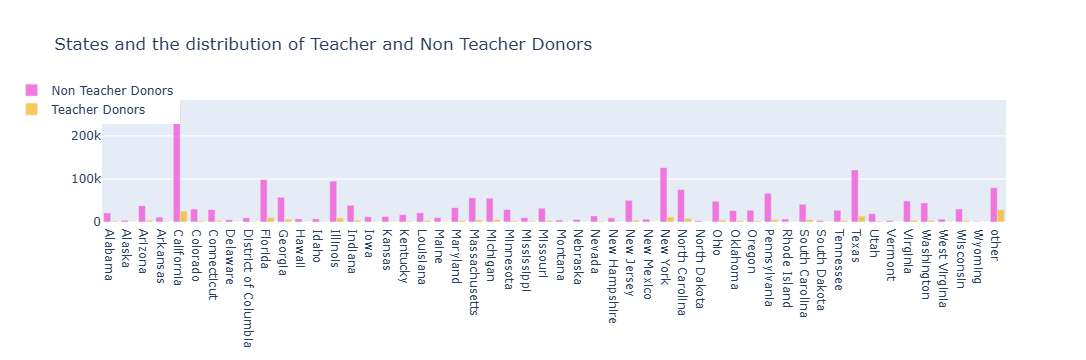

In [25]:
# which city and state has maximum teacher donors 
tempdf = donors_df.groupby(['Donor State', 'Donor Is Teacher']).agg({'Donor Is Teacher' : 'count' }).rename(columns={'Donor Is Teacher' : 'Teacher Donor Counts'}).reset_index()

no_df = tempdf[tempdf['Donor Is Teacher']=='No']
no_x = no_df['Donor State']
no_y = no_df['Teacher Donor Counts']
yes_df = tempdf[tempdf['Donor Is Teacher']=='Yes']
yes_x = yes_df['Donor State']
yes_y = yes_df['Teacher Donor Counts']

trace1 = go.Bar(
    x=no_x,
    y=no_y,
    name='Non Teacher Donors',
    marker=dict(color='#f259d6'),
    opacity=0.8
)
trace2 = go.Bar(
    x=yes_x,
    y=yes_y,
    name='Teacher Donors',
    marker=dict(color='#f7bb31'),
    opacity=0.8
)

data = [trace1, trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title = 'States and the distribution of Teacher and Non Teacher Donors',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

> El número de donantes que son docentes es siempre muy bajo en todos los estados. Los registros con el estado "others" muestran el mayor número de donantes maestros, aproximadamente 28.000.

## <a id="3">3. Exploración de las donaciones</a>

El archivo de donaciones incluye información sobre las donaciones realizadas: importe, si incluye donación opcional, secuencia de carrito del donante, fecha, ID del proyecto e ID del donante.

## <a id="3.1">3.1 Resumen de donaciones</a>

In [26]:
donations_df[['Donation ID', 'Donation Included Optional Donation', 'Donation Amount',
       'Donor Cart Sequence', 'Donation Received Date', 'Project ID', 'Donor ID']].head(3)
# donations_df.columns

# len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 20000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 10000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] < 1])
# np.mean(donations_df['Donation Amount'])

,Donation ID,Donation Included Optional Donation,Donation Amount,Donor Cart Sequence,Donation Received Date,Project ID,Donor ID
0,688729120858666221208529ee3fc18e,No,178.37,11,2016-08-23 13:15:57,000009891526c0ade7180f8423792063,1f4b5b6e68445c6c4a0509b3aca93f38
1,dcf1071da3aa3561f91ac689d1f73dee,Yes,25.00,2,2016-06-06 20:05:23,000009891526c0ade7180f8423792063,4aaab6d244bf3599682239ed5591af8a
2,18a234b9d1e538c431761d521ea7799d,Yes,20.00,3,2016-06-06 14:08:46,000009891526c0ade7180f8423792063,0b0765dc9c759adc48a07688ba25e94e


Hasta abril de 2018, se habían registrado un total de **4.687.884 donaciones** en DonorsChoose. La mayor donación, de **60.000 USD**, se realizó en 2013. Solo **6 donaciones superaron los 20.000 USD**, mientras que **61 superaron los 10.000 USD**. La mayoría de los pagos (aproximadamente el **83%** del total de donaciones) fueron **inferiores a 100 USD**. Hubo 350 pagos inferiores a 1 USD (una cantidad pequeña, pero que aun así puede marcar la diferencia). Hasta abril de 2018, DonorsChoose había recaudado la enorme suma de **284.408.243 USD** a través de su plataforma. El promedio de donaciones en DonorsChoose fue de 60 USD. En las siguientes secciones, analizaremos los detalles de los donantes y los proyectos relacionados con estas donaciones.

## <a id="3.2"> 3.2 Proyectos y sus donaciones </a>

Identifiquemos los proyectos más destacados y sus atributos:

- 3.2.1 Proyectos con el mayor número de donantes
- 3.2.2 Proyectos con el mayor monto total recaudado
- 3.2.3 Proyectos con el mayor promedio de donaciones por donante
- 3.2.4 Proyectos con la mayor cantidad donada en una sola transacción

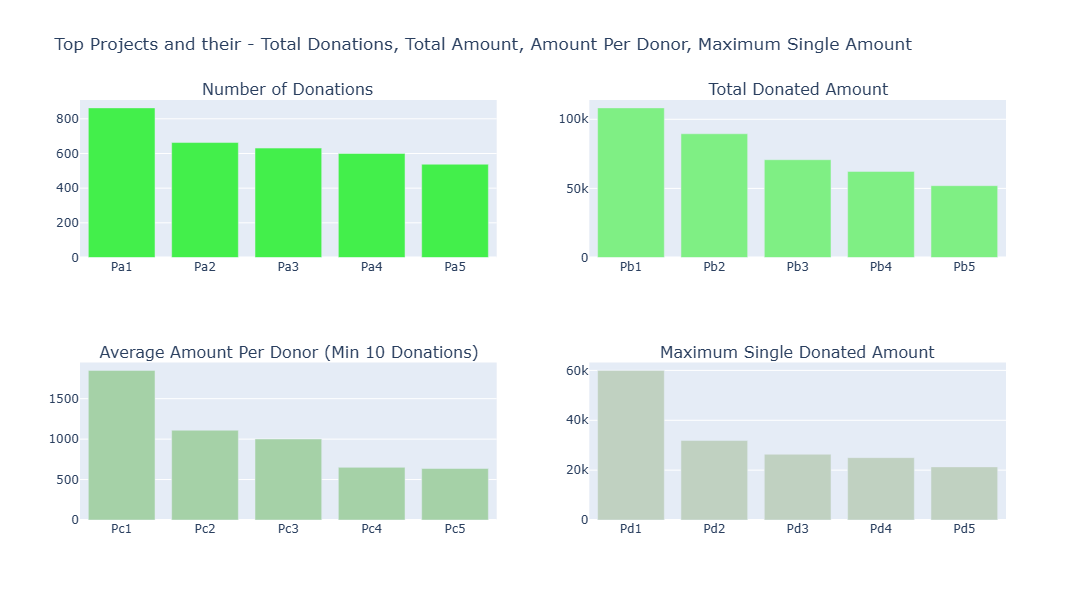

In [27]:
# Which Projects Had the maximum Donations 

tempdf = donations_df.groupby('Project ID').agg({'Project ID' : 'count', 'Donation Amount' : 'sum'}).rename(columns={'Project ID' : "Total Donations", 'Donation Amount' : "Total Amount"}).reset_index()
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Total Donations']

tempdf1 = tempdf.sort_values(by=['Total Donations'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pa"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Donations']
tr1 = bar_ver_noagg(x, y, 'Total Donations', '#43ef4b', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pb"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']
tr2 = bar_ver_noagg(x, y, 'Average Donations', '#7fef84', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])
x = tempdf1[tempdf1['Total Donations'] > 10].head(5)['Project ID']
x = ["Pc"+str(i+1) for i in range(len(x))]
y = tempdf1[tempdf1['Total Donations'] > 10].head(5)['Average Donation Amount']
tr3 = bar_ver_noagg(x, y, 'Average Donations (Min: 10 Donations)', '#a5d1a7', lm=None, rt=True)

tempdf = donations_df.groupby('Project ID').agg({'Project ID' : 'count', 'Donation Amount' : 'max'}).rename(columns={'Project ID' : "Total Donations", 'Donation Amount' : "Maximum Donations"}).reset_index()
tempdf1 = tempdf.sort_values(by=['Maximum Donations'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pd"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Maximum Donations']
tr4 = bar_ver_noagg(x, y, 'Maximum Donations', '#c0d1c1', lm=None, rt=True)



fig = tools.make_subplots(rows=2, cols=2, print_grid=False, subplot_titles = ['Number of Donations', "Total Donated Amount", 'Average Amount Per Donor (Min 10 Donations)', 'Maximum Single Donated Amount'])
fig.append_trace(tr1, 1, 1);
fig.append_trace(tr2, 1, 2);
fig.append_trace(tr3, 2, 1);
fig.append_trace(tr4, 2, 2);

fig['layout'].update(height=600, showlegend=False, title='Top Projects and their - Total Donations, Total Amount, Amount Per Donor, Maximum Single Amount');
iplot(fig); 

> - **Proyectos destacados**
> - En la historia de DonorsChoose, los distintos proyectos recibieron un número variable de donaciones, desde 1 hasta 800. El número máximo de donaciones recibidas en un solo proyecto es de 863. Este fue un proyecto liderado por un profesor y se tituló "**¡Escuela piloto de pie de Vallecito StandUpKids!**" (como se muestra como Pa1 en el primer gráfico). Se financió un total de **USD 108248.30** y se completó el 26 de agosto de 2015.
> - Hay otros tres proyectos con un número muy elevado de donaciones (superior a 600).
> - En noviembre de 2016, se inició un proyecto titulado "**Equipos de esgrima universitarios y extraescolares en Nueva York**" (como se muestra como Pc1 en el segundo gráfico) y se recibieron 18 donaciones en total. Este proyecto tuvo el promedio más alto por donante, igual a **USD 1850**.
> - En el proyecto titulado «**¡Aprende a jugar mientras juegas para aprender!**» (como se muestra como Pd1 en el cuarto gráfico), se donó la cantidad máxima en una sola donación, igual a **USD 60 000**, la mayor cantidad en la historia de DonorsChoose.

## <a id="3.3"> 3.3 ¿Quiénes son los principales donantes? </a>

Identifiquemos a los donantes que realizaron las mayores contribuciones y sus montos. Por ejemplo:

- 3.3.1 Donantes con el mayor número de donaciones
- 3.3.2 Donantes con las mayores cantidades totales
- 3.3.3 Donantes con los promedios más altos en donaciones individuales
- 3.3.4 Donantes con la mayor cantidad máxima donada en una sola donación

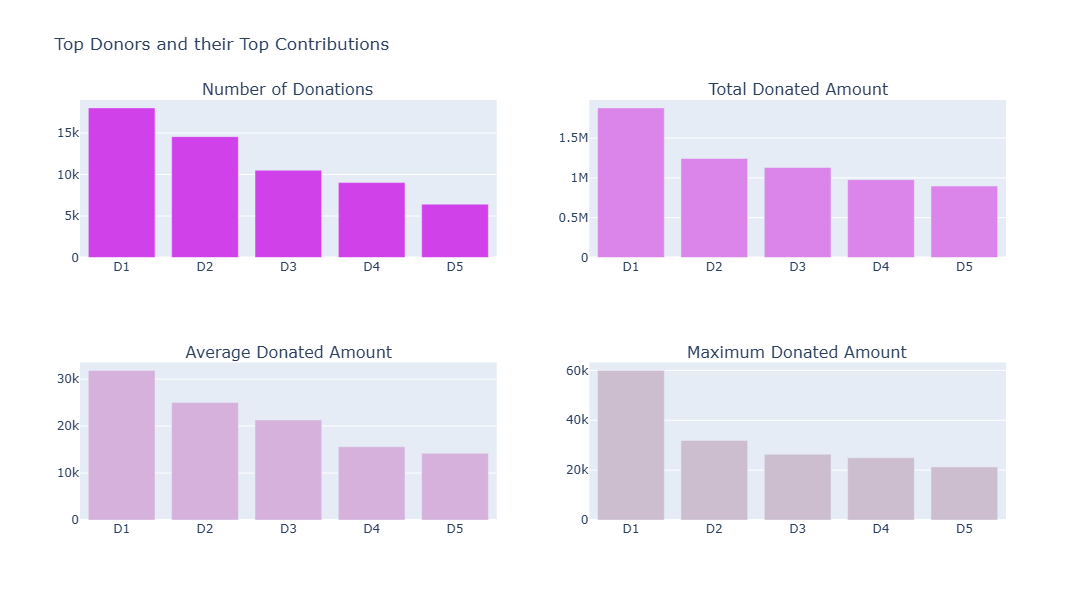

In [28]:
# Which Projects Had the maximum Donations 

tempdf = donations_df.groupby('Donor ID').agg({'Donor ID' : 'count', 'Donation Amount' : 'sum'}).rename(columns={'Donor ID' : "Total Donations", 'Donation Amount' : "Total Amount"}).reset_index()
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Total Donations']

tempdf1 = tempdf.sort_values(by=['Total Donations'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Donations']
tr1 = bar_ver_noagg(x, y, 'Total Donations', '#d141ea', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']
tr2 = bar_ver_noagg(x, y, 'Average Donations', '#db85ea', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Average Donation Amount']
tr3 = bar_ver_noagg(x, y, 'Average Donations', '#d5b1db', lm=None, rt=True)

tempdf = donations_df.groupby('Donor ID').agg({'Donor ID' : 'count', 'Donation Amount' : 'max'}).rename(columns={'Donor ID' : "Total Donations", 'Donation Amount' : "Maximum Donations"}).reset_index()
tempdf1 = tempdf.sort_values(by=['Maximum Donations'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Maximum Donations']
tr4 = bar_ver_noagg(x, y, 'Maximum Donations', '#ccbece', lm=None, rt=True)

fig = tools.make_subplots(rows=2, cols=2, print_grid=False, subplot_titles = ['Number of Donations', "Total Donated Amount", 'Average Donated Amount', 'Maximum Donated Amount'])
fig.append_trace(tr1, 1, 1);
fig.append_trace(tr2, 1, 2);
fig.append_trace(tr3, 2, 1);
fig.append_trace(tr4, 2, 2);

fig['layout'].update(height=600, showlegend=False, title='Top Donors and their Top Contributions');
iplot(fig); 

> - **Donantes más generosos:**

- Un donante no docente de **Manhattan Beach, California** ha donado más de **18.000 veces** (indicado como D1 en el gráfico superior izquierdo) en DonorsChoose. Otro donante no docente de Nueva York ha donado un total de **1,8 millones de dólares** en aproximadamente 10.513 donaciones (indicado como D1 en el gráfico superior derecho).

- El pago único más alto, de **60.000 dólares**, para el proyecto «Aprender a jugar mientras se aprende jugando» fue realizado por un donante de **Anahola, Hawái**, quien ha realizado un total de 223 donaciones hasta la fecha.

## <a id="3.4"> 3.4 ¿Qué importes de donación se recibieron y en qué momentos? </a>

### Donaciones por año

- 3.4.1 Número de donaciones por año

- 3.4.2 Importe promedio de las donaciones por año

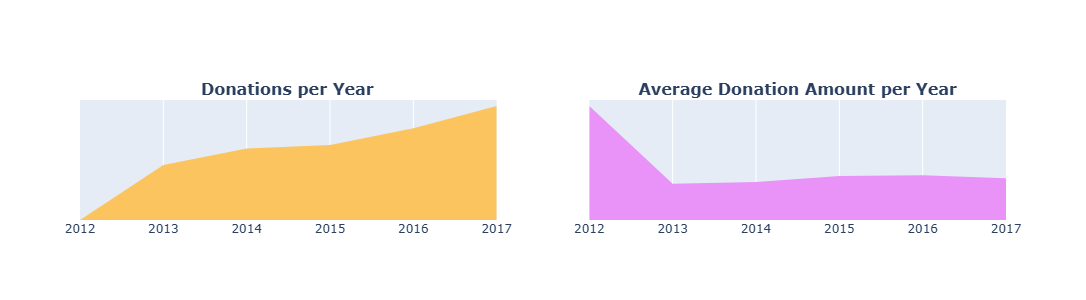

In [34]:
donations_df['Donation Date'] = pd.to_datetime(donations_df['Donation Received Date'])
donations_df['Donation Year'] = donations_df['Donation Date'].dt.year
donations_df['Donation Month'] = donations_df['Donation Date'].dt.month
donations_df['Donation Day'] = donations_df['Donation Date'].dt.day
donations_df['Donation Weekday'] = donations_df['Donation Date'].dt.weekday
donations_df['Donation Hour'] = donations_df['Donation Date'].dt.hour

t1 = donations_df.groupby(['Donation Year']).agg({'Donation Month' : 'count', 'Donation Amount' : 'mean'}).reset_index().rename(columns={'Donation Month' : 'Total Donations', 'Donation Amount' : 'Average Amount'})
x = t1['Donation Year']
y1 = t1['Total Donations']
y2 = t1['Average Amount']
trace1 = go.Scatter(x=x[:-1], y=y1[:-1], fill='tozeroy', fillcolor = '#fcc45f', mode= 'none')
trace2 = go.Scatter(x=x[:-1], y=y2[:-1], fill='tozeroy', fillcolor = "#e993f9", mode= 'none')
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["<b>Donations per Year</b>", "<b>Average Donation Amount per Year</b>"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);

fig['layout'].update(height=300, showlegend=False, yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
       
        ticks='',
        showticklabels=False
    ), yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
       
        ticks='',
        showticklabels=False
    ));
iplot(fig); 

Desde 2012, el número de donaciones en DonorsChoose ha aumentado de forma constante. Con aproximadamente 150 donaciones recibidas en 2012, DonorsChoose recibió alrededor de **1,1 millones de donaciones** en 2017. La mayor cantidad recibida ese año fue de **USD 31.856**, proveniente de un donante de **Lafayette, Colorado**. Esta donación se recibió el 2 de marzo de 2017.
Ese mismo año, se recibió una cantidad enorme de donaciones de un donante de **Manhattan Beach, California**, quien donó **13.751**.

El promedio de donaciones anuales ronda los **USD 60**, mientras que el máximo se registró en el año de inicio, 2012, con **USD 166**.

### Donaciones mensuales
- 3.4.3 Número de donaciones mensuales
- 3.4.4 Donaciones promedio mensuales

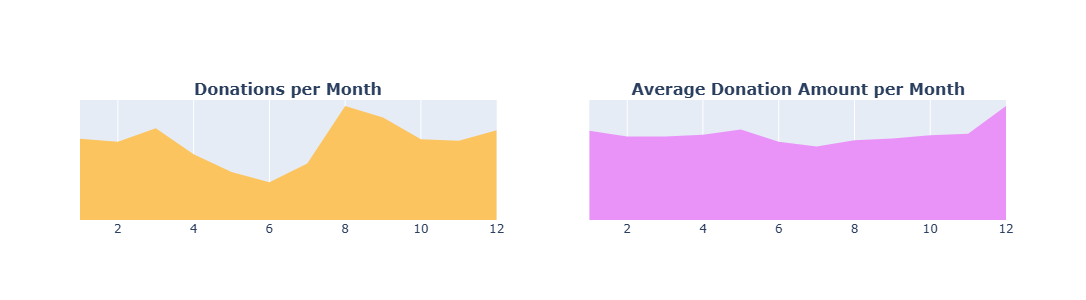

In [35]:
t2 = donations_df.groupby(['Donation Month']).agg({'Donation Year' : 'count', 'Donation Amount' : 'mean'}).reset_index().rename(columns={'Donation Year' : 'Total Donations', 'Donation Amount' : 'Average Amount'})
x = t2['Donation Month']
y1 = t2['Total Donations']
y2 = t2['Average Amount']
trace1 = go.Scatter(x=x, y=y1, fill='tozeroy', fillcolor = '#fcc45f', mode= 'none')
trace2 = go.Scatter(x=x, y=y2, fill='tozeroy', fillcolor = "#e993f9", mode= 'none')
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["<b>Donations per Month</b>", "<b>Average Donation Amount per Month</b>"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);

fig['layout'].update(height=300, showlegend=False, yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        
        ticks='',
        showticklabels=False
    ), yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
     
        ticks='',
        showticklabels=False
    ));


iplot(fig); 

El mayor número de donaciones se recibió en agosto, con 577.274, seguido de septiembre, con 518.908. El menor número de donaciones se registró en junio, con 191.221, y en mayo, con 243.440, probablemente debido a la temporada de verano y vacaciones. El promedio más alto de donaciones se recibió en diciembre, con 80 USD, mientras que el más bajo se registró en julio, con 51 USD. En promedio, el monto promedio de donaciones anuales ronda los 59 USD.

### Donaciones por mes/día
- 3.4.5 Número de donaciones por mes/día
- 3.4.6 Promedio de donaciones por mes/día

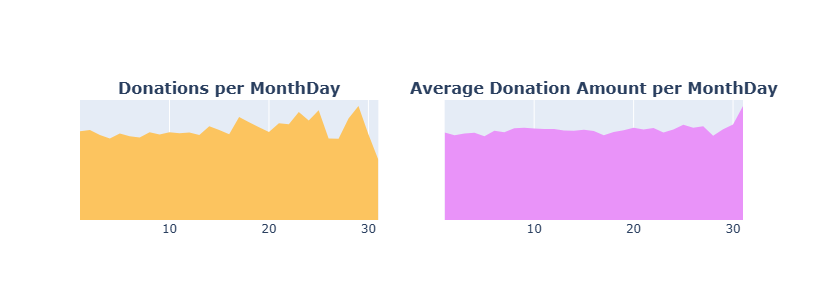

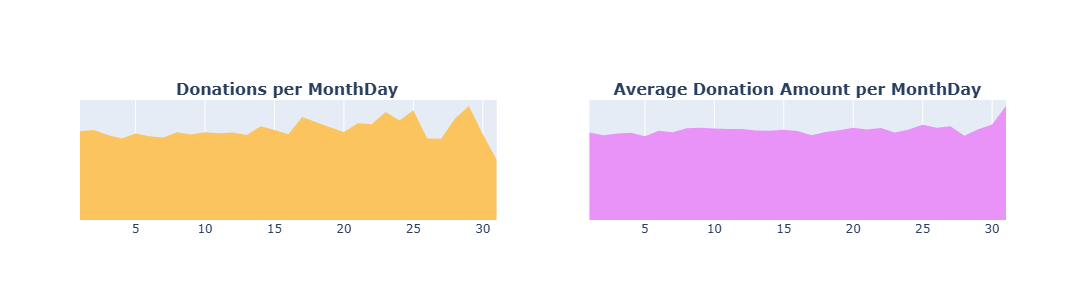

In [38]:

t3 = donations_df.groupby(['Donation Day']).agg({'Donation Year' : 'count', 'Donation Amount' : 'mean'}).reset_index().rename(columns={'Donation Year' : 'Total Donations', 'Donation Amount' : 'Average Amount'})
x = t3['Donation Day']
y1 = t3['Total Donations']
y2 = t3['Average Amount']
trace1 = go.Scatter(x=x, y=y1, fill='tozeroy', fillcolor = '#fcc45f', mode= 'none')
trace2 = go.Scatter(x=x, y=y2, fill='tozeroy', fillcolor = "#e993f9", mode= 'none')
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["<b>Donations per MonthDay</b>", "<b>Average Donation Amount per MonthDay</b>"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);

fig['layout'].update(height=300, showlegend=False, yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
      
        ticks='',
        showticklabels=False
    ), yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        
        ticks='',
        showticklabels=False
    ));
iplot(fig); 

t3 = donations_df.groupby(['Donation Day']).agg({'Donation Year' : 'count', 'Donation Amount' : 'mean'}).reset_index().rename(columns={'Donation Year' : 'Total Donations', 'Donation Amount' : 'Average Amount'})
x = t3['Donation Day']
y1 = t3['Total Donations']
y2 = t3['Average Amount']
trace1 = go.Scatter(x=x, y=y1, fill='tozeroy', fillcolor = '#fcc45f', mode= 'none')
trace2 = go.Scatter(x=x, y=y2, fill='tozeroy', fillcolor = "#e993f9", mode= 'none')
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["<b>Donations per MonthDay</b>", "<b>Average Donation Amount per MonthDay</b>"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);

fig['layout'].update(height=300, showlegend=False, yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        
        ticks='',
        showticklabels=False
    ), yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        
        ticks='',
        showticklabels=False
    ));
iplot(fig); 


### Donations per WeekDay 
- 3.4.7 Number of Donations per WeekDay 
- 3.4.8 Average Donations per WeekDay

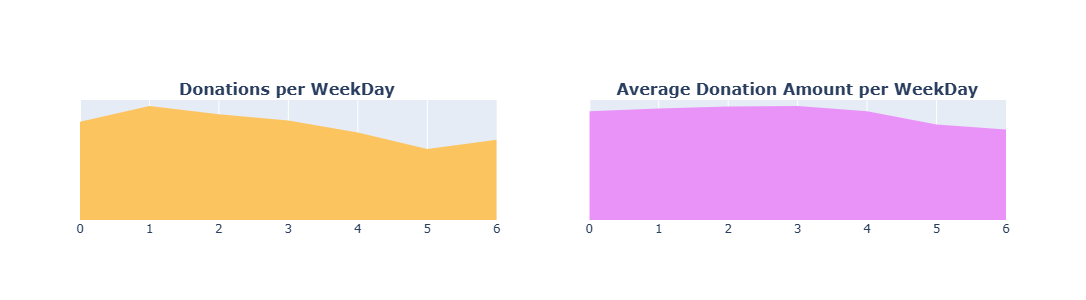

In [39]:

t4 = donations_df.groupby(['Donation Weekday']).agg({'Donation Year' : 'count', 'Donation Amount' : 'mean'}).reset_index().rename(columns={'Donation Year' : 'Total Donations', 'Donation Amount' : 'Average Amount'})
x = t4['Donation Weekday']
y1 = t4['Total Donations']
y2 = t4['Average Amount']
trace1 = go.Scatter(x=x, y=y1, fill='tozeroy', fillcolor = '#fcc45f', mode= 'none')
trace2 = go.Scatter(x=x, y=y2, fill='tozeroy', fillcolor = "#e993f9", mode= 'none')
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["<b>Donations per WeekDay</b>", "<b>Average Donation Amount per WeekDay</b>"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);

fig['layout'].update(height=300, showlegend=False, yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
       
        ticks='',
        showticklabels=False
    ), yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        
        ticks='',
        showticklabels=False
    ));
iplot(fig); 


El número de donaciones es mayor los primeros días de la semana (lunes, martes y miércoles), con 700.000, 800.000 y 750.000 donaciones totales, respectivamente. La cantidad disminuye a medida que avanza la semana. El menor número de donaciones se recibe los sábados, como se observa en el gráfico.

### Donaciones por hora
- 3.4.9 Número de donaciones por hora
- 3.4.10 Promedio de donaciones por hora

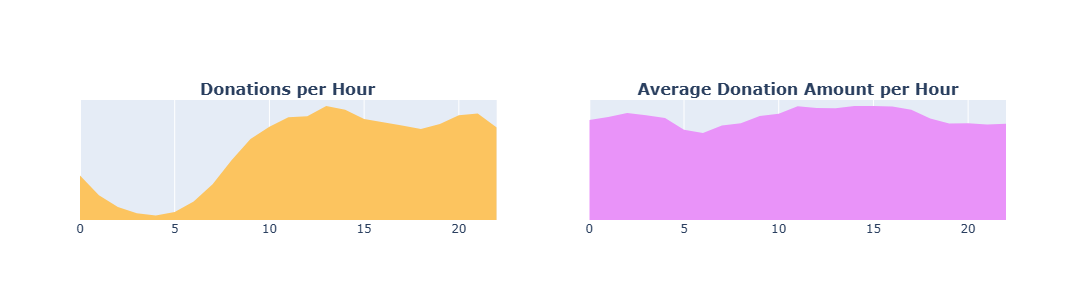

In [40]:
t5 = donations_df.groupby(['Donation Hour']).agg({'Donation Month' : 'count', 'Donation Amount' : 'mean'}).reset_index().rename(columns={'Donation Month' : 'Total Donations', 'Donation Amount' : 'Average Amount'})
x = t5['Donation Hour']
y1 = t5['Total Donations']
y2 = t5['Average Amount']
trace1 = go.Scatter(x=x[:-1], y=y1[:-1], fill='tozeroy', fillcolor = '#fcc45f', mode= 'none')
trace2 = go.Scatter(x=x[:-1], y=y2[:-1], fill='tozeroy', fillcolor = "#e993f9", mode= 'none')
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["<b>Donations per Hour</b>", "<b>Average Donation Amount per Hour</b>"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);

fig['layout'].update(height=300, showlegend=False, yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        
        ticks='',
        showticklabels=False
    ), yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        
        ticks='',
        showticklabels=False
    ));
iplot(fig); 


## <a id="3.5"> 3.5 Optional Donations and Teacher Donors </a>

### <a id="3.5.1"> 3.5.1 Total Optional Donations and their Associated Average Amounts </a> 

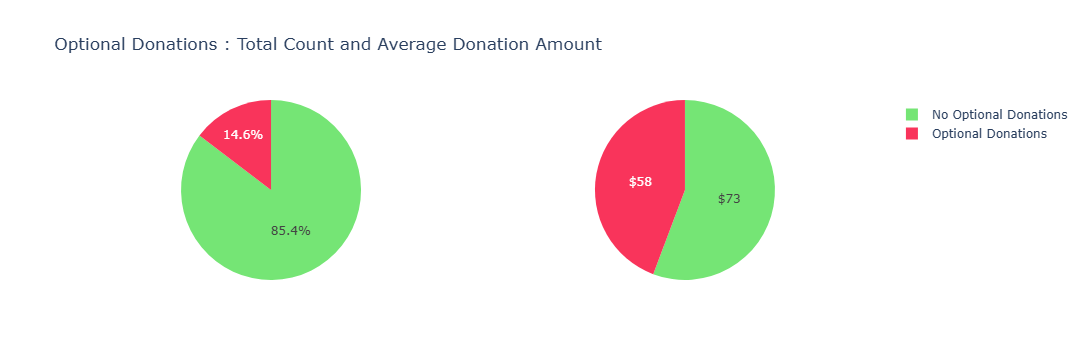

In [41]:
tempdf = donations_df.groupby('Donation Included Optional Donation').agg({'Donation Included Optional Donation' : 'count', 'Donation Amount' : 'mean'})
values1 = list(tempdf['Donation Included Optional Donation']) 
values2 = list(tempdf['Donation Amount']) 
values2t = [str("$")+str(int(x)) for x in values2]
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

labels = list(tempdf.index)
mp={'Yes' : 'Optional Donations', 'No' : 'No Optional Donations'}
labels = [mp[x] for x in labels]
trace1 = go.Pie(labels=labels, values=values1, marker=dict(colors=[  '#75e575', '#ea7c96',]))
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]), textinfo = "text", text=values2t)

layout = go.Layout(title='Number of Donations with Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace1], layout=layout)
# iplot(fig)

layout = go.Layout(title='Average Amount Donated in Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace2], layout=layout)
# iplot(fig)

fig = {
  "data": [
    {
      "values": values1,
      "labels": list(reversed(labels)),
      "domain": {"x": [0, .48]},
    "marker" : dict(colors=[  '#f9345b',  '#75e575']),
      "name": "No. of donations with Optional Donations",
#       "hoverinfo":"label+percent+name",
#       "hole": .4,
        
      "type": "pie"
    },
    {
      "values": values2,
      "labels": labels,
        "marker" : dict(colors=['75e575', '#f9345b']),
      "domain": {"x": [.52, 1]},
      "name": "Average Amount Donated in Optional Donations",
        "text" : values2t,
        "textinfo" : "text",
      "type": "pie"
    }],
  "layout": {
        "title":"Optional Donations : Total Count and Average Donation Amount",
    
    }
}
iplot(fig, filename='donut')

Los proyectos de DonorChoose también ofrecen la opción de donaciones opcionales. El monto promedio de las donaciones opcionales es de **USD 58**, mientras que para las donaciones obligatorias es de **USD 73**. De todas las donaciones realizadas, aproximadamente el **15%** fueron opcionales.

### <a href="3.5.2"> 3.5.2 Total de donaciones de docentes y montos promedio asociados </a>

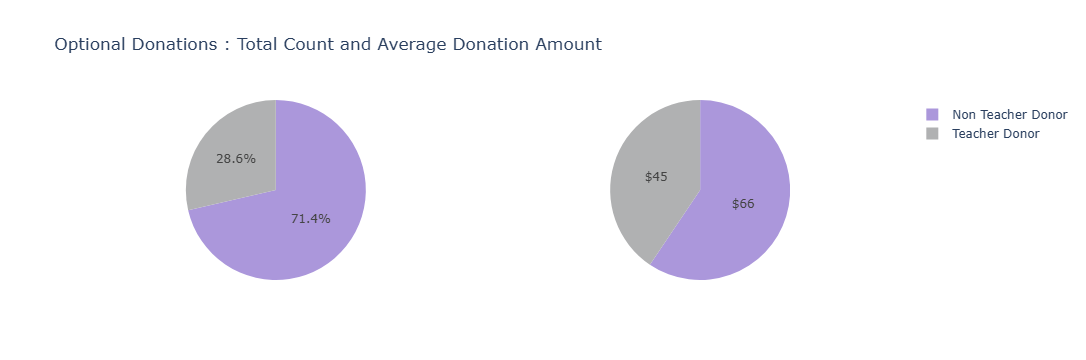

In [42]:
# lets combine donors and donations 
combined_df = donations_df.merge(donors_df, on='Donor ID', how='inner')
# combined_df.head(10)

tempdf = combined_df.groupby('Donor Is Teacher').agg({'Donor Is Teacher' : 'count', 'Donation Amount' : 'mean'})
values1 = list(tempdf['Donor Is Teacher']) 
values2 = list(tempdf['Donation Amount']) 
values2t = [str("$")+str(int(x)) for x in values2]
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

labels = list(tempdf.index)
mp={'Yes' : 'Teacher Donor', 'No' : 'Non Teacher Donor'}
labels = [mp[x] for x in labels]
trace1 = go.Pie(labels=labels, values=values1, marker=dict(colors=[  '#75e575', '#ea7c96',]))
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]), textinfo = "text", text=values2t)

layout = go.Layout(title='Number of Donations with Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace1], layout=layout)
# iplot(fig)

layout = go.Layout(title='Average Amount Donated in Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace2], layout=layout)
# iplot(fig)

fig = {
  "data": [
    {
      "values": values1,
      "labels": labels,
      "domain": {"x": [0, .48]},
    "marker" : dict(colors=[ '#ab97db',  '#b0b1b2']),
      "name": "No. of donations with Optional Donations",
#       "hoverinfo":"label+percent+name",
#       "hole": .4,
        
      "type": "pie"
    },
    {
      "values": values2,
      "labels": labels,
        "marker" : dict(colors=[ '#ab97db',  '#b0b1b2']),
      "domain": {"x": [.52, 1]},
      "name": "Average Amount Donated in Optional Donations",
        "text" : values2t,
        "textinfo" : "text",
      "type": "pie"
    }],
  "layout": {
        "title":"Optional Donations : Total Count and Average Donation Amount",
    
    }
}
iplot(fig, filename='donut')

Aproximadamente el **29%** del total de donaciones en DonorChoose proviene de donantes que también son docentes. La mayoría de estos donantes docentes son de California.

El monto promedio de donación de un docente es de **USD 45**, mientras que para los donantes que no son docentes es de **USD 66**.

In [45]:

def mapp(df, scl, t):
    state_to_code = {'District of Columbia' : 'dc','Mississippi': 'MS', 'Oklahoma': 'OK', 'Delaware': 'DE', 'Minnesota': 'MN', 'Illinois': 'IL', 'Arkansas': 'AR', 'New Mexico': 'NM', 'Indiana': 'IN', 'Maryland': 'MD', 'Louisiana': 'LA', 'Idaho': 'ID', 'Wyoming': 'WY', 'Tennessee': 'TN', 'Arizona': 'AZ', 'Iowa': 'IA', 'Michigan': 'MI', 'Kansas': 'KS', 'Utah': 'UT', 'Virginia': 'VA', 'Oregon': 'OR', 'Connecticut': 'CT', 'Montana': 'MT', 'California': 'CA', 'Massachusetts': 'MA', 'West Virginia': 'WV', 'South Carolina': 'SC', 'New Hampshire': 'NH', 'Wisconsin': 'WI', 'Vermont': 'VT', 'Georgia': 'GA', 'North Dakota': 'ND', 'Pennsylvania': 'PA', 'Florida': 'FL', 'Alaska': 'AK', 'Kentucky': 'KY', 'Hawaii': 'HI', 'Nebraska': 'NE', 'Missouri': 'MO', 'Ohio': 'OH', 'Alabama': 'AL', 'Rhode Island': 'RI', 'South Dakota': 'SD', 'Colorado': 'CO', 'New Jersey': 'NJ', 'Washington': 'WA', 'North Carolina': 'NC', 'New York': 'NY', 'Texas': 'TX', 'Nevada': 'NV', 'Maine': 'ME'}
    df['state_code'] = statesdf['state'].apply(lambda x : state_to_code[x] if x in state_to_code else "")

    data = [ dict(
            type='choropleth',
            colorscale = scl,
            autocolorscale = False,
            locations = df['state_code'],
            z = df['counts'],
            locationmode = 'USA-states',
            text = df['state'],
            marker = dict(
                line = dict (
                    color = 'rgb(255,255,255)',
                    width = 2
                ) ),
            colorbar = dict(
                title = "Donors")
            ) ]

    layout = dict(
            title = t,
            geo = dict(
                scope='usa',
                projection=dict( type='albers usa' ),
                showlakes = True,
                lakecolor = 'rgb(255, 255, 255)'),
                 )

    fig = dict( data=data, layout=layout )
    iplot( fig, filename='d3-cloropleth-map' )

## <a id="3.6"> 3.6 ¿Qué estados recibieron las mayores cantidades de donaciones individuales?</a>
- 3.6.1 Estados con las mayores cantidades de donaciones
- 3.6.2 Ciudades con las mayores cantidades de donaciones

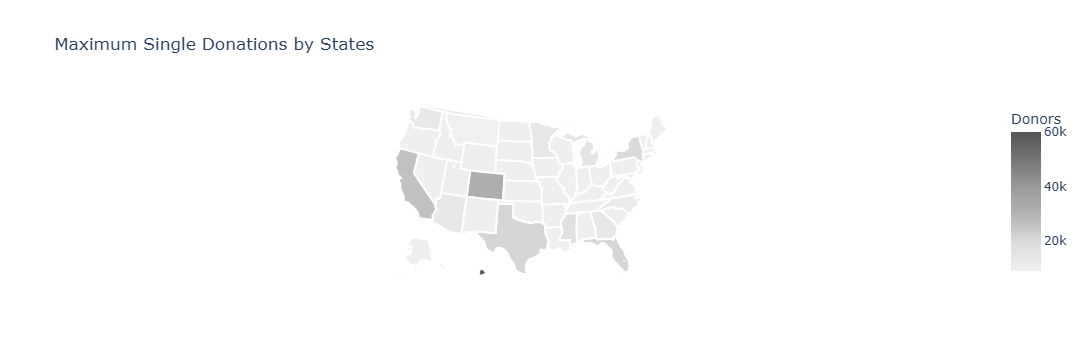

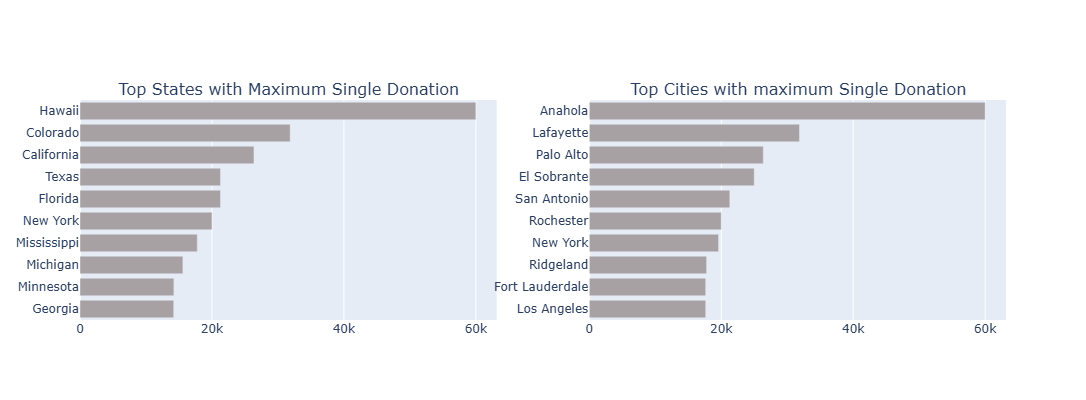

In [46]:
  # Maximum Donation Amounts 
tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'max'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

tempdf = combined_df.groupby(['Donor City']).agg({'Donation Amount':'max'}).reset_index()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

statesdf = pd.DataFrame()
statesdf['state'] = t1['Donor State']
statesdf['counts'] = t1['Donation Amount']
statesdf

citydf = pd.DataFrame()
citydf['state'] = t2['Donor City']
citydf['counts'] = t2['Donation Amount']
citydf


scl = [[0.0, 'rgb(240,240,240)'],[0.2, 'rgb(220,220,220)'],[0.4, 'rgb(180,180,180)'], [0.6, 'rgb(154,154,154)'],[0.8, 'rgb(117,117,117)'],[1.0, 'rgb(84,84,84)']]
mapp(statesdf, scl, 'Maximum Single Donations by States')

trace1 = bar_hor_noagg(list(reversed(list(statesdf['state'][:10]))), list(reversed(list(statesdf['counts'][:10]))), "Top Cities with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
trace2 = bar_hor_noagg(list(reversed(list(citydf['state'][:10]))), list(reversed(list(citydf['counts'][:10]))), "Top States with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['Top States with Maximum Single Donation','Top Cities with maximum Single Donation'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);
  

Hawái y Colorado son los estados con menor número de donaciones, pero de donde provienen las mayores cantidades.
Las ciudades de Anahola, Lafayette y Palo Alto han contribuido con las mayores cantidades: 60.000, 31.000 y 26.000, respectivamente.

## <a id="3.7"> 3.7 ¿Qué estado recibe el mayor promedio de donaciones?</a>

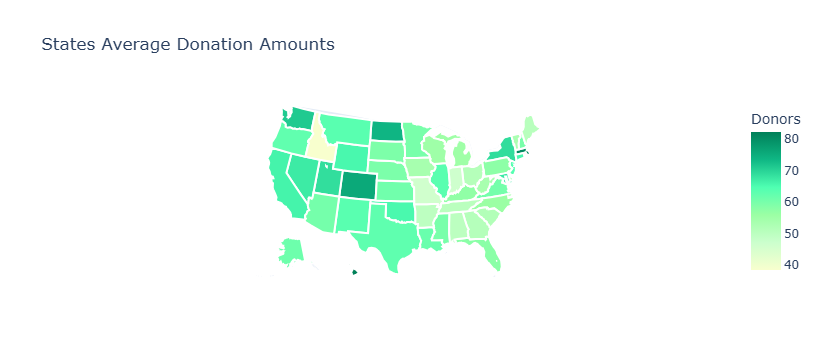

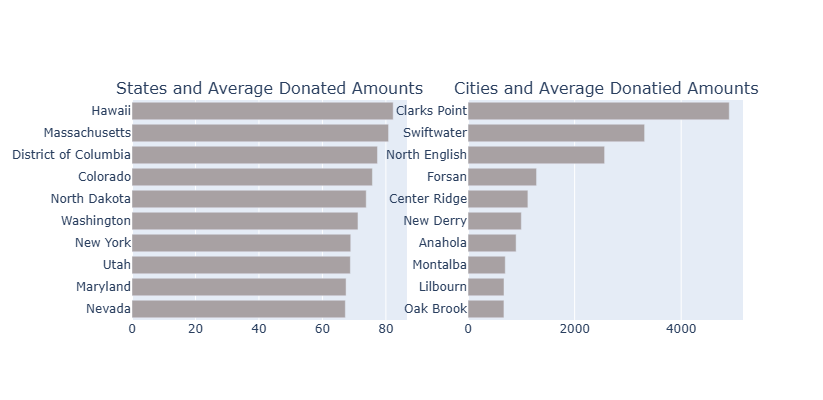

In [47]:
# Mean Donation Amounts 
tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'mean'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

tempdf = combined_df.groupby(['Donor City']).agg({'Donation Amount':'mean'}).reset_index()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

statesdf = pd.DataFrame()
statesdf['state'] = t1['Donor State']
statesdf['counts'] = t1['Donation Amount']
statesdf

citydf = pd.DataFrame()
citydf['state'] = t2['Donor City']
citydf['counts'] = t2['Donation Amount']
citydf
scl = [[0.0, 'rgb(248,255,206)'],[0.2, 'rgb(203,255,205)'],[0.4, 'rgb(155,255,164)'], [0.6, 'rgb(79,255,178)'],[0.8, 'rgb(15,183,132)'], [1, '#008059']]
# scl = [[0.0, 'rgb(240,240,240)'],[0.2, 'rgb(220,220,220)'],[0.4, 'rgb(180,180,180)'], [0.6, 'rgb(154,154,154)'],[0.8, 'rgb(117,117,117)'],[1.0, 'rgb(84,84,84)']]
mapp(statesdf, scl, 'States Average Donation Amounts')

trace1 = bar_hor_noagg(list(reversed(list(statesdf['state'][:10]))), list(reversed(list(statesdf['counts'][:10]))), "Top Cities with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
trace2 = bar_hor_noagg(list(reversed(list(citydf['state'][:10]))), list(reversed(list(citydf['counts'][:10]))), "Top States with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['States and Average Donated Amounts','Cities and Average Donatied Amounts'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);

Hawái y Massachusetts registran los montos promedio de donaciones más altos.
Clarks Point, Swiftwater y North English son las ciudades que reciben los montos promedio de donaciones más altos.
## <a id="3.8"> 3.8 Montos totales donados por cada estado </a>

In [48]:
statesll=StringIO("""State,Latitude,Longitude
Alabama,32.806671,-86.791130
Alaska,61.370716,-152.404419
Arizona,33.729759,-111.431221
Arkansas,34.969704,-92.373123
California,36.116203,-119.681564
Colorado,39.059811,-105.311104
Connecticut,41.597782,-72.755371
Delaware,39.318523,-75.507141
District of Columbia,38.897438,-77.026817
Florida,27.766279,-81.686783
Georgia,33.040619,-83.643074
Hawaii,21.094318,-157.498337
Idaho,44.240459,-114.478828
Illinois,40.349457,-88.986137
Indiana,39.849426,-86.258278
Iowa,42.011539,-93.210526
Kansas,38.526600,-96.726486
Kentucky,37.668140,-84.670067
Louisiana,31.169546,-91.867805
Maine,44.693947,-69.381927
Maryland,39.063946,-76.802101
Massachusetts,42.230171,-71.530106
Michigan,43.326618,-84.536095
Minnesota,45.694454,-93.900192
Mississippi,32.741646,-89.678696
Missouri,38.456085,-92.288368
Montana,46.921925,-110.454353
Nebraska,41.125370,-98.268082
Nevada,38.313515,-117.055374
New Hampshire,43.452492,-71.563896
New Jersey,40.298904,-74.521011
New Mexico,34.840515,-106.248482
New York,42.165726,-74.948051
North Carolina,35.630066,-79.806419
North Dakota,47.528912,-99.784012
Ohio,40.388783,-82.764915
Oklahoma,35.565342,-96.928917
Oregon,44.572021,-122.070938
Pennsylvania,40.590752,-77.209755
Rhode Island,41.680893,-71.511780
South Carolina,33.856892,-80.945007
South Dakota,44.299782,-99.438828
Tennessee,35.747845,-86.692345
Texas,31.054487,-97.563461
Utah,40.150032,-111.862434
Vermont,44.045876,-72.710686
Virginia,37.769337,-78.169968
Washington,47.400902,-121.490494
West Virginia,38.491226,-80.954453
Wisconsin,44.268543,-89.616508
Wyoming,42.755966,-107.302490""")

tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'sum'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

sdf = pd.read_csv(statesll).rename(columns={'State':'Donor State'})
sdf = sdf.merge(t1, on='Donor State', how='inner')

map4 = folium.Map(location=[39.50, -98.35], tiles='CartoDB dark_matter', zoom_start=3.5)
for j, rown in sdf.iterrows():
    rown = list(rown)
    folium.CircleMarker([float(rown[1]), float(rown[2])], popup=rown[0]+": $"+str(int(rown[3])), radius=float(rown[3])*0.000001, color='blue', fill=True).add_to(map4)
map4

## <a id="3.9"> 3.9 Donaciones de California a lo largo del tiempo</a>

Veamos la evolución de las donaciones de California a lo largo de los años.

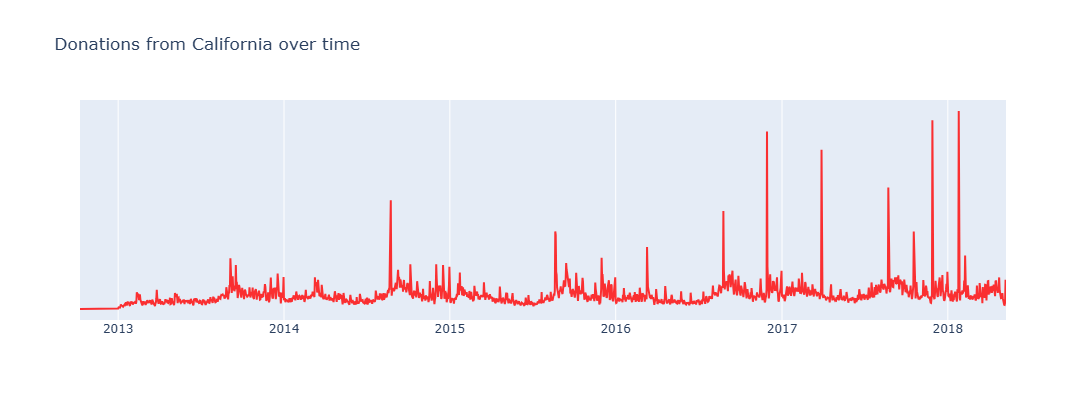

In [77]:
combined_df['Donation Date'] = combined_df['Donation Received Date'].apply(lambda x : str(x).split()[0])

cali = combined_df[combined_df['Donor State'] == 'California']
cali = cali.groupby('Donation Date').agg({'Donation Amount' : 'count'}).reset_index()
cali1 = pd.DataFrame()
cali1['Date'] = pd.to_datetime(cali['Donation Date']) 
cali1['Donation Amount'] = cali['Donation Amount']


trace1 = go.Scatter(x=cali1['Date'], y=cali1['Donation Amount'], name = "California", line = dict(color = 'red'), opacity = 0.8)

data = [trace1]
layout = dict(title="Donations from California over time", height=400, showlegend=False, yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        
        ticks='',
        showticklabels=False
    ))
fig = dict(data=data, layout=layout)
iplot(fig)

El mayor número de donaciones procedentes de California se registró el **25 de enero de 2018**, con casi 5000 donaciones, seguido del **28 de noviembre de 2017**, con 4699 donaciones.

## <a id="4"> 4. Exploración de los docentes </a>
## <a id="4.1"> 4.1 Resumen de los datos de los docentes </a>

In [50]:
teachers_df.head(3)
# len(teachers_df)

,Teacher ID,Teacher Prefix,Teacher First Project Posted Date
0,00000f7264c27ba6fea0c837ed6aa0aa,Mrs.,2013-08-21
1,00002d44003ed46b066607c5455a999a,Mrs.,2016-10-23
2,00006084c3d92d904a22e0a70f5c119a,Mr.,2016-09-08


En total, 402.900 docentes han publicado al menos un proyecto en DonorsChoose desde 2002. La gran mayoría son mujeres. Veamos quiénes fueron los primeros docentes en publicar proyectos en DonorsChoose.

## <a id="4.2"> 4.2 ¿Quiénes fueron los primeros docentes en DonorsChoose.org? </a>

In [51]:
teachers_df['Posted Date'] = pd.to_datetime(teachers_df['Teacher First Project Posted Date'])
teachers_df['Posted Year'] = teachers_df['Posted Date'].dt.year

# Lets Find out who were the first donors on DonorsChooseSome of the Earliest Teachers 
teachers_df[['Teacher ID', 'Posted Date']].sort_values(['Posted Date'])[:10]

,Teacher ID,Posted Date
280335,b218f64064e174657336d229e2231962,2002-09-17
245493,9c0aa56b63b743454d6da9effcf122fc,2002-09-17
77122,31367152c3ea88bfdf8a97848be8bd07,2002-09-19
357964,e3751e935d13de6b37864194955d1548,2002-09-19
245631,9c214c58003f1d4c82261404b8bbfcf5,2002-09-19
41877,1aacfb91eb392114236f0c38fa44f27b,2002-09-19
271224,ac3d575cd2d7a58063677162afd90f7d,2002-09-19
295166,bb9451ffe8ef76852f4030238a73ac41,2002-09-20
272164,acd4f1b0b4b698c27adc1828d0d3f77d,2002-10-11
292250,b9b643f2558b0e27cc69d93a0dc2f333,2002-11-05


Los primeros profesores en DonorsChoose se registraron el 17 de septiembre de 2002. Ese día se registraron dos profesoras. En septiembre de 2002, se registraron un total de ocho profesores, quienes conformaron el primer grupo de docentes en DonorsChoose.

## <a id="4.3"> 4..3 Crecimiento del número de profesores a lo largo de los años </a>

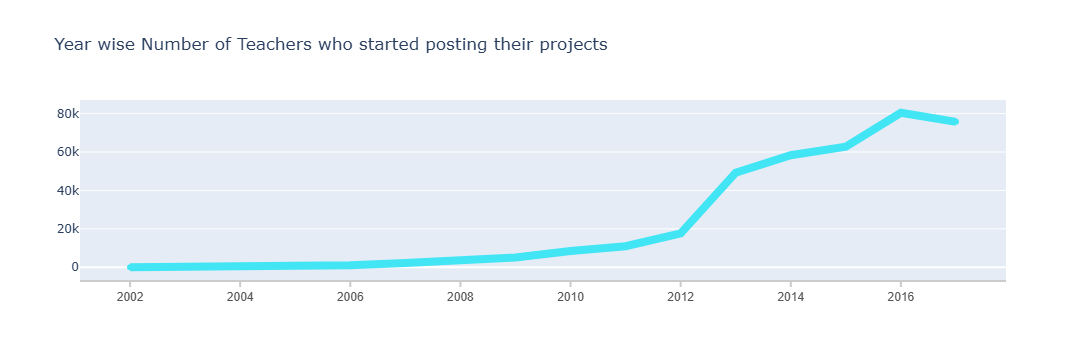

In [80]:
temp = teachers_df.groupby('Posted Year').agg({'Teacher ID' : 'count'}).reset_index()
temp = temp.sort_values('Posted Year')

trace = go.Scatter(
        x=list(temp['Posted Year'])[:-1],
        y=list(temp['Teacher ID'])[:-1],
        mode='lines+markers',
        line=dict(color="#42e5f4", width=8),
        connectgaps=True,
    fillcolor='rgba(0,100,80,0.2)',
    )

layout = go.Layout(
    xaxis=dict(
        showline=True,
        showgrid=False,
        showticklabels=True,
        linecolor='rgb(204, 204, 204)',
        linewidth=2,
        
        ticks='outside',
        tickcolor='rgb(204, 204, 204)',
        tickwidth=2,
        ticklen=5,
        tickfont=dict(
            family='Arial',
            size=12,
            color='rgb(82, 82, 82)',
        ),
    ),
    title = 'Year wise Number of Teachers who started posting their projects')



fig = go.Figure(data=[trace], layout=layout)
iplot(fig, filename='news-source')

> - Un número considerable de profesores comenzó a publicar en DonorChoose cuando se lanzó en 2002, pero durante los primeros cinco años la cantidad de profesores que publicaban proyectos fue muy baja.
> - Se observó una tendencia al alza alrededor de 2008 y, entre 2012 y 2013, se produjo un aumento masivo en el número de profesores que publicaban proyectos.
> - La tendencia alcanzó su punto máximo con 80.000 nuevos profesores publicando proyectos en 2016, pero la cifra descendió a 75.000 en 2017. No solo es necesario motivar a los donantes, sino también incentivar a los profesores a publicar más proyectos. A juzgar por el crecimiento de nuevos profesores a lo largo de los años, parece que DonorChoose está haciendo un buen trabajo.

## <a id="4.4"> 4.4 ¿Cuál es la distribución de los prefijos de los profesores? </a>

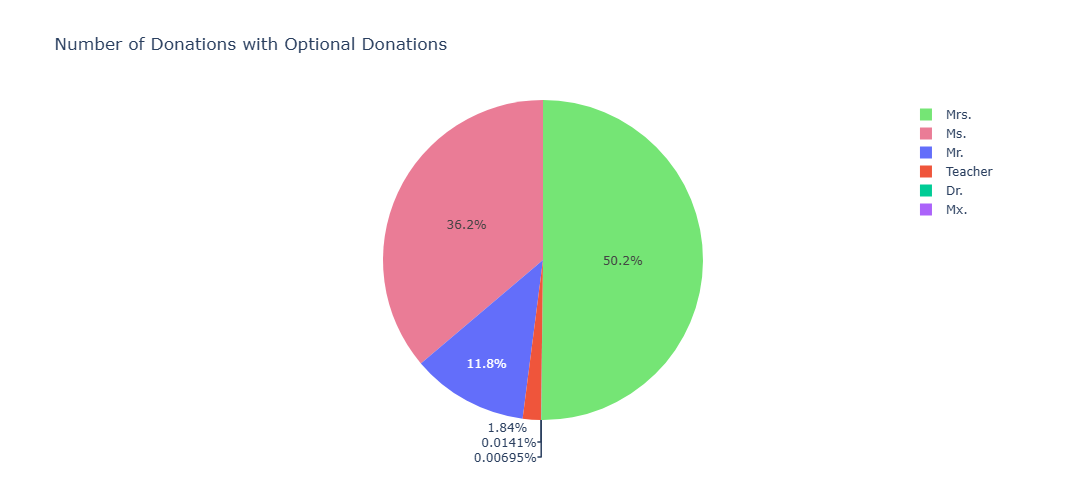

In [53]:

t = teachers_df['Teacher Prefix'].value_counts()

labels = t.index
values2 = t.values
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]))

layout = go.Layout(title='Number of Donations with Optional Donations', width=800, height=500)
fig = go.Figure(data=[trace2], layout=layout)
iplot(fig)

## <a id="4.5"> 4.5 Serie temporal de profesores que publican sus primeros proyectos </a>

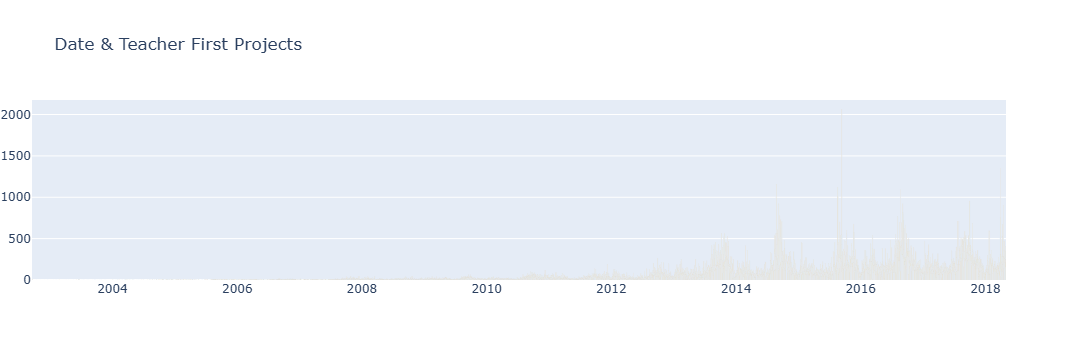

In [54]:
t = teachers_df['Posted Date'].value_counts()#[:10]
x = t.index
y = t.values
bar_ver_noagg(x, y, 'Date & Teacher First Projects', 'orange')

El mayor número de proyectos nuevos se observó el **13 de septiembre de 2015, con un total de 2067 proyectos**.

Es interesante observar que se registraron picos cada agosto desde 2014 hasta 2017.

## <a id="5"> 5. Exploración de escuelas </a>
## <a id="5.1"> 5.1 Resumen de datos de escuelas </a>

In [59]:
schools_df = pd.read_csv("./Schools.csv")
schools_df.head(3)
t

# len(schools_df)

Posted Date
2015-09-13    2067
2018-03-30    1350
2014-08-24    1157
2015-08-20    1125
2016-08-21    1095
              ... 
2005-11-11       1
2007-05-25       1
2007-03-24       1
2008-09-14       1
2005-04-29       1
Name: count, Length: 4699, dtype: int64

Hasta abril de 2018, se habían publicado proyectos de un total de 72.993 escuelas diferentes en donorschoose.

## <a id="5.2"> 5.2 Qué tipo de escuelas metropolitanas publican proyectos (y los estados y ciudades principales) </a>

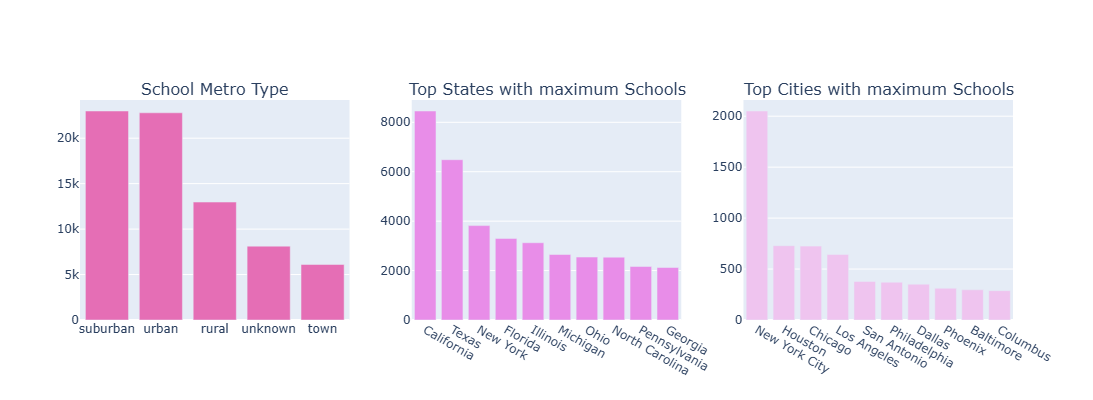

In [60]:
t1 = schools_df['School Metro Type'].value_counts()
t2 = schools_df['School State'].value_counts()
t3 = schools_df['School City'].value_counts()


trace1 = bar_ver_noagg(t1.index[:10], t1.values[:10], "School Metro Type", '#e56eb5', None, None, 0,  rt=True)
trace2 = bar_ver_noagg(t2.index[:10], t2.values[:10], "Top States with maximum Schools", '#e88de8', None, None, 0,  rt=True)
trace3 = bar_ver_noagg(t3.index[:10], t3.values[:10], "Top Cities with maximum Schools", '#efc4ef', None, None, 0,  rt=True)

fig = tools.make_subplots(rows=1, cols=3, print_grid=False, subplot_titles = ['School Metro Type', 'Top States with maximum Schools', 'Top Cities with maximum Schools'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig.append_trace(trace3, 1, 3);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);

La mayoría de las escuelas se ubican en zonas suburbanas y urbanas.
Nueva York, Houston y Chicago son las tres ciudades principales donde se ubican las escuelas.

## <a id="5.3"> 5.3 Distribución del porcentaje de estudiantes que reciben almuerzo gratuito en las escuelas </a>

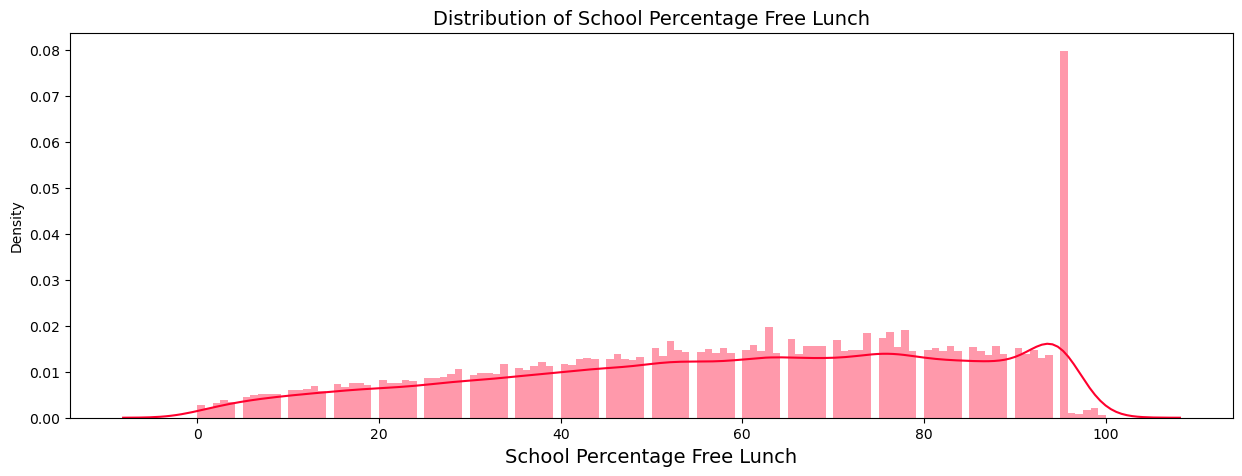

In [61]:
# extract School Types 
plt.figure(figsize=(15,5))
sns.distplot(schools_df['School Percentage Free Lunch'].dropna(), bins=120, color="#ff002e")
plt.xlabel('School Percentage Free Lunch', fontsize=14);
plt.title("Distribution of School Percentage Free Lunch", fontsize=14);
plt.show();

## <a id="5.4"> 5.4 ¿Qué tipos de escuelas están registradas en mayoría? </a>

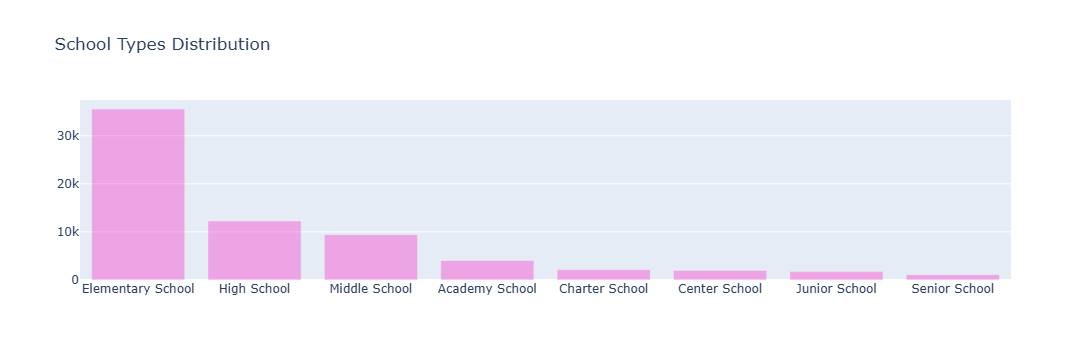

In [62]:
words = " ".join(schools_df['School Name']).split()
from collections import Counter

school_types = Counter(words).most_common(30)[1:9]
school_types = [list(x) for x in school_types]
labels = [x[0]+" School" for x in school_types]
values = [x[1] for x in school_types]

trace2 = go.Bar(
    x=labels,
    y=values,
    name='Donors to Population',
    marker=dict(color='#ff00bb'),
    opacity=0.3
)

data = [trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    title = 'School Types Distribution',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

La gran mayoría de las escuelas son primarias (con aproximadamente 35 000 alumnos), una cifra mucho mayor que la de las escuelas secundarias (aproximadamente 12 000 alumnos), las escuelas intermedias (aproximadamente 9 000 alumnos) o las academias (aproximadamente 4 000 alumnos).

## <a id="6"> 6. Exploración de recursos </a>

Los datos de recursos consisten en los elementos solicitados en diferentes proyectos, que incluyen el nombre del elemento, la cantidad de recursos, el precio unitario y el nombre del proveedor.

## <a id="6.1"> 6.1 Resumen de recursos </a>

In [66]:
resources_df = pd.read_csv("Resources.csv")
resources_df.head(5)

# len(resources_df)

,Project ID,Resource Item Name,Resource Quantity,Resource Unit Price,Resource Vendor Name
0,000009891526c0ade7180f8423792063,chair move and store cart,1.0,350.00,NaN
1,00000ce845c00cbf0686c992fc369df4,sony mdr zx100 blk headphones,40.0,12.86,CDW-G
2,00002d44003ed46b066607c5455a999a,"gaiam kids stay-n-play balance ball, grey",4.0,19.00,Amazon Business
3,00002d44003ed46b066607c5455a999a,cf520x - giant comfy pillows - set of 4,1.0,269.00,Lakeshore Learning Materials
4,00002d44003ed46b066607c5455a999a,"serta lounger, mini, sky blue",1.0,131.85,Amazon Business


A abril de 2018, los docentes habían realizado un total de 7.210.448 solicitudes de recursos en diferentes proyectos.

## <a id="6.2"> 6.2 Elementos más populares </a>

Obtengamos los elementos más populares de los datos de recursos. Los elementos más solicitados son aquellos que aparecieron en un gran número de proyectos. Los elementos solicitados en grandes cantidades representan aquellos que se solicitaron en grandes cantidades.

- 6.2.1 Elementos más solicitados de todos los tiempos
- 6.2.2 Elementos solicitados en grandes cantidades

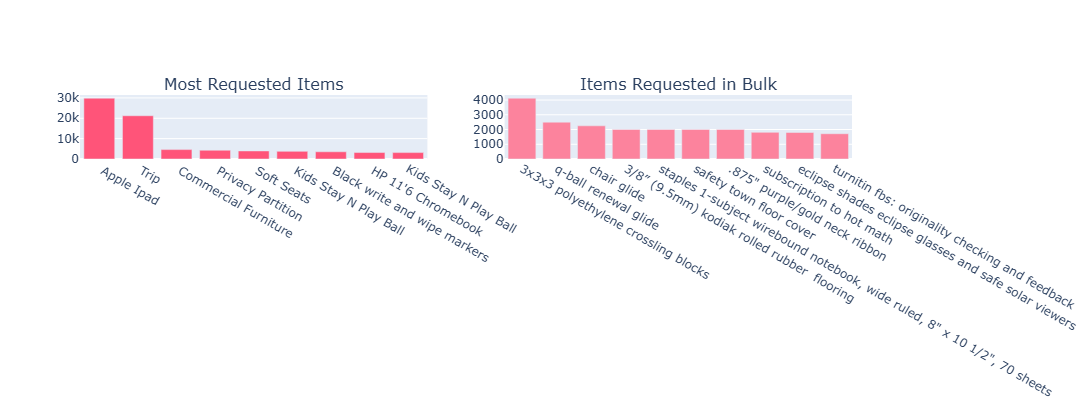

In [67]:
tdf = resources_df['Resource Item Name'].value_counts()[:15]
t = pd.DataFrame()
t['item'] = tdf.index 
t['count'] = tdf.values
t['standardized'] = list(reversed("""Kids Stay N Play Ball, Apple Ipad, HP 11'6 Chromebook, Black write and wipe markers , Kids Stay N Play Ball, Soft Seats, Privacy Partition, Apple Ipad, Commercial Furniture, Apple Ipad, Apple Ipad, Noise, Apple Ipad, Noise, Trip""".split(",")))
t1 = t.groupby('standardized').agg({'count' : 'sum'}).reset_index()
t1 = t1.sort_values('count', ascending = True)
t1 = t1[t1['standardized'] != " Noise"]
trace1 = bar_ver_noagg(list(reversed(list(t1['standardized']))), list(reversed(list(t1['count']))), "Most Requested Resource Items", "#ff5479", 400, 400, 0, rt=True)

t = resources_df.sort_values('Resource Quantity', ascending=False).head(10)
trace2 = bar_ver_noagg(t['Resource Item Name'], t['Resource Quantity'], "Most Expensive Resource Items", "#fc839d", 600, 400, 0, rt=True)

fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['Most Requested Items' , 'Items Requested in Bulk'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig['layout'].update(height=400, showlegend=False, margin=dict(b=120));
iplot(fig);

Como podemos observar, el iPad de Apple (iPad Mini, Wi-Fi, 16 o 32 GB) es el artículo más solicitado de todos los tiempos. Se solicitó en más de 30.000 proyectos. Los docentes están muy interesados ​​en utilizar la tecnología en las aulas. Las **excursiones** son otro de los artículos más solicitados, con más de 20.000 proyectos, lo que indica el interés de los docentes en llevar a los estudiantes a viajes educativos o culturales. Otros artículos populares incluyen mamparas de privacidad, mobiliario comercial y asientos acolchados.

Hay muchos artículos que se solicitan al por mayor en uno o más proyectos. Algunos ejemplos son los bloques de cruce de polietileno, los deslizadores de renovación de q-ball y los deslizadores para sillas.

## <a id="6.3"> 6.3 Artículos más caros </a>

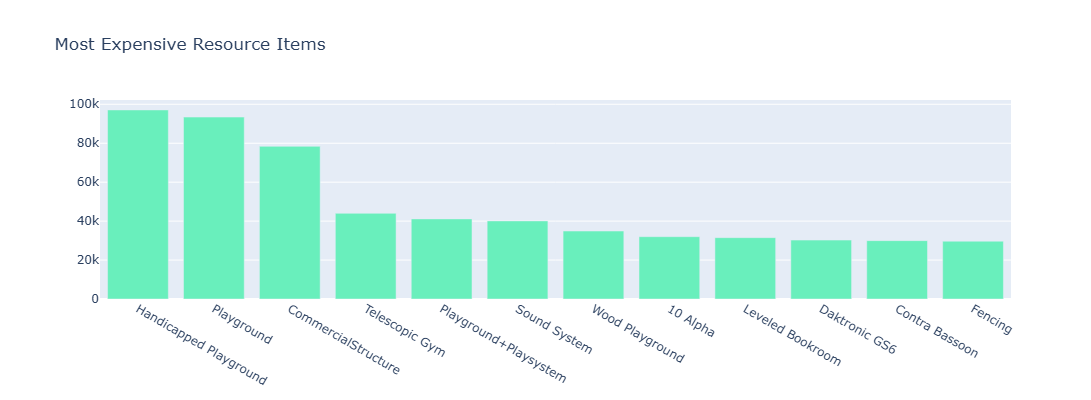

In [68]:
t = resources_df.sort_values('Resource Unit Price', ascending=False).head(15)
t1 = pd.DataFrame()
t1['item'] = t['Resource Item Name']
t1['price'] = t['Resource Unit Price']
t1['standardized'] = """Handicapped Playground,Playground,CommercialStructure,Telescopic Gym,Playground+Playsystem,Sound System,CommercialStructure,Wood Playground,Playground+Playsystem,10 Alpha,Leveled Bookroom,Daktronic GS6,Contra Bassoon,Fencing,Playground+Playsystem""".split(",")
t2 = t1.groupby('standardized').agg({'price' : 'max'}).reset_index()
t2 = t2.sort_values('price', ascending = True)
trace2 = bar_ver_noagg(list(reversed(list(t2['standardized']))), list(reversed(list(t2['price']))), "Most Expensive Resource Items", "#69efbc", 800, 400, 100)

Algunos de los recursos más caros en DonorsChoose son los **Parques infantiles, como el Parque Infantil para Discapacitados**, que cuesta casi 100.000 USD, seguidos de la **Estructura Comercial Little Tikes** y los **Gimnasios Telescópicos**.

## <a id="6.4"> 6.4 Vendedores Famosos en DonorsChoose </a>

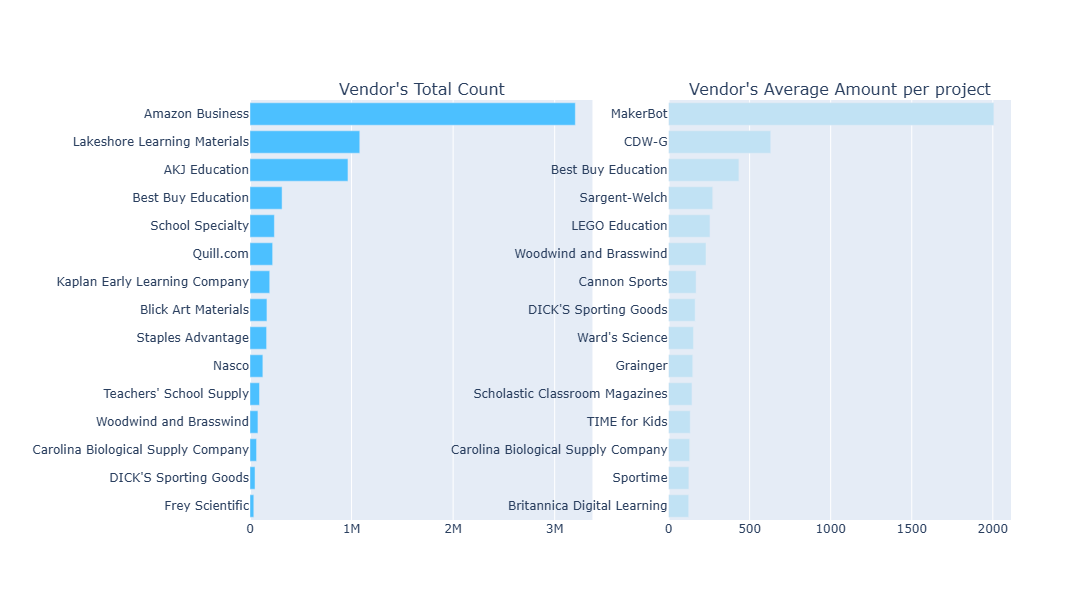

In [69]:
# most famous vendors
t = resources_df['Resource Vendor Name'].value_counts()
k = list(reversed(list(t.index)[:15]))
v = list(reversed(list(t.values)[:15]))

t = resources_df.sort_values('Resource Quantity', ascending=False).head(10)
trace2 = bar_hor_noagg(k, v, "Most Expensive Resource Items", "#4cc0ff", 800, 500, 200, rt=True)

resources_df['total_price'] = resources_df['Resource Quantity'] * resources_df['Resource Unit Price']

# to which vendor has most money went 
# tempdf = resources_df.groupby('Resource Vendor Name').agg({'total_price' : 'sum'}).reset_index()
# tempdf = tempdf.sort_values('total_price', ascending = False)[:10]
# trace1 = bar_hor_noagg(list(reversed(list(tempdf['Resource Vendor Name']))), list(reversed(list(tempdf['total_price']))), "", "#8dd0f4", 600, 400, 200, rt=True)

# average price received by which vendors 
tempdf = resources_df.groupby('Resource Vendor Name').agg({'total_price' : 'mean'}).reset_index()
tempdf = tempdf.sort_values('total_price', ascending = False)[:15]
trace1 = bar_hor_noagg(list(reversed(list(tempdf['Resource Vendor Name']))), list(reversed(list(tempdf['total_price']))), "", "#c1e2f4", 800, 400, 200, rt=True)

fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["Vendor's Total Count" , "Vendor's Average Amount per project"])
fig.append_trace(trace2, 1, 1);
fig.append_trace(trace1, 1, 2);
fig['layout'].update(height=600, showlegend=False, margin=dict(l=250));
iplot(fig);

La mayoría de los recursos se solicitan a **Amazon Business**, con 3,2 millones de solicitudes de artículos de Amazon. Le siguen Lakeshore Learning Materials y AKJ Education.

Al comparar el costo promedio de los proveedores, **MarkerBot** se destaca con un costo promedio por proyecto de **USD 2000**.

**Best Buy Education** es otro proveedor popular entre los docentes y también tiene un precio promedio por proyecto significativamente más alto.

<br>

## <a id="7"> 7. Exploración de proyectos </a>

Los datos de los proyectos incluyen todos los detalles sobre los proyectos publicados, como el ID del docente y la escuela, el título, el tipo, la categoría, el costo, etc. Veamos un resumen.

## <a id="7.1"> 7.1 Resumen de proyectos </a>

In [82]:
projects_df = pd.read_csv("Projects.csv")
projects_df.head(3)

,Project ID,School ID,Teacher ID,Teacher Project Posted Sequence,Project Type,Project Title,Project Essay,Project Short Description,Project Need Statement,Project Subject Category Tree,Project Subject Subcategory Tree,Project Grade Level Category,Project Resource Category,Project Cost,Project Posted Date,Project Expiration Date,Project Current Status,Project Fully Funded Date
0,7685f0265a19d7b52a470ee4bac883ba,e180c7424cb9c68cb49f141b092a988f,4ee5200e89d9e2998ec8baad8a3c5968,25,Teacher-Led,Stand Up to Bullying: Together We Can!,Did you know that 1-7 students in grades K-12 ...,Did you know that 1-7 students in grades K-12 ...,"My students need 25 copies of ""Bullying in Sch...",Applied Learning,"Character Education, Early Development",Grades PreK-2,Technology,361.80,2013-01-01,2013-05-30,Fully Funded,2013-01-11
1,f9f4af7099061fb4bf44642a03e5c331,08b20f1e2125103ed7aa17e8d76c71d4,cca2d1d277fb4adb50147b49cdc3b156,3,Teacher-Led,Learning in Color!,"Help us have a fun, interactive listening cent...","Help us have a fun, interactive listening cent...","My students need a listening center, read alon...","Applied Learning, Literacy & Language","Early Development, Literacy",Grades PreK-2,Technology,512.85,2013-01-01,2013-05-31,Expired,NaN
2,afd99a01739ad5557b51b1ba0174e832,1287f5128b1f36bf8434e5705a7cc04d,6c5bd0d4f20547a001628aefd71de89e,1,Teacher-Led,Help Second Grade ESL Students Develop Languag...,Visiting or moving to a new place can be very ...,Visiting or moving to a new place can be very ...,My students need beginning vocabulary audio ca...,Literacy & Language,ESL,Grades PreK-2,Supplies,435.92,2013-01-01,2013-05-30,Fully Funded,2013-05-22


## <a id="7.2"> 7.2 ¿Cuáles son las categorías, subcategorías y categorías de recursos más frecuentes para los proyectos publicados? </a>

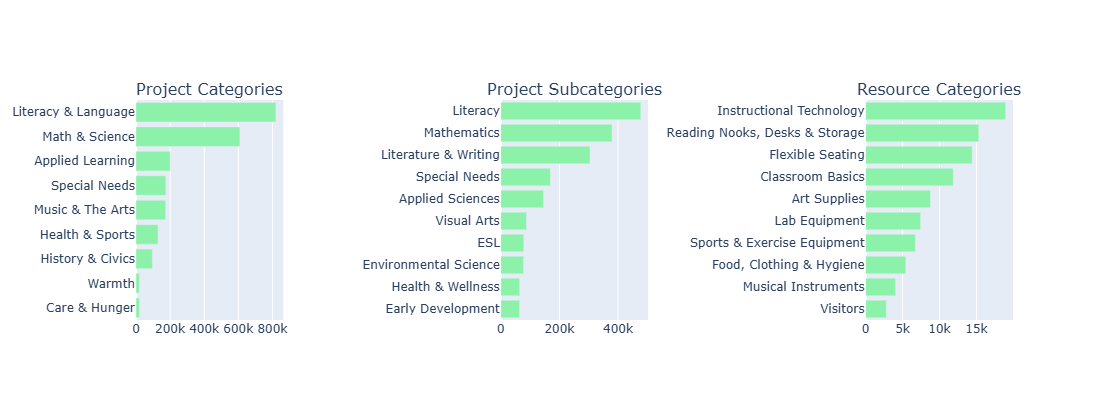

In [83]:
# Create some date time features 
projects_df['Posted Date'] = pd.to_datetime(projects_df['Project Posted Date'])

projects_df['Posted Year'] = projects_df['Posted Date'].dt.year
projects_df['Posted Month'] = projects_df['Posted Date'].dt.month
projects_df['Posted Day'] = projects_df['Posted Date'].dt.weekday
projects_df['Posted Quarter'] = projects_df['Posted Date'].dt.quarter

projects_df['Funded Date'] = pd.to_datetime(projects_df['Project Fully Funded Date'])
projects_df['Funded Year'] = projects_df['Funded Date'].dt.year
projects_df['Funded Month'] = projects_df['Funded Date'].dt.month
projects_df['Funded Day'] = projects_df['Funded Date'].dt.weekday
projects_df['Funded Quarter'] = projects_df['Funded Date'].dt.quarter
projects_df['Funding Time'] = projects_df['Funded Date'] - projects_df['Posted Date']



t = projects_df['Project Subject Category Tree'].value_counts()
x = list(t.index)
y = list(t.values)
r = {}
for i,val in enumerate(x):
    for each in val.split(","):
        x1 = each.strip()
        if x1 not in r:
            r[x1] = y[i]
        r[x1] += y[i]
sorted_x = list(sorted(r.items(), key=operator.itemgetter(1), reverse = True))[:10]
x1 = [a[0] for a in sorted_x][::-1]
y1 = [a[1] for a in sorted_x][::-1]



t1 = projects_df['Project Subject Subcategory Tree'].value_counts()
x2 = list(t1.index)
y2 = list(t1.values)
r = {}
for i,val in enumerate(x2):
    for each in val.split(","):
        x1_ = each.strip()
        if x1_ not in r:
            r[x1_] = y2[i]
        r[x1_] += y2[i]        
x2 = r.keys()
y2 = r.values()
sorted_x = list(sorted(r.items(), key=operator.itemgetter(1), reverse = True))[:10]
x2 = [a[0] for a in sorted_x][::-1]
y2 = [a[1] for a in sorted_x][::-1]

t = projects_df['Project Resource Category'].value_counts()
x3 = list(t.index[::-1])[:10]
y3 = list(t.values[::-1])[:10]


trace1 = bar_hor_noagg(x1, y1, "", "#8cf2a9", 600, 400, 10, rt=True)
trace2 = bar_hor_noagg(x2, y2, "", "#8cf2a9", 600, 400, 10, rt=True)
trace3 = bar_hor_noagg(x3, y3, "", "#8cf2a9", 600, 400, 10, rt=True)

fig = tools.make_subplots(rows=1, cols=5, print_grid=False, subplot_titles = ['Project Categories' ,"", 'Project Subcategories', '', "Resource Categories"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 3);
fig.append_trace(trace3, 1, 5);
fig['layout'].update(height=400, showlegend=False, margin=dict(l=120));
iplot(fig);

> Una gran mayoría de proyectos (más de 800K) pertenecen a la categoría principal de **Alfabetización y Lenguaje**. **Matemáticas y Ciencias** es la segunda categoría más conocida. Comparativamente, se han publicado menos proyectos sobre Cuidado y Hambre desde 2013.  
> Entre las subcategorías, Alfabetización, Matemáticas y Escritura son las subcategorías más comunes de los proyectos publicados por los maestros, mientras que un número menor de proyectos se publica en la categoría de Desarrollo Temprano y Salud.  
> **Tecnología Educativa, Rincones de Lectura, Escritorios y Almacenamiento** son las categorías clave de recursos solicitados por los maestros.  

## <a id="7.3"> 7.3 ¿Cuál es la distribución por Tipo de Proyecto y Estado Actual del Proyecto? </a>

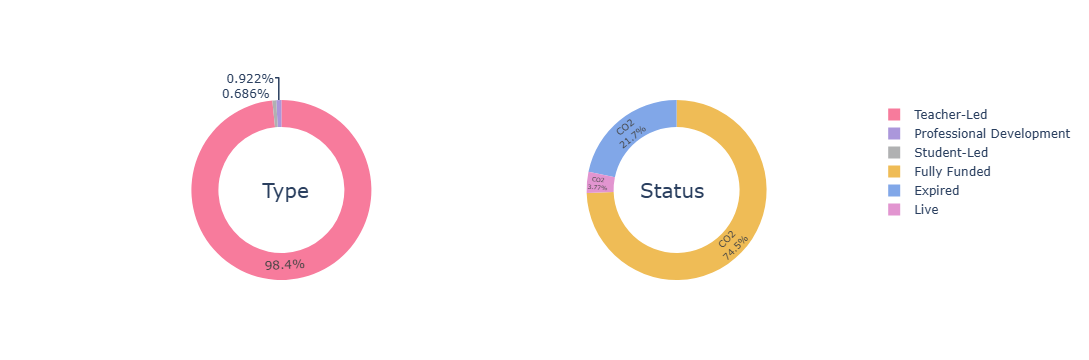

In [85]:
t = projects_df['Project Type'].value_counts()
values1 = t.values 
index1 = t.index
t = projects_df['Project Current Status'].value_counts()
values2 = t.values 
index2 = t.index


domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}


fig = {
  "data": [
    {
      "values": values1,
      "labels": index1,
      "domain": {"x": [0, .48]},
    "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2']),
      "name": "Project Type",
      "hoverinfo":"label+percent+name",
      "hole": .7,
        
      "type": "pie"
    },
    {
  "values": values2,
  "labels": index2,
  "marker": dict(colors=[ "#efbc56", "#81a7e8", "#e295d0"]),
  "domain": {"x": [.52, 1]},
  "text": ["CO2"] * len(values2),   
  "textposition": "inside",
  "name": "Project Status",
  "hole": .7,
  "type": "pie"
}
],
  "layout": {
#         "title":"Project Type and Project Status",
      "annotations": [
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Type",
                "x": 0.21,
                "y": 0.5
            },
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Status",
                "x": 0.8,
                "y": 0.5
            }
        ]
    
    }
}
iplot(fig, filename='donut')

Además de los proyectos predominantes liderados por docentes, un número significativamente menor de proyectos también son publicados por estudiantes o servicios de desarrollo profesional. Los datos muestran que aproximadamente el 75% de todos los proyectos publicados han sido financiados en su totalidad, mientras que el 21% han caducado. A mayo de 2018, había alrededor de 42.000 proyectos activos en DonorsChoose.

## <a id="7.4"> 7.4 ¿En qué días se publicaron y financiaron la mayor cantidad de proyectos? </a>

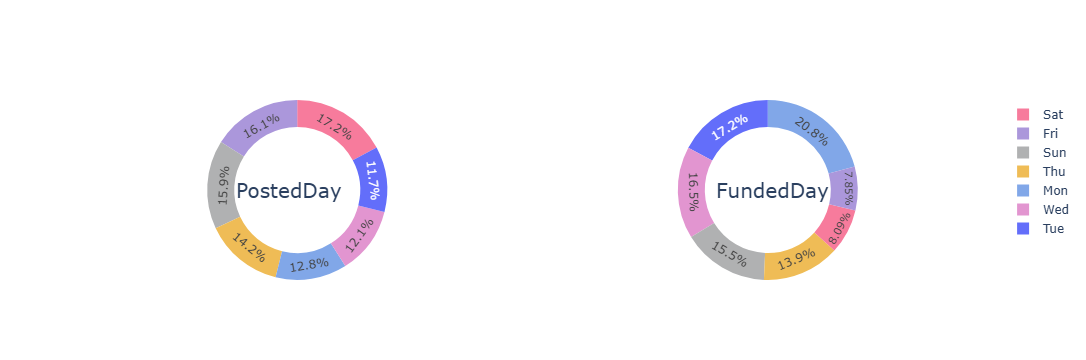

In [87]:
t1 = projects_df['Posted Day'].value_counts()
t2 = projects_df['Funded Day'].value_counts()

mapp = {0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'}
values1 = t1.values 
index1 = t1.index
index1 = [mapp[x] for x in index1]

values2 = t2.values 
index2 = t2.index
index2 = [mapp[x] for x in index2]
tmap = {}
for j, b in enumerate(index2):
    tmap[b] = values2[j]
# print (tmap)
# print index1
values2_c = [tmap[c] for c in index1]
# print values2_c
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}


fig = {
  "data": [
    {
      "values": values1,
      "labels": index1,
      "domain": {"x": [0, .48]},
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "name": "PostedDay",
      "hoverinfo":"label+percent+name",
      "hole": .7,
#             "textinfo" : "text",
      "type": "pie"
    },
    {
      "values": values2_c,
      "labels": index1,
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "domain": {"x": [.52, 1]},
#         "text":"CO2",
      "textposition":"inside",
      "name": "FundedDay",
#         "text" : values2,
#         "textinfo" : "text",
        "hole" : .7,
      "type": "pie"
    }],
  "layout": {
#         "title":"Project Type and Project Status",
      "annotations": [
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "PostedDay",
                "x": 0.17,
                "y": 0.5
            },
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "FundedDay",
                "x": 0.83,
                "y": 0.5
            }
        ]
    
    }
}
iplot(fig, filename='donut')

Los profesores generalmente publican sus proyectos al final de la semana: viernes (16%), sábado (16%) y domingo (17%). Los lunes se financia y cierra el mayor número de proyectos.

## <a id="7.5"> 7.5 Trimestres en los que se publican y financian los proyectos </a>

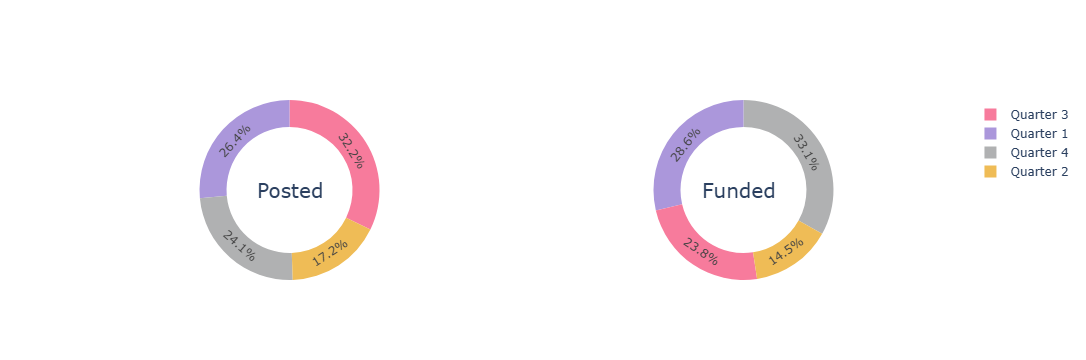

In [88]:
t1 = projects_df['Posted Quarter'].value_counts()
t2 = projects_df['Funded Quarter'].value_counts()

mappq = {1.0:'Quarter 1',2.0:'Quarter 2',3.0:'Quarter 3',4.0:'Quarter 4'}
values1 = t1.values 
index1 = t1.index
index1 = [mappq[x] for x in index1]

values2 = t2.values 
index2 = t2.index
index2 = [mappq[x] for x in index2]
tmap = {}
for j, b in enumerate(index2):
    tmap[b] = values2[j]
# print (tmap)
# print index1
values2_c = [tmap[c] for c in index1]
# print values2_c
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}


fig = {
  "data": [
    {
      "values": values1,
      "labels": index1,
      "domain": {"x": [0, .48]},
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "name": "PostedDay",
#       "hoverinfo":"label+percent+name",
      "hole": .7,
#             "textinfo" : "text",
      "type": "pie"
    },
    {
      "values": values2_c,
      "labels": index1,
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "domain": {"x": [.52, 1]},
#         "text":"CO2",
      "textposition":"inside",
      "name": "FundedDay",
#         "text" : values2,
#         "textinfo" : "text",
        "hole" : .7,
      "type": "pie"
    }],
  "layout": {
#         "title":"Project Type and Project Status",
      "annotations": [
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Posted",
                "x": 0.2,
                "y": 0.5
            },
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Funded",
                "x": 0.8,
                "y": 0.5
            }
        ]
    
    }
}
iplot(fig, filename='donut')




El tercer trimestre (julio, agosto y septiembre) es el periodo en el que los profesores han publicado el mayor número de proyectos, al igual que el trimestre siguiente (cuarto trimestre), cuando la mayoría de los proyectos ya han sido financiados y finalizados.

## <a id="7.6"> 7.6 Meses en los que se publicaron los proyectos </a>

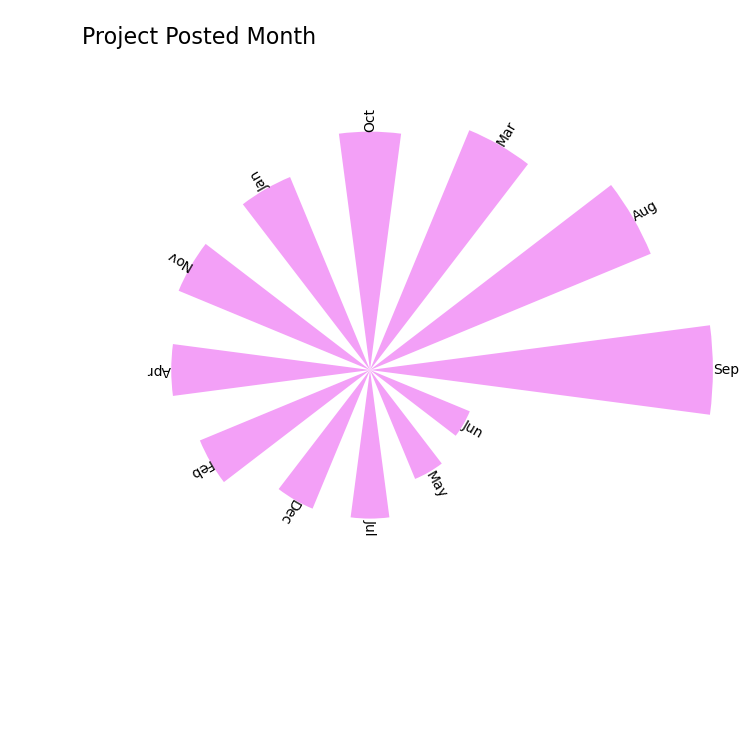

In [89]:
t = projects_df['Posted Month'].value_counts()


lObjectsALLcnts = list(t.values)

lObjectsALLlbls = list(t.index)
mapp1 = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
lObjectsALLlbls = [mapp1[x] for x in lObjectsALLlbls]

iN = len(lObjectsALLcnts)
arrCnts = np.array(lObjectsALLcnts)

theta=np.arange(0, 2*np.pi, 2*np.pi/iN)
width = (2*np.pi)/iN *0.5
bottom = 50

fig = plt.figure(figsize=(8,8))
ax = fig.add_axes([0.2, 0.1, 1, 0.9], polar=True)
fig.suptitle('Project Posted Month   ', fontsize=16)
bars = ax.bar(theta, arrCnts, width=width, bottom=bottom, color='#f3a0f7')
plt.axis('off')

rotations = np.rad2deg(theta)
for x, bar, rotation, label in zip(theta, bars, rotations, lObjectsALLlbls):
    lab = ax.text(x,bottom+bar.get_height() , label, ha='left', va='center', rotation=rotation, rotation_mode="anchor",)   
plt.show()


En el tercer trimestre, el mayor número de proyectos se publicó en septiembre, seguido de agosto. El menor número de proyectos se publicó en junio.

## <a id="7.7"> 7.7 Año en que se publicaron los proyectos </a>

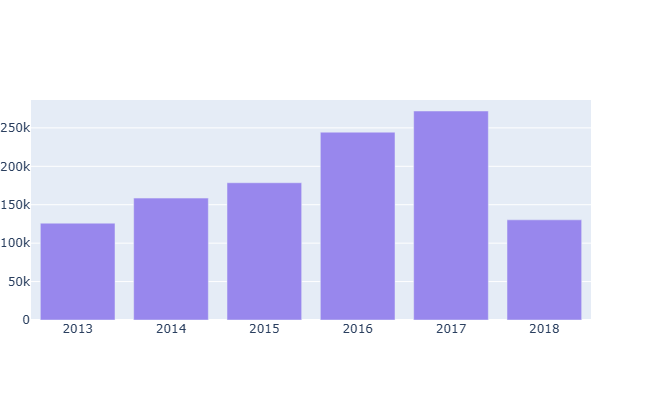

In [90]:
t = projects_df.groupby('Posted Year').agg({'Posted Month' : 'count'}).reset_index()
t = t.sort_values('Posted Year')
trace2 = bar_ver_noagg(t['Posted Year'], t['Posted Month'], "", "#9887ed", None, 400, 0)


El número de proyectos en DonorsChoose ha aumentado constantemente durante los últimos 5 años. En 2017 se publicaron alrededor de 300 000 proyectos.

## <a id="7.8"> 7.8 ¿En qué año y mes el costo del proyecto es mayor? </a>

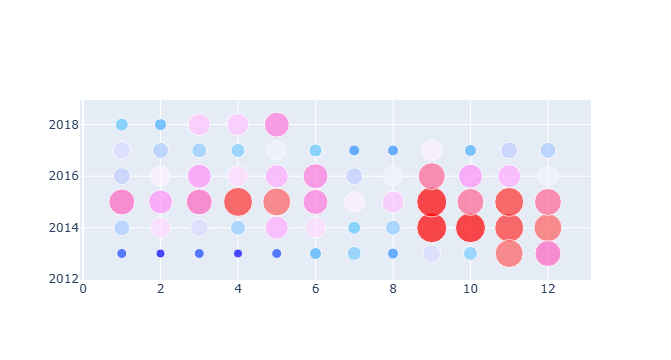

In [91]:
year_tab = pd.crosstab(projects_df["Project Current Status"], projects_df["Posted Year"]).reset_index()
from itertools import zip_longest
projects_df['cost'] = projects_df['Project Cost'].apply(lambda x : float(str(x).replace(",","").replace("$","")))

def cbp(df, col1, col2, aggcol, func, title, cs, bottom_margin=None):
    tempdf = df.groupby([col1, col2]).agg({aggcol : func}).reset_index()
    tempdf[aggcol] = tempdf[aggcol].apply(lambda x : int(x))
    tempdf = tempdf.sort_values(aggcol, ascending=False)

    sizes = list(reversed([i for i in range(10,31)]))
    intervals = int(len(tempdf) / len(sizes))
    size_array = [9]*len(tempdf)
    
    st = 0
    for i, size in enumerate(sizes):
        for j in range(st, st+intervals):
            size_array[j] = size 
        st = st+intervals
    tempdf['size_n'] = size_array
    # tempdf = tempdf.sample(frac=1).reset_index(drop=True)

    cols = list(tempdf['size_n'])

    trace1 = go.Scatter( x=tempdf[col1], y=tempdf[col2], mode='markers', text=tempdf[aggcol],
        marker=dict( size=tempdf.size_n, color=cols, colorscale=cs ))
    data = [trace1]
    if bottom_margin:
        layout = go.Layout(title=title, margin=dict(b=150))
    else:
        layout = go.Layout(title=title)
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

cbp(projects_df, 'Posted Month', 'Posted Year', 'cost', 'mean', '', 'Picnic')



En septiembre de 2014 se publicó un gran número de proyectos con un costo promedio elevado. En 2015, los meses de abril, mayo, septiembre y octubre fueron los que presentaron los proyectos con mayor costo.

## <a id="7.9"> 7.9 ¿En qué año y categoría de grado es más alto el costo del proyecto? </a>

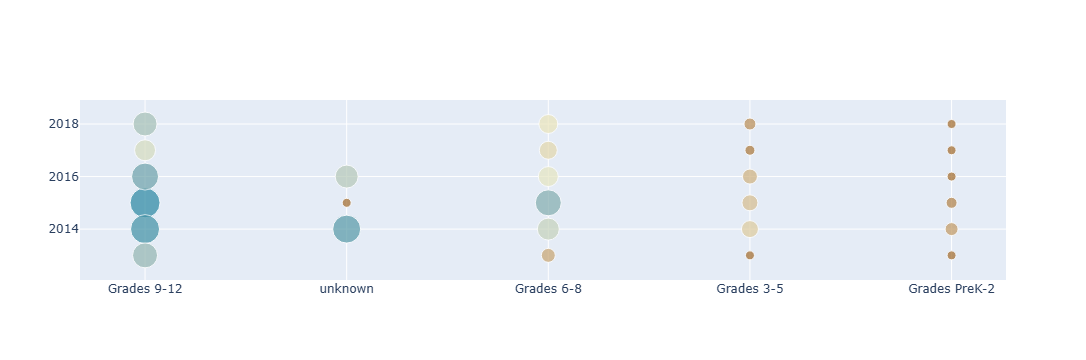

In [92]:
cbp(projects_df, 'Project Grade Level Category', 'Posted Year', 'cost', 'mean', '', 'Earth')

Para los grados 6-8 y 9-12, los proyectos con mayores costos correspondieron al año 2015; para los grados 3-5 y Preescolar-2, al año 2014.

## <a id="7.10"> 7.10 Categorías de grados y categorías de recursos con los costos de proyecto más altos </a>

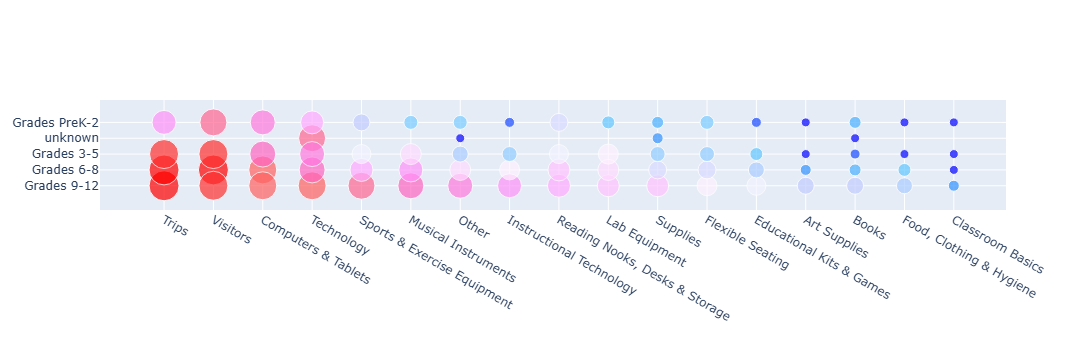

In [93]:
cbp(projects_df, 'Project Resource Category', 'Project Grade Level Category', 'cost', 'mean', '', 'Picnic', bottom_margin=150)

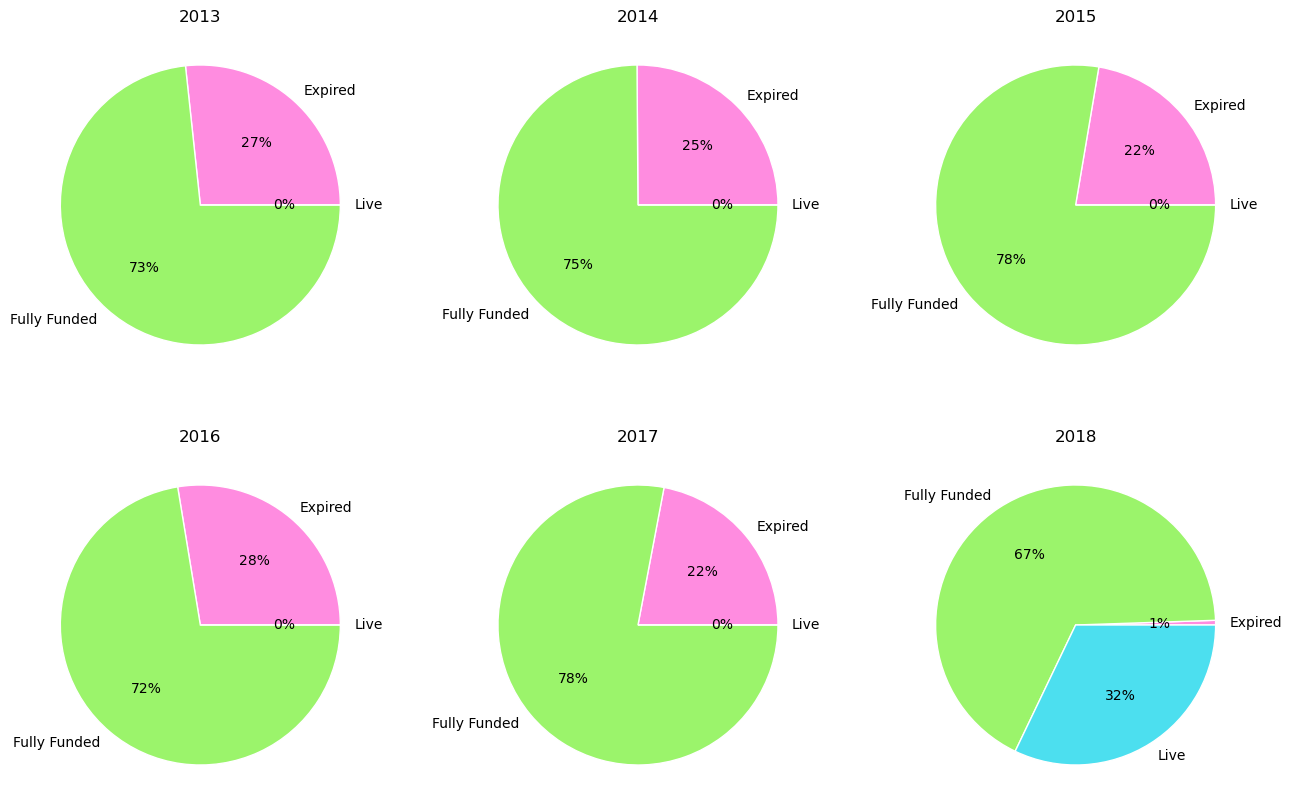

In [94]:
years = [2013, 2014, 2015, 2016, 2017, 2018]
plt.figure(figsize=(16,10))
for i,j in zip_longest(years, range(len(years))):
    plt.subplot(2, 3, j+1)
    plt.pie(year_tab[i],
            labels=year_tab["Project Current Status"].tolist(),
            autopct="%1.0f%%", 
            colors=["#ff8ce0", "#9bf46b", "#4cdfef"],
            wedgeprops={"linewidth":1,"edgecolor":"white"})
    plt.title(i)

Un análisis anual de los datos muestra que **aproximadamente el 70% del total de proyectos** publicados en DonorsChoose en un año reciben financiación completa. Se ha observado una tendencia creciente en el porcentaje de proyectos con financiación completa por año, **excepto en 2016**, cuando el número de proyectos con financiación completa disminuyó un 6% con respecto al año anterior. 2017 y 2015 fueron los mejores años en cuanto a la proporción de proyectos con financiación completa, con aproximadamente el **78% de los proyectos** consiguiendo financiación completa.

## <a id="7.12"> 7.12 ¿Cuántos días permanecieron activos los proyectos? </a>

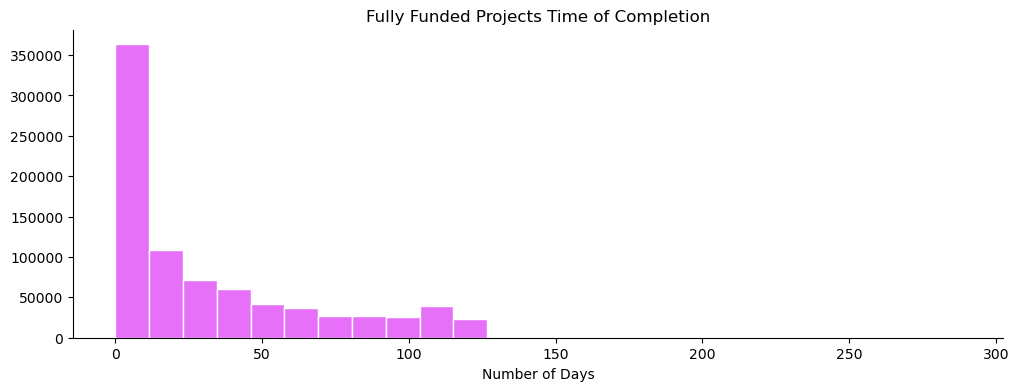

In [95]:
t = projects_df[projects_df['Project Current Status'] == "Fully Funded"]
t['Funding Time'] = t['Funding Time'].apply(lambda x : int(str(x).split()[0]))

plt.figure(figsize=(12,4));
ax = t['Funding Time'].hist(bins=25, edgecolor='white', color="#e770f9")
ax.grid(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
plt.xlabel('Number of Days');
plt.title('Fully Funded Projects Time of Completion');

Un mayor número de proyectos se completaron en menos de 3 días. Aproximadamente <b>"55000 proyectos"</b> se financiaron con éxito en un solo día, mientras que alrededor de <b>"48627 proyectos"</b> se cerraron el mismo día de su publicación. El proyecto con mayor duración fue de 288 días, titulado "**Vacy Bowls, Full Hearts**". Este proyecto tuvo un costo estimado de USD 1982 y fue publicado por la **Escuela Primaria Harrison Park** en Michigan.

## <a id="7.13"> 7.13 ¿Cómo varía la proporción de proyectos financiados frente a los no financiados según el estado? </a>

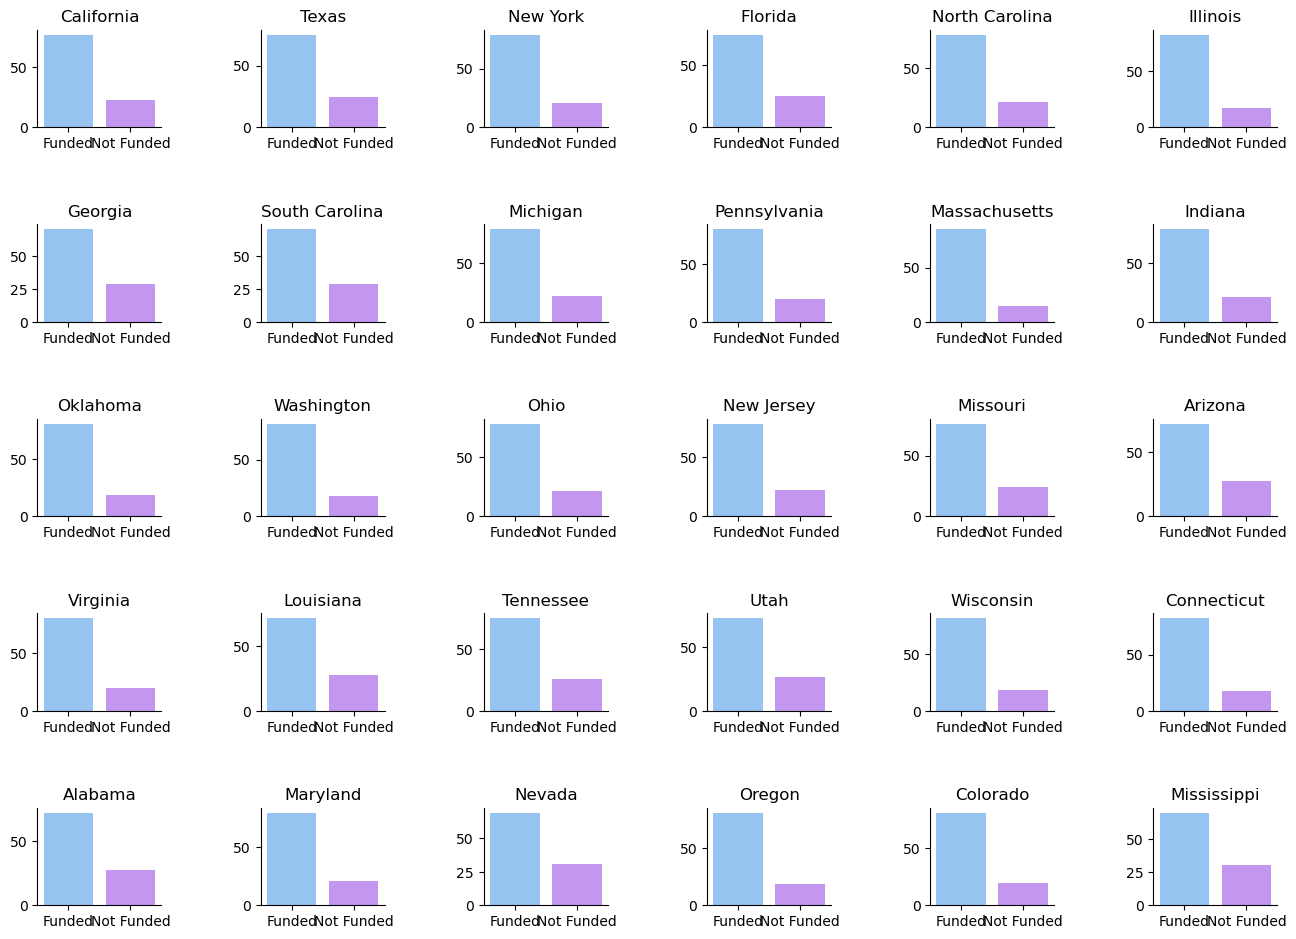

In [97]:
projsch_df = projects_df.merge(schools_df, on="School ID")
states = [u'California', u'Texas', u'New York', u'Florida', u'North Carolina',
       u'Illinois', u'Georgia', u'South Carolina', u'Michigan',
       u'Pennsylvania', u'Massachusetts', u'Indiana', u'Oklahoma',
       u'Washington', u'Ohio', u'New Jersey', u'Missouri', u'Arizona',
       u'Virginia', u'Louisiana', u'Tennessee', u'Utah', u'Wisconsin',
       u'Connecticut', u'Alabama', u'Maryland', u'Nevada', u'Oregon',
       u'Colorado', u'Mississippi', u'Minnesota', u'Kentucky', u'Arkansas',
       u'Hawaii', u'Idaho', u'Maine', u'Kansas', u'Iowa',
        u'New Mexico', u'West Virginia', u'Alaska',
       u'New Hampshire', u'Delaware', u'Rhode Island', u'Nebraska',
       u'South Dakota', u'Montana', u'North Dakota', u'Vermont', u'Wyoming'][:30]
import itertools 

length = len(states)
plt.figure(figsize=(16,24))
for i,j in itertools.zip_longest(states, range(length)):
    plt.subplot(10, 6, j+1)
    
    t = dict(projsch_df[projsch_df['School State'] == i]['Project Current Status'].value_counts())

    ### this is changed in the new verson
    t['Not Funded'] = t['Expired']
    t['Total'] = t['Fully Funded'] + t['Not Funded']
    t1 = {'Funded' : float(t['Fully Funded']) * 100 / t['Total'], 'Not Funded' : float(t['Not Funded']) * 100 / t['Total']}

    ax = sns.barplot(x=list(t1.keys()), y=list(t1.values()), alpha=.7, palette='cool')

    ax.grid(False)
#     plt.yticks(np.arange(0,100,10))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.subplots_adjust(wspace =.8,hspace = 1)
    plt.title(i, color="black")

Algunos de los estados donde el porcentaje de proyectos vencidos o sin financiación es menor son Georgia, Carolina del Sur y Misisipi.

## <a id="7.14"> 7.14 ¿Cuál es el costo promedio de los proyectos según el tipo de área metropolitana escolar y la categoría de recursos solicitados? </a>

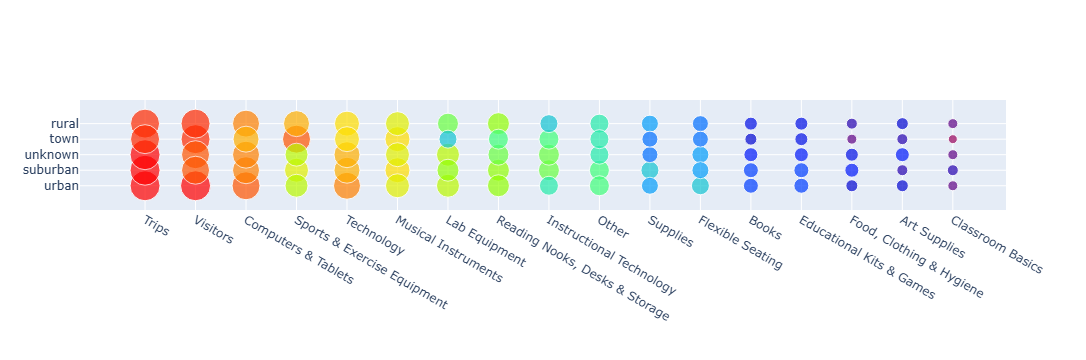

In [98]:
cbp(projsch_df, 'Project Resource Category', 'School Metro Type', 'cost', 'mean', '', 'Rainbow', bottom_margin = 150)

Los viajes y las visitas siempre representan las categorías más costosas entre todos los tipos de Metro Escolar. La categoría "Pueblos" presenta el costo promedio más alto para los proyectos que requieren recursos relacionados con equipos deportivos y de ejercicio.

## <a id="7.15"> 7.15 ¿Cuál es el costo promedio de los proyectos según el tipo de Metro Escolar y el nivel educativo? </a>

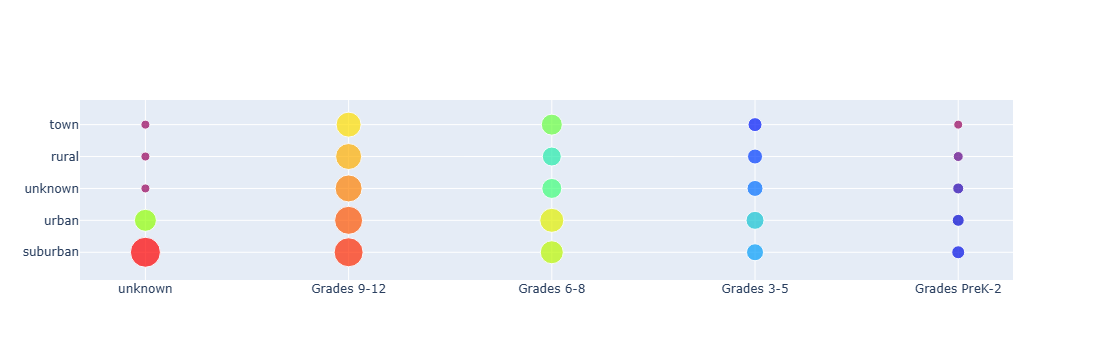

In [99]:
cbp(projsch_df, 'Project Grade Level Category', 'School Metro Type', 'cost', 'mean', '', 'Rainbow')

Los grados 9 a 12 presentan el costo promedio más alto para los proyectos en comparación con cualquier otro nivel educativo. Entre ellos, los proyectos en áreas metropolitanas suburbanas tienen los precios más elevados, mientras que los de las ciudades presentan los más bajos.

## <a id="8">8. Procesamiento del Lenguaje Natural para la Elaboración de Perfiles de Proyectos</a>

Se puede obtener mucha información valiosa mediante el análisis de texto de los ensayos de proyectos. Realicemos un análisis de texto básico/procesamiento del lenguaje natural para extraer la información relevante de los ensayos. Para ello, me centraré en un subconjunto de proyectos recientes de abril de 2018.

## <a id="8.1">8.1 Limpieza de Texto</a>

Escriba una función de utilidad que normalice el texto y elimine el ruido. Esta función de limpieza de texto elimina las palabras vacías y los signos de puntuación.

In [101]:
!pip install textblob


   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 4.2 MB/s  0:00:00


In [103]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\josea\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [108]:
print(projects_df.columns)
print(schools_df.columns)


Index(['Project ID', 'School ID', 'Teacher ID',
       'Teacher Project Posted Sequence', 'Project Type', 'Project Title',
       'Project Essay', 'Project Short Description', 'Project Need Statement',
       'Project Subject Category Tree', 'Project Subject Subcategory Tree',
       'Project Grade Level Category', 'Project Resource Category',
       'Project Cost', 'Project Posted Date', 'Project Expiration Date',
       'Project Current Status', 'Project Fully Funded Date', 'Posted Date',
       'Posted Year', 'Posted Month', 'Posted Day', 'Posted Quarter',
       'Funded Date', 'Funded Year', 'Funded Month', 'Funded Day',
       'Funded Quarter', 'Funding Time', 'cost', 'School Name_x',
       'School Metro Type_x', 'School Percentage Free Lunch_x',
       'School State_x', 'School Zip_x', 'School City_x', 'School County_x',
       'School District_x', 'School Name_y', 'School Metro Type_y',
       'School Percentage Free Lunch_y', 'School State_y', 'School Zip_y',
       'School Ci

In [109]:
from nltk.corpus import stopwords 
from textblob import TextBlob
import string 

stopwords = stopwords.words("english")

def _clean(txt):
    # lower case
    txt = txt.lower()

    # punctuation removal 
    txt = ''.join(x for x in txt if x not in string.punctuation)

    # stopwords and lemmatization
    clean_txt = ""
    for word in txt.split():
        if word in stopwords:
            continue 
        clean_txt += " "
        clean_txt += word 
    
    noise = ['students','my','title', 'would', 'every', 'will', 'many','also','donotremoveessaydivider']
    for ns in noise:
        clean_txt = clean_txt.replace(ns, "")

    return clean_txt

# Carga limpia de los DataFrames originales
projects_df = pd.read_csv("Projects.csv")
schools_df = pd.read_csv("Schools.csv")

# Une solo una vez, evitando duplicados
projects_df = projects_df.merge(
    schools_df[['School ID','School Name','School Metro Type',
                'School Percentage Free Lunch','School State',
                'School Zip','School City','School County','School District']],
    on="School ID",
    how="inner"
)

# Ahora projects_df ya tiene toda la información de escuelas sin columnas duplicadas
print(projects_df.columns)


Index(['Project ID', 'School ID', 'Teacher ID',
       'Teacher Project Posted Sequence', 'Project Type', 'Project Title',
       'Project Essay', 'Project Short Description', 'Project Need Statement',
       'Project Subject Category Tree', 'Project Subject Subcategory Tree',
       'Project Grade Level Category', 'Project Resource Category',
       'Project Cost', 'Project Posted Date', 'Project Expiration Date',
       'Project Current Status', 'Project Fully Funded Date', 'School Name',
       'School Metro Type', 'School Percentage Free Lunch', 'School State',
       'School Zip', 'School City', 'School County', 'School District'],
      dtype='object')


## <a id="8.2"> 8.2 Bag of Words Analysis </a> 

## <a id="8.2.1"> 8.2.1 What are the top  words and phrases used by Teachers in Essays </a> 

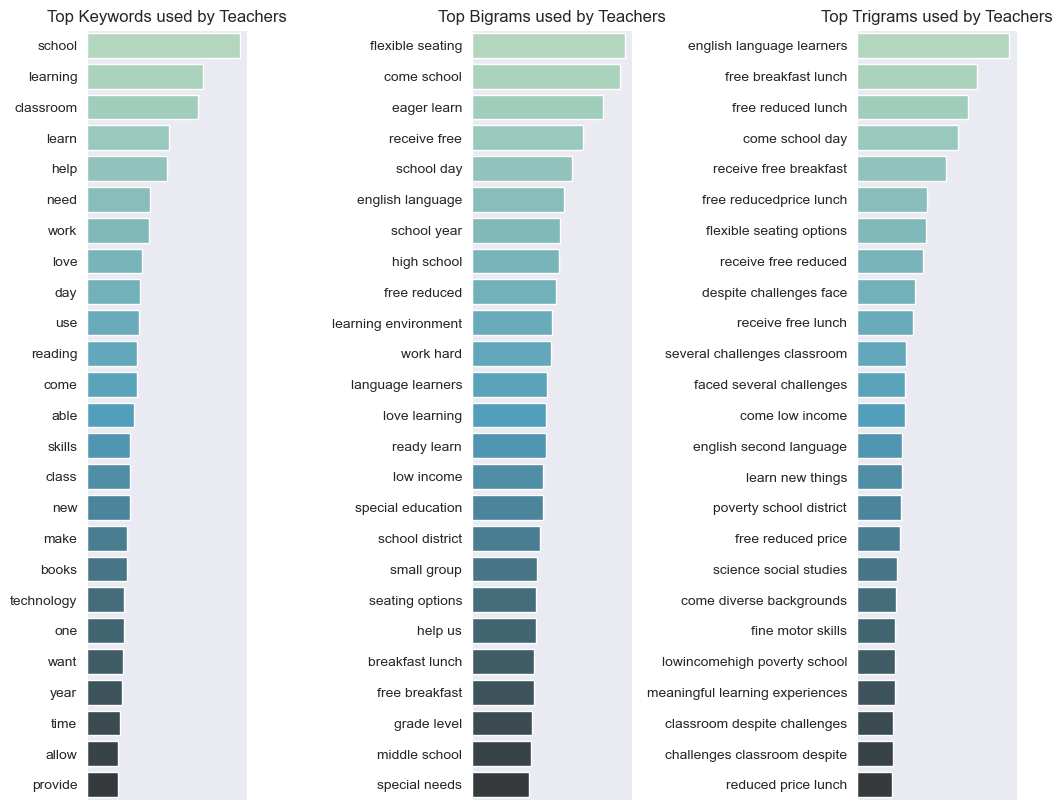

In [110]:
### Bag of Words 
from collections import Counter
def generate_ngrams(txt, N):
    grams = [txt[i:i+N] for i in range(len(txt)-N+1)]
    grams = [" ".join(b) for b in grams]
    return grams 

april18_df['unigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 1))
april18_df['bigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 2))
april18_df['trigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 3))

all_unigrams = []
for each in april18_df['unigrams']:
    all_unigrams.extend(each)
t = Counter(all_unigrams).most_common(25)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df['bigrams']:
    all_bigrams.extend(each)
t1 = Counter(all_bigrams).most_common(25)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]


all_trigrams = []
for each in april18_df['trigrams']:
    all_trigrams.extend(each)
t2 = Counter(all_trigrams).most_common(25)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,10));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top Keywords used by Teachers");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top Bigrams used by Teachers");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top Trigrams used by Teachers");

Las palabras clave más utilizadas en todos los ensayos, estados y tipos de escuelas son «escuela», «aprendizaje», «aula» y «lectura». Los bigramas se centran principalmente en «asientos flexibles» y «idioma inglés». Un gran número de ensayos de profesores tratan sobre «desayuno y almuerzo gratuitos», «aprendizaje del idioma inglés» y «varios desafíos».

## 8.2.2 ¿Cómo varían las frases más utilizadas según el estado?

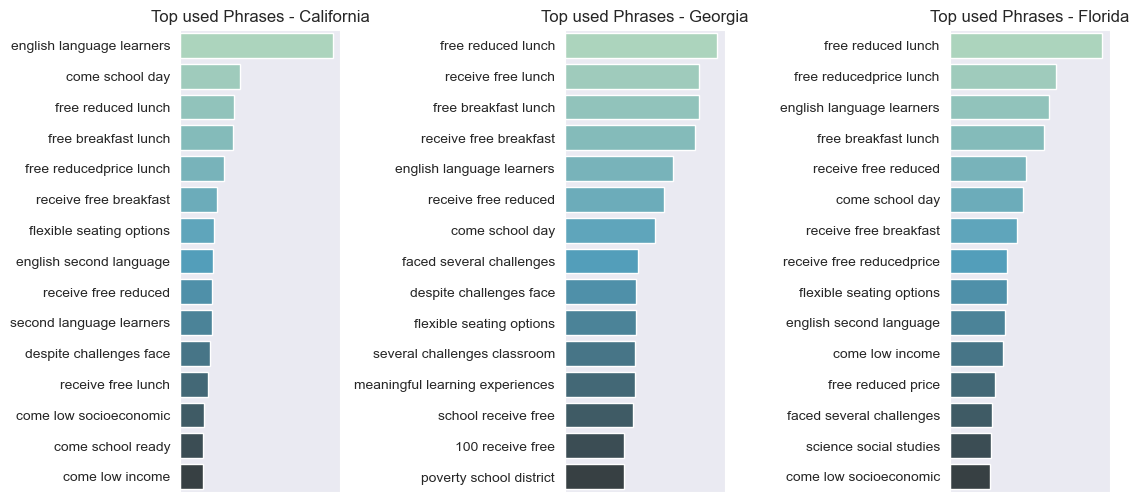

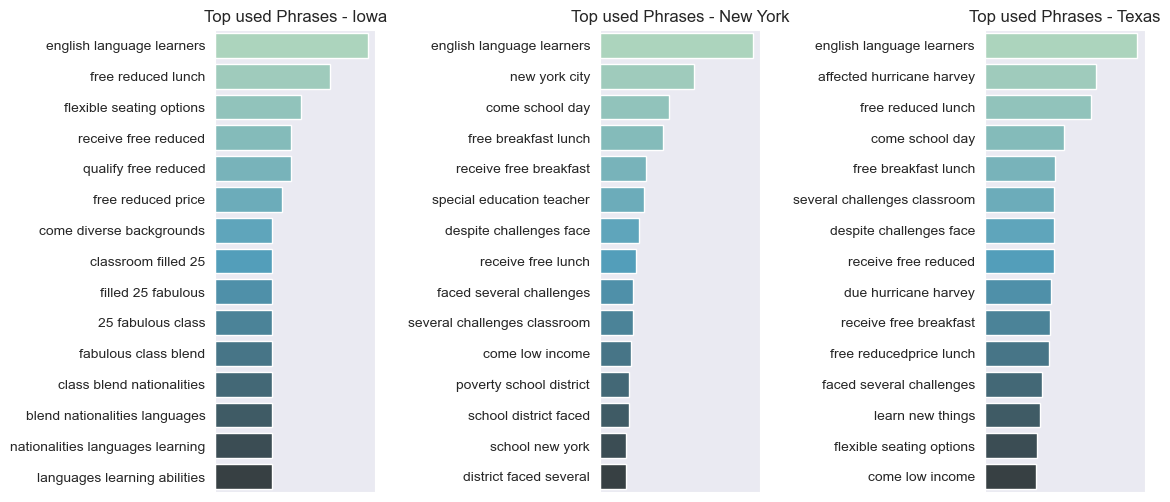

In [111]:
ignores = ['every day', 'come school']
all_unigrams = []
for each in april18_df[april18_df['School State'] == 'California']['trigrams']:
    all_unigrams.extend([x for x in each if x not in ignores])
t = Counter(all_unigrams).most_common(15)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df[april18_df['School State'] == 'Georgia']['trigrams']:
    all_bigrams.extend([x for x in each if x not in ignores])
t1 = Counter(all_bigrams).most_common(15)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]

all_trigrams = []
for each in april18_df[april18_df['School State'] == 'Florida']['trigrams']:
    all_trigrams.extend([x for x in each if x not in ignores])
t2 = Counter(all_trigrams).most_common(15)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,6));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top used Phrases - California");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top used Phrases - Georgia");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top used Phrases - Florida");

all_unigrams = []
for each in april18_df[april18_df['School State'] == 'Iowa']['trigrams']:
    all_unigrams.extend([x for x in each if x not in ignores])
t = Counter(all_unigrams).most_common(15)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df[april18_df['School State'] == 'New York']['trigrams']:
    all_bigrams.extend([x for x in each if x not in ignores])
t1 = Counter(all_bigrams).most_common(15)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]

all_trigrams = []
for each in april18_df[april18_df['School State'] == 'Texas']['trigrams']:
    all_trigrams.extend([x for x in each if x not in ignores])
t2 = Counter(all_trigrams).most_common(15)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,6));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top used Phrases - Iowa");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top used Phrases - New York");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top used Phrases - Texas");

El enfoque principal de los ensayos en los diferentes estados es prácticamente el mismo, aunque se observan algunas diferencias en estados como Texas, donde un gran número de ensayos tratan sobre los estudiantes afectados por el huracán Harvey. Los profesores han descrito varios desafíos que enfrentaron los estudiantes; las opciones de asientos flexibles son el tema central de la mayoría de los ensayos.

En Iowa, los profesores han descrito a estudiantes de diferentes orígenes y nacionalidades. En Nueva York, los ensayos también se centran en «profesores de educación especial», «escuelas de distritos pobres» y «bajos ingresos».

En Florida, los profesores han mencionado la «reducción de precios del desayuno y el almuerzo».

## <a id="8.2.3"> 8.2.3 «<i>Mis alumnos son ______ ______ ______</i>»: Lo que los profesores describen sobre sus alumnos.

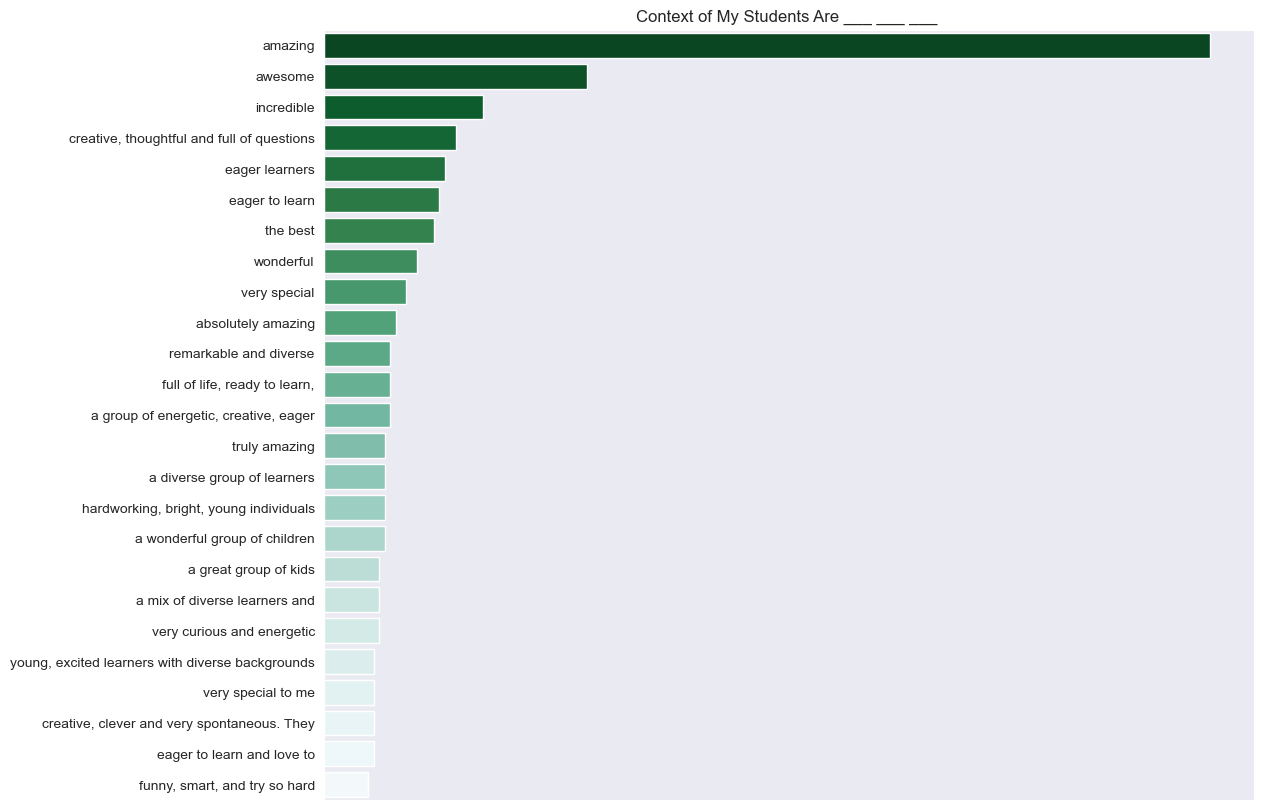

In [113]:
from textblob import TextBlob, Word
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
mask = np.array(Image.open('./cloud.png'))

mystudents = []
for x in april18_df['Project Essay']:
    if x.lower().startswith("my students are"):
        phrase = " ".join(x.replace('My students are', '').split(". ")[0].split("!")[0].strip().split()[:6])
        mystudents.append(phrase)

t3 = Counter(mystudents).most_common(25)
x = [a[0] for a in t3]
y = [a[1] for a in t3]

sns.set_style("dark")
plt.figure(figsize = (12,10))
plt.title("Context of My Students Are ___ ___ ___ ");
bar = sns.barplot(y=x, x=y, palette="BuGn_r", edgecolor="white");
bar.set(xlabel='', xticks=[]);

Los profesores utilizaron muchos adjetivos para describir a sus alumnos, por ejemplo: «¡Increíble!», «¡Genial!», «¡Fantástico!», «¡Creativo!». En algunos ensayos, los profesores los describen como «muy especiales para ellos» y «extraordinarios».

## <a id="8.2.4"> 8.2.4 Según los profesores, lo que los alumnos necesitan ______ ______ ______ </a>

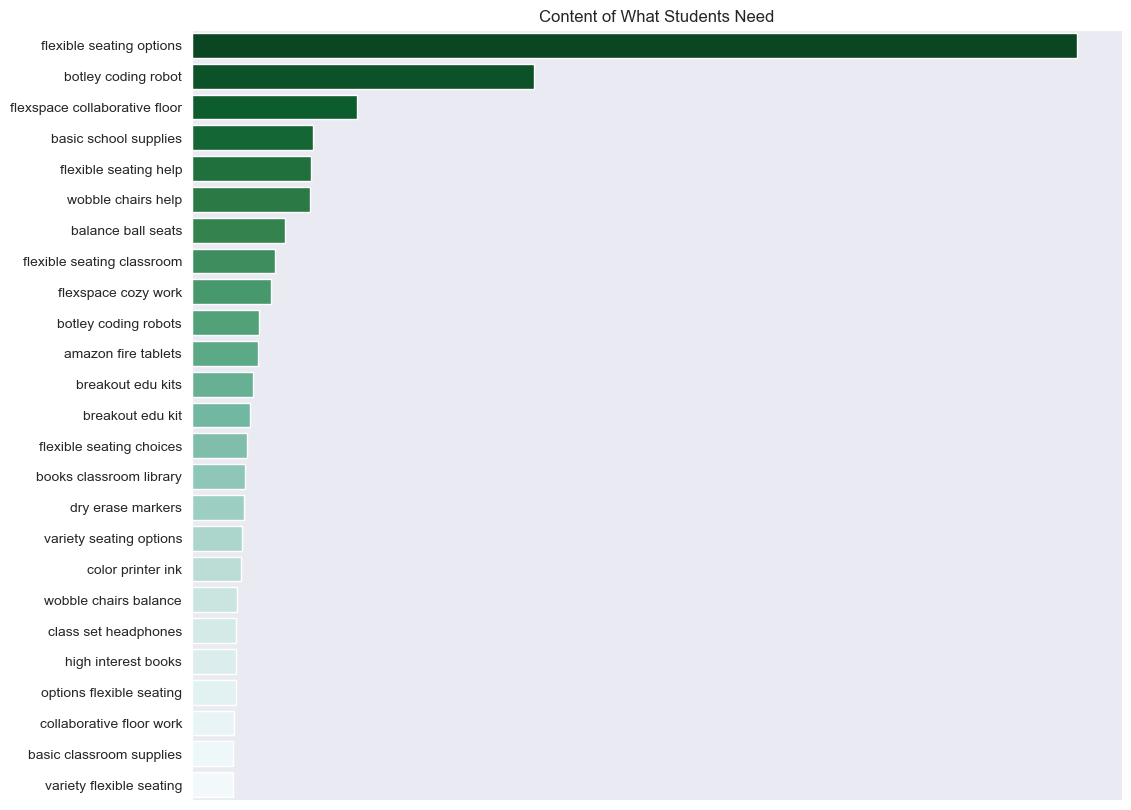

In [114]:
mystudents = []
for x in april18_df['clean_need']:
    if x.lower().strip().startswith("need"):
        phrase = " ".join(x.lower().strip().replace('need', '').split(". ")[0].split("!")[0].strip().split()[:3])
        mystudents.append(phrase)

t3 = Counter(mystudents).most_common(25)
x = [a[0] for a in t3]
y = [a[1] for a in t3]

sns.set_style("dark")
plt.figure(figsize = (12,10))
plt.title("Content of What Students Need")
bar = sns.barplot(y=x, x=y, palette="BuGn_r", edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top Keywords");

- Además de la necesidad principal sugerida por los profesores, es decir, <b>"Opciones de asientos flexibles"</b>, otras necesidades importantes son <b>"Robot de programación"</b> y <b>"Material escolar básico"</b>. En cuanto a los asientos flexibles, se centran principalmente en <b>"Sillas oscilantes y asientos con balón de equilibrio"</b>, que son las más solicitadas. Otras necesidades relacionadas con la tecnología incluyen <b>"Tabletas Amazon Fire"</b>, <b>"Auriculares"</b> y <b>"Kit Osmo Genius"</b>.

## <a href="8.2.5"> 8.2.5 Título del proyecto: Palabras clave más utilizadas </a>

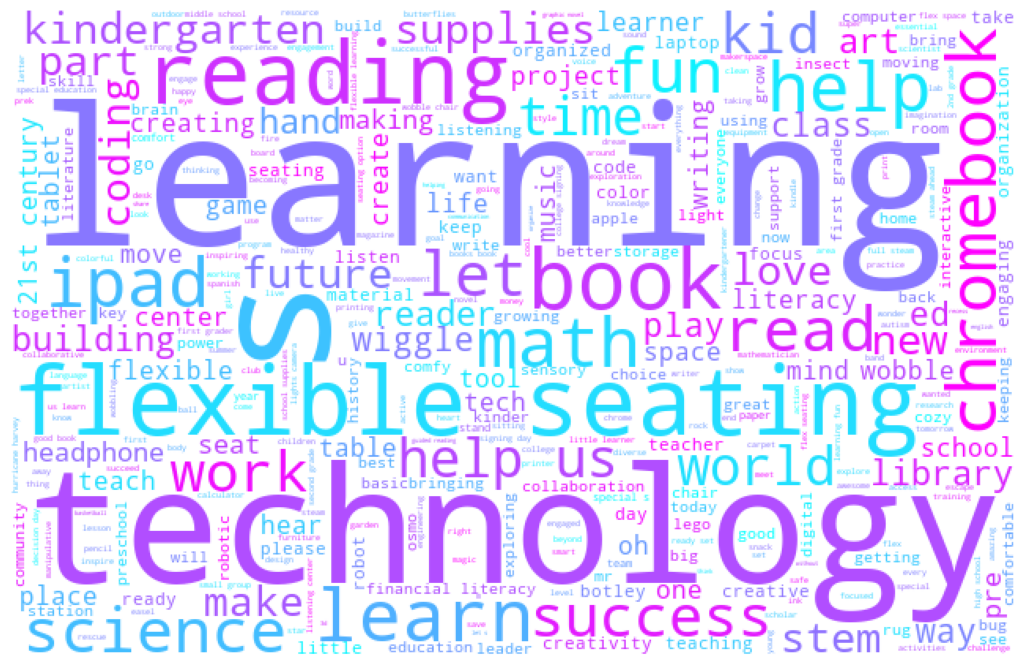

In [115]:
text = " ".join(april18_df['Project Title']).lower()
for w in ['need', 'student', 'classroom']: # remove some additional noise 
    text = text.replace(w, " ")
wc = WordCloud(max_words=1200, stopwords=STOPWORDS, colormap='cool', background_color='White', mask=mask).generate(text)
plt.figure(figsize=(13,13))
plt.imshow(wc)
plt.axis('off')
plt.title('');

Temas como la flexibilidad en la disposición de los asientos, Chromebook, lectura, aprendizaje, tecnología y libros son el foco principal de un gran número de profesores para sus alumnos.

## <a href="9"> 9. Comprensión y comparación de las características clave de los proyectos </a>

## <a href="9.1"> 9.1 Proyectos expirados vs. Proyectos financiados </a>

En esta sección, exploraremos y comprenderemos las características clave de los proyectos que obtuvieron financiación y los compararemos con los proyectos que expiraron. Me centraré en los proyectos del año pasado, es decir, 2017.

In [118]:
import pandas as pd

# Convertir la columna de fecha a tipo datetime
projects_df['Project Posted Date'] = pd.to_datetime(projects_df['Project Posted Date'], errors='coerce')

# Crear columnas derivadas de la fecha
projects_df['Posted Year'] = projects_df['Project Posted Date'].dt.year
projects_df['Posted Month'] = projects_df['Project Posted Date'].dt.month
projects_df['Posted Day'] = projects_df['Project Posted Date'].dt.day

# Ahora sí puedes filtrar por año y estado
expired = projects_df[(projects_df['Posted Year'] == 2017) & 
                      (projects_df['Project Current Status'] == 'Expired')]

funded = projects_df[(projects_df['Posted Year'] == 2017) & 
                     (projects_df['Project Current Status'] == 'Fully Funded')]

# Unir con la tabla de maestros
expired = expired.merge(teachers_df, on="Teacher ID")
funded = funded.merge(teachers_df, on="Teacher ID")

print("Expired shape:", expired.shape)
print("Funded shape:", funded.shape)


Expired shape: (59877, 33)
Funded shape: (212088, 33)


In [117]:
print(projects_df.columns)


Index(['Project ID', 'School ID', 'Teacher ID',
       'Teacher Project Posted Sequence', 'Project Type', 'Project Title',
       'Project Essay', 'Project Short Description', 'Project Need Statement',
       'Project Subject Category Tree', 'Project Subject Subcategory Tree',
       'Project Grade Level Category', 'Project Resource Category',
       'Project Cost', 'Project Posted Date', 'Project Expiration Date',
       'Project Current Status', 'Project Fully Funded Date', 'School Name',
       'School Metro Type', 'School Percentage Free Lunch', 'School State',
       'School Zip', 'School City', 'School County', 'School District'],
      dtype='object')


Expired shape: (59877, 33)
Funded shape: (212088, 33)


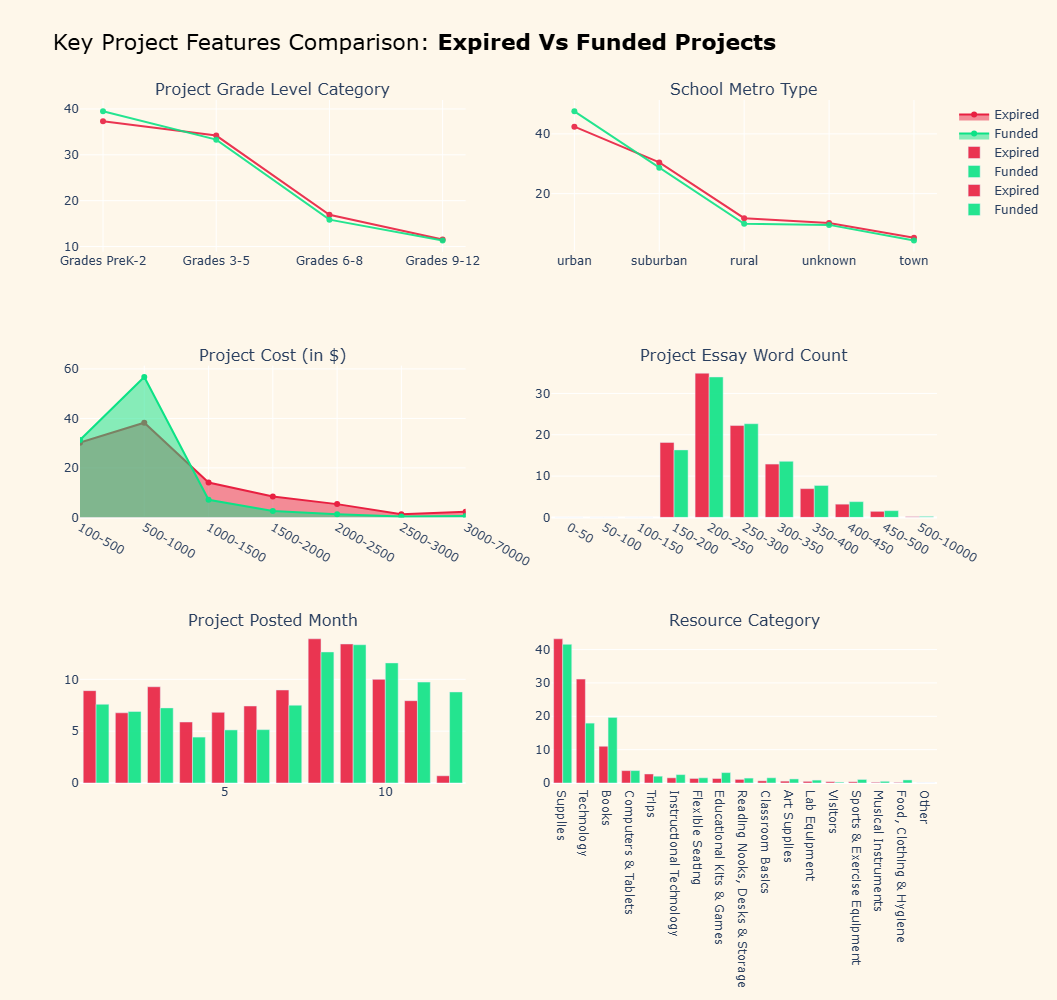

In [122]:


import pandas as pd

# Convertir la columna de fecha a tipo datetime
projects_df['Project Posted Date'] = pd.to_datetime(projects_df['Project Posted Date'], errors='coerce')

# Crear columnas derivadas de la fecha
projects_df['Posted Year'] = projects_df['Project Posted Date'].dt.year
projects_df['Posted Month'] = projects_df['Project Posted Date'].dt.month
projects_df['Posted Day'] = projects_df['Project Posted Date'].dt.day

# Ahora sí puedes filtrar por año y estado
expired = projects_df[(projects_df['Posted Year'] == 2017) & 
                      (projects_df['Project Current Status'] == 'Expired')]

funded = projects_df[(projects_df['Posted Year'] == 2017) & 
                     (projects_df['Project Current Status'] == 'Fully Funded')]

# Unir con la tabla de maestros
expired = expired.merge(teachers_df, on="Teacher ID")
funded = funded.merge(teachers_df, on="Teacher ID")

print("Expired shape:", expired.shape)
print("Funded shape:", funded.shape)


def get_trace(col, func, flag=None,leg=False):

    t1 = expired[col].value_counts()
    t2 = funded[col].value_counts()

    if flag == 'num':
        t1 = expired[expired['NumProjects'] <= 20][col].value_counts()    
        t2 = funded[funded['NumProjects'] <= 20][col].value_counts() 
    
    trace1 = func(
        x=t1.index,
        y=[float(a)*100/sum(t1.values) for a in t1.values],
        name='Expired',
        marker=dict(color='#e82041'),
        showlegend=leg,
        opacity=0.9
    )
    trace2 = func(
        x=t2.index,
        y=[float(a)*100/sum(t2.values) for a in t2.values],
        name='Funded',
        marker=dict(color='#0de286'),
        opacity=0.9, showlegend=leg
    )
    
#     trace2 = func(x=t2.index, 
#                   y= [], 
#                   name='Funded', 
#                   marker=(), 
#                   opacity=0.5)
    return trace1, trace2

tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)


########################
expired['wc'] = expired['Project Essay'].apply(lambda x : len(x.split()))
funded['wc'] = funded['Project Essay'].apply(lambda x : len(x.split()))

bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

expired['wc'] = pd.cut(expired['wc'], bins)
t1 = dict(expired['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr13 = go.Bar(
    x=order,
    y=values,
    name='Expired',
    marker=dict(color='#e82041'),
    opacity=0.9
)


funded['wc'] = pd.cut(funded['wc'], bins)
t2 = dict(funded['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr14 = go.Bar(
    x=order,
    y=values,
    name='Funded',
    marker=dict(color='#0de286'),
    opacity=0.9
)



############### cost ###########
bins = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

# Usar Project Cost en lugar de cost
expired['binnedcost'] = pd.cut(expired['Project Cost'], bins)
t1 = dict(expired['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['100-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-70000']
values = [d[v] for v in order]

tr15 = go.Scatter(
    x=order,
    y=values,
    name='Expired',fill='tozeroy',
    marker=dict(color='#e82041'),
    opacity=0.9
)


funded['binnedcost'] = pd.cut(funded['Project Cost'], bins)
t2 = dict(funded['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
values = [d[v] for v in order]

tr16 = go.Scatter(
    x=order,
    y=values,
    name='Funded',fill='tozeroy',
    marker=dict(color='#0de286'),
    opacity=0.9)



#############


titles = ['Project Grade Level Category', "School Metro Type","Project Cost (in $)", 
          "Project Essay Word Count", "Project Posted Month", "Resource Category"]
fig = tools.make_subplots(rows=3, cols=2, subplot_titles=titles, print_grid=False, specs=[[{}, {}],
                                                                  [{},{}], 
                                                                  [{}, {}],]) 
#                                                                   [{'colspan':2}, None],
#                                                                   [{}, None]
fig.append_trace(tr1, 1,1)
fig.append_trace(tr2, 1,1)
fig.append_trace(tr3, 1,2)
fig.append_trace(tr4, 1,2)
fig.append_trace(tr15, 2,1)
fig.append_trace(tr16, 2,1)
fig.append_trace(tr13, 2,2)
fig.append_trace(tr14, 2,2)
fig.append_trace(tr7, 3,2)
fig.append_trace(tr8, 3,2)
fig.append_trace(tr9, 3,1)
fig.append_trace(tr10, 3,1)

fig['layout'].update(barmode='group',
  
     title=dict(
        text='Key Project Features Comparison: <b>Expired Vs Funded Projects</b> <br>',
        font=dict(size=22, color='#000')
    ),          
    margin=dict(t=100, b=100),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000)
iplot(fig);

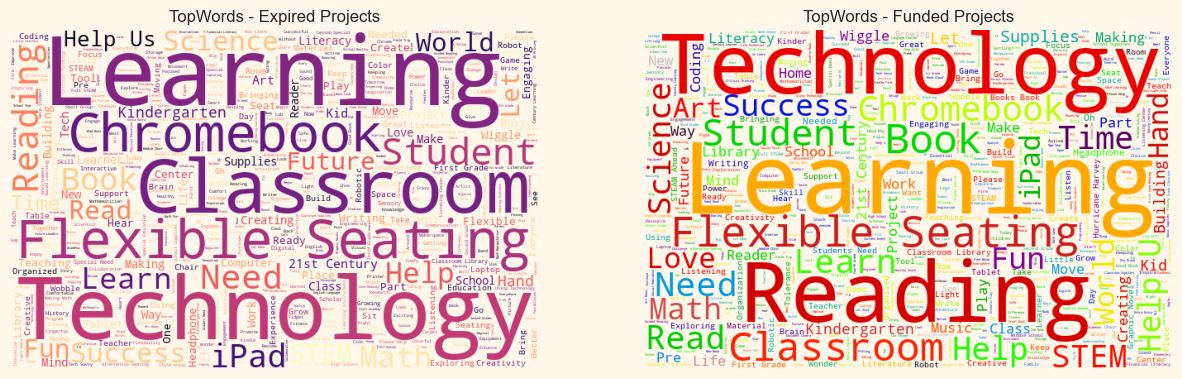

In [124]:
pos_text_cln = " ".join(funded['Project Title'])
neg_text_cln = " ".join(expired['Project Title'])

def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(85, 140), random.randint(60, 80))

def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(0, 35), random.randint(60, 80))
    
from PIL import Image
mask = np.array(Image.open('./cloud.png'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[15, 8], facecolor='#fef7ea')

wordcloud1 = WordCloud(max_words=1200,colormap='magma',
                       background_color='rgb(254, 247, 234)',mask=mask).generate(neg_text_cln)
ax1.imshow(wordcloud1)
ax1.axis('off');
ax1.set_title('TopWords - Expired Projects');

wordcloud2 = WordCloud(max_words=1200,colormap='nipy_spectral', background_color='rgb(254, 247, 234)', mask=mask
                      ).generate(pos_text_cln)
ax2.imshow(wordcloud2)
ax2.axis('off');
ax2.set_title('TopWords - Funded Projects');

La comparación revela las siguientes conclusiones:
- Los proyectos pertenecientes al nivel de **Preescolar a 2.º grado** presentan un mayor porcentaje de proyectos exitosos que de proyectos que no se financiaron. En cambio, en los demás grados, el porcentaje de proyectos que no se financiaron es mayor que el de proyectos financiados con éxito. Quizás los donantes prefieren **donar a niños de grados inferiores** que a los de grados superiores.

- Los proyectos financiados con éxito tienen un mayor porcentaje en escuelas ubicadas en **áreas urbanas**, mientras que los proyectos que no se financiaron con éxito tienen un mayor porcentaje en escuelas ubicadas en **áreas rurales, suburbanas o pueblos**.

- Otra característica de los proyectos financiados está relacionada con el costo del proyecto. Los proyectos cuyo coste total es inferior a 500 USD presentan un porcentaje muy alto de proyectos financiados con éxito, mientras que lo contrario también es cierto: un alto porcentaje de proyectos que caducan tienen costes más elevados, es decir, superiores a 500 USD.
> - Los ensayos de los proyectos son una parte esencial de los proyectos de DonorsChoose, y el número de palabras utilizadas en el texto influye considerablemente en el resultado del proyecto, como se observa en el cuarto gráfico. Los proyectos financiados con éxito son más comunes entre aquellos con un ensayo de más de 250 palabras. Esto indica que se debería animar a los docentes a escribir de forma más exhaustiva sobre los proyectos.

> - Un número significativo de proyectos publicados en el último trimestre del año, es decir, entre octubre y diciembre, suelen financiarse con éxito. Esto indica que es un buen periodo en el que los donantes tienden a donar más. Quizás los docentes que sienten que no están recibiendo donaciones para sus proyectos deberían empezar a publicarlos en noviembre o diciembre. En el resto del año, el porcentaje de proyectos caducados es mayor que el de proyectos financiados. Se observa un dato interesante entre los proyectos que caducaron: un gran porcentaje de estos proyectos tenía altos costos en requisitos técnicos como **iPads, Chromebooks**, etc. La categoría de recursos **suministros y tecnologías** presenta un número muy elevado de proyectos caducados.

En todo Estados Unidos, existen pocos estados donde el porcentaje de proyectos financiados es mayor que el de proyectos caducados. Algunos de estos estados son **Illinois, Massachusetts y Oklahoma**. El porcentaje de proyectos caducados es mayor en otros estados. Quizás Donorschoose podría aumentar sus campañas de marketing y correo electrónico para atraer donantes de estos estados.

Un mayor porcentaje de proyectos financiados solicitó **asientos flexibles y material de lectura**, mientras que los proyectos caducados presentaron un alto porcentaje de **elementos relacionados con la tecnología**.

## <a href="9.2"> 9.2 Proyectos con baja vs. alta duración de financiación </a>

Ahora comparemos las características de los proyectos que se financiaron con éxito en un período más corto, es decir: menos de 1 día frente a los proyectos que tardaron más de 2 meses en obtener financiación.

In [125]:
projects_df['time'] = projects_df['Funding Time'].apply(lambda x : str(x).split()[0])

tempdf = projects_df[projects_df['time'] != "NaT"]
tempdf['time'] = tempdf['time'].apply(int)
tempdf = tempdf[tempdf['Posted Year'] == 2017]

df1 = tempdf[tempdf['time'] <= 1] 
df2 = tempdf[tempdf['time'] >= 60] 

df1 = df1.merge(teachers_df, on="Teacher ID")
df2 = df2.merge(teachers_df, on="Teacher ID")




def get_trace(col, func, flag=None, leg=False):

    t1 = df1[col].value_counts()
    t2 = df2[col].value_counts()

    if flag == 'num':
        t1 = df1[df1['NumProjects'] <= 20][col].value_counts()    
        t2 = df2[df2['NumProjects'] <= 20][col].value_counts() 
    
    trace1 = func(
        x=t1.index,
        y=[float(a)*100/sum(t1.values) for a in t1.values],
        name='Small Funding Duration',
        marker=dict(color='#0de286'),
        showlegend=leg,
        opacity=0.9
    )
    trace2 = func(
        x=t2.index,
        y=[float(a)*100/sum(t2.values) for a in t2.values],
        name='Large Funding Duration',
        marker=dict(color='#e82041'),
        opacity=0.9, 
        showlegend=leg
    )
    return trace1, trace2

tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)


########################
df1['wc'] = df1['Project Essay'].apply(lambda x : len(x.split()))
df2['wc'] = df2['Project Essay'].apply(lambda x : len(x.split()))

bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

df1['wc'] = pd.cut(df1['wc'], bins)
t1 = dict(df1['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr13 = go.Bar(
    x=order,
    y=values,
    name='Small Funding Duration',
    marker=dict(color='#0de286'),showlegend=False,
    opacity=0.9
)


df2['wc'] = pd.cut(df2['wc'], bins)
t2 = dict(df2['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr14 = go.Bar(
    x=order,
    y=values,
    name='Large Funding Duration',
    marker=dict(color='#e82041'),showlegend=False,
    opacity=0.9
)



############### cost ###########
bins = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

df1['binnedcost'] = pd.cut(df1['cost'], bins)
t1 = dict(df1['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['100-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-70000']
values = [d[v] for v in order]

tr15 = go.Scatter(
    x=order,
    y=values,
    name='Small Funding Time',fill='tozeroy',
    marker=dict(color='#0de286'),showlegend=False,
    opacity=0.9
)


df2['binnedcost'] = pd.cut(df2['cost'], bins)
t2 = dict(df2['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
values = [d[v] for v in order]

tr16 = go.Scatter(
    x=order,
    y=values,
    name='Large Funding Time',fill='tozeroy',
    marker=dict(color='#e82041'),showlegend=False,

    opacity=0.9)



#############


titles = ['Project Grade Level Category', "School Metro Type","Project Cost (in $)", 
          "Project Essay Word Count", "Project Posted Month", "Resource Category"]
fig = tools.make_subplots(rows=3, cols=2, subplot_titles=titles, print_grid=False, specs=[[{}, {}],
                                                                  [{},{}], 
                                                                  [{}, {}],]) 
#                                                                   [{'colspan':2}, None],
#                                                                   [{}, None]
fig.append_trace(tr1, 1,1)
fig.append_trace(tr2, 1,1)
fig.append_trace(tr3, 1,2)
fig.append_trace(tr4, 1,2)
fig.append_trace(tr15, 2,1)
fig.append_trace(tr16, 2,1)
fig.append_trace(tr13, 2,2)
fig.append_trace(tr14, 2,2)
fig.append_trace(tr7, 3,2)
fig.append_trace(tr8, 3,2)
fig.append_trace(tr9, 3,1)
fig.append_trace(tr10, 3,1)

fig['layout'].update(barmode='group',
    title = 'Key Project Features Comparison: <b>Projects with Small Vs Larger Funding Time</b> <br>',
    titlefont=dict(
            size=22,
            color='#000'
        ),
    legend=dict(x=0.25, y=1.06 , orientation="h"),
    margin=dict(t=100, b=100),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000)
iplot(fig);



KeyError: 'Funding Time'

In [ ]:

pos_text_cln = " ".join(df2['Project Title'])
neg_text_cln = " ".join(df1['Project Title'])

noise = ['Learning', 'Student', 'Classroom']
for n in noise:
    pos_text_cln = pos_text_cln.replace(n," ")
    neg_text_cln = neg_text_cln.replace(n," ")
    
def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(85, 140), random.randint(60, 80))

def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(0, 35), random.randint(60, 80))
    
from PIL import Image
mask = np.array(Image.open('../input/word-cloud-masks/cloud1.png'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[17, 8], facecolor='#fef7ea')

wordcloud1 = WordCloud(max_words=1200,colormap='magma',
                       background_color='rgb(254, 247, 234)',mask=mask).generate(neg_text_cln)
ax1.imshow(wordcloud1)
ax1.axis('off');
ax1.set_title('TopWords - Projects with Lower Funding Time');

wordcloud2 = WordCloud(max_words=1200,colormap='nipy_spectral', background_color='rgb(254, 247, 234)', mask=mask
                      ).generate(pos_text_cln)
ax2.imshow(wordcloud2)
ax2.axis('off');
ax2.set_title('TopWords - Projects with Higher Funding Time');

La comparación revela las siguientes conclusiones:
- Se observa que los proyectos financiados con éxito en un día o menos pertenecen con mayor frecuencia a los niveles de **6.º a 12.º grado**, mientras que un mayor porcentaje de proyectos que tardaron más tiempo en obtener la financiación completa pertenecen a los grados inferiores.

- Las **áreas suburbanas** presentaron un mayor porcentaje de proyectos completados en plazos más cortos en comparación con otros tipos de zonas escolares.

- Se espera que los proyectos con un costo total menor, es decir, menos de 500 USD, tengan mayores probabilidades de ser financiados rápidamente, en comparación con los proyectos que requieren mayores cantidades. Esto se observa también en los gráficos.

- En los proyectos financiados en menos de un día, los docentes utilizaron un número relativamente mayor de **palabras**, es decir, más de 250, en sus ensayos. En el caso de los proyectos con ensayos de menos de 500 palabras, se observó un mayor número de proyectos financiados en plazos más largos. Un mayor número de proyectos publicados en los meses de febrero, marzo, agosto y octubre se financiaron con éxito en un plazo más corto, mientras que el mayor porcentaje de proyectos financiados en un plazo más largo se observó en los meses de diciembre y septiembre.

## <a href="9.3"> 9.3 Proyectos con un solo donante frente a proyectos con múltiples donantes </a>

Analicemos las características de los proyectos en los que un solo donante aportó fondos frente a los proyectos en los que participaron más de diez donantes.

In [ ]:
num_donations = donations_df.groupby('Project ID').agg({'Donation ID' : 'count'}).reset_index().rename(columns={'Donation ID' : 'NumDonations'})
tempdf = projects_df.merge(num_donations, on="Project ID")
df1 = tempdf[tempdf['Posted Year'] == 2017][tempdf['NumDonations'] == 1] 
df2 = tempdf[tempdf['Posted Year'] == 2017][tempdf['NumDonations'] > 10] 
df1 = df1.merge(teachers_df, on="Teacher ID")
df2 = df2.merge(teachers_df, on="Teacher ID")

def get_trace(col, func, flag=None, leg=False):

    t1 = df1[col].value_counts()
    t2 = df2[col].value_counts()

    if flag == 'num':
        t1 = df1[df1['NumProjects'] <= 20][col].value_counts()    
        t2 = df2[df2['NumProjects'] <= 20][col].value_counts() 
    
    trace1 = func(
        x=t1.index,
        y=[float(a)*100/sum(t1.values) for a in t1.values],
        name='Single Donors',
        marker=dict(color='#0de286'),
        showlegend=leg,
        opacity=0.9
    )
    trace2 = func(
        x=t2.index,
        y=[float(a)*100/sum(t2.values) for a in t2.values],
        name='Multiple Donors',
        marker=dict(color='#e82041'),
        opacity=0.9, 
        showlegend=leg
    )
    return trace1, trace2

tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)


########################
df1['wc'] = df1['Project Essay'].apply(lambda x : len(x.split()))
df2['wc'] = df2['Project Essay'].apply(lambda x : len(x.split()))

bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

df1['wc'] = pd.cut(df1['wc'], bins)
t1 = dict(df1['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr13 = go.Bar(
    x=order,
    y=values,
    name='Single Donors',
    marker=dict(color='#0de286'),showlegend=False,
    opacity=0.9
)


df2['wc'] = pd.cut(df2['wc'], bins)
t2 = dict(df2['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr14 = go.Bar(
    x=order,
    y=values,
    name='Multiple Donors',
    marker=dict(color='#e82041'),showlegend=False,
    opacity=0.9
)



############### cost ###########
bins = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

df1['binnedcost'] = pd.cut(df1['cost'], bins)
t1 = dict(df1['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['100-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-70000']
values = [d[v] for v in order]

tr15 = go.Scatter(
    x=order,
    y=values,
    name='Single Donors',fill='tozeroy',
    marker=dict(color='#0de286'),showlegend=False,
    opacity=0.9
)


df2['binnedcost'] = pd.cut(df2['cost'], bins)
t2 = dict(df2['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
values = [d[v] for v in order]

tr16 = go.Scatter(
    x=order,
    y=values,
    name='Multiple Donors',fill='tozeroy',
    marker=dict(color='#e82041'),showlegend=False,

    opacity=0.9)



#############


titles = ['Project Grade Level Category', "School Metro Type","Project Cost (in $)", 
          "Project Essay Word Count", "Project Posted Month", "Resource Category"]
fig = tools.make_subplots(rows=3, cols=2, subplot_titles=titles, print_grid=False, specs=[[{}, {}],
                                                                  [{},{}], 
                                                                  [{}, {}],]) 
#                                                                   [{'colspan':2}, None],
#                                                                   [{}, None]
fig.append_trace(tr1, 1,1)
fig.append_trace(tr2, 1,1)
fig.append_trace(tr3, 1,2)
fig.append_trace(tr4, 1,2)
fig.append_trace(tr15, 2,1)
fig.append_trace(tr16, 2,1)
fig.append_trace(tr13, 2,2)
fig.append_trace(tr14, 2,2)
fig.append_trace(tr7, 3,2)
fig.append_trace(tr8, 3,2)
fig.append_trace(tr9, 3,1)
fig.append_trace(tr10, 3,1)

fig['layout'].update(barmode='group',
    title = 'Key Project Features Comparison: <b>Projects with Single Vs Multiple Donors</b> <br>',
    titlefont=dict(
            size=22,
            color='#000'
        ),
    legend=dict(x=0.25, y=1.06 , orientation="h"),
    margin=dict(t=100, b=100),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000)
iplot(fig);



In [ ]:
    
pos_text_cln = " ".join(df2['Project Title'])
neg_text_cln = " ".join(df1['Project Title'])

noise = ['Learning', 'Student', 'Classroom', 'Need']
for n in noise:
    pos_text_cln = pos_text_cln.replace(n," ")
    neg_text_cln = neg_text_cln.replace(n," ")
    
def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(85, 140), random.randint(60, 80))

def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(0, 35), random.randint(60, 80))
    
from PIL import Image
mask = np.array(Image.open('../input/word-cloud-masks/cloud1.png'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[17, 8], facecolor='#fef7ea')

wordcloud1 = WordCloud(max_words=1200,colormap='magma',
                       background_color='rgb(254, 247, 234)',mask=mask).generate(neg_text_cln)
ax1.imshow(wordcloud1)
ax1.axis('off');
ax1.set_title('TopWords - Projects with Single Donors');

wordcloud2 = WordCloud(max_words=1200,colormap='nipy_spectral', background_color='rgb(254, 247, 234)', mask=mask
                      ).generate(pos_text_cln)
ax2.imshow(wordcloud2)
ax2.axis('off');
ax2.set_title('TopWords - Projects with Multiple Donors');

- Basándonos en los gráficos y comparaciones anteriores, podemos destacar los siguientes puntos:

- Un mayor porcentaje de proyectos financiados por un solo donante presentaban las siguientes características:
- Pertenecían a los grados **PreK-2**, se publicaban en escuelas de **áreas urbanas**, tenían un menor costo, los docentes utilizaban ensayos con **pocas palabras** (menos de 250), se publicaban en los meses de **septiembre, octubre y diciembre**, y trataban principalmente sobre **libros**.

- Un mayor porcentaje de proyectos financiados por múltiples donantes presentaban las siguientes características:
- Pertenecían a grados superiores (3.º a 12.º grado), se publicaban en escuelas de **áreas suburbanas y rurales**, tenían un costo **superior a USD 500**, utilizaban un mayor número de palabras en los ensayos y estaban relacionados con **tecnologías y suministros**.

## Notas finales ##

Este es el final del cuaderno, pero aún hay mucho más por explorar en este completo conjunto de datos. Intentaré añadir más información. Espero que este cuaderno sea útil. Si te gustó, dale un voto positivo.

### Gracias por leer mi trabajo y espero que lo disfrutes. :)